In [68]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [69]:
total_keys2 = ["L_MASS",'Lb_MASS','Jpsi_MASS','Jpsi_P', "Jpsi_PT",'Jpsi_CHI2','Jpsi_MAXDOCA','Jpsi_BPVDIRA','Jpsi_END_VRHO','Jpsi_END_VX','Jpsi_END_VY','Jpsi_END_VZ','Jpsi_BPVIP','Jpsi_MINIPCHI2','L_P','L_PT','L_PX','L_PY','L_PZ','L_CHI2',
               'L_END_VZ','L_END_VX','L_END_VY',"L_END_VRHO","L_BPVDIRA","L_BPVIP","L_BPVIPCHI2",'L_BPVFDCHI2','L_MINIPCHI2',"Lb_P","Lb_PT",'Lb_PX','Lb_PY','Lb_PZ',"Lb_CHI2","Lb_MAXDOCA","Lb_BPVDIRA","Lb_BPVVDRHO",
               "Lb_BPVIP",'Lb_BPVIPCHI2','Lb_BPVFDCHI2','Lb_MINIPCHI2',"p_P","p_PT",'p_PX','p_PY','p_PZ',"p_PID_P",
               "p_PID_K","p_MINIP",'p_GHOSTPROB',"pim_P","pim_PT",'pim_PX','pim_PY','pim_PZ','pim_GHOSTPROB','mum_P','mum_PT','mum_PX','mum_PY','mum_PZ','mum_CHI2','mum_GHOSTPROB','mum_PID_P','mum_PID_K','mum_PID_MU',
               'mum_PID_E','mum_MINIP','mum_MINIPCHI2','mup_P','mup_PT','mup_PX','mup_PY','mup_PZ','mup_CHI2','mup_GHOSTPROB','mup_PID_P','mup_PID_K','mup_PID_MU','mup_PID_E','mup_MINIP','mup_MINIPCHI2',
               'totCandidates']

In [70]:
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '

In [71]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'p_MASS', 'Jpsi_BKGCAT', 'Jpsi_MC_GD_MOTHER_ID', 'Jpsi_MC_MOTHER_ID'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data2 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'p_MASS', 'Jpsi_BKGCAT', 'Jpsi_MC_GD_MOTHER_ID', 'Jpsi_MC_MOTHER_ID'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data3 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'p_MASS', 'Jpsi_BKGCAT', 'Jpsi_MC_GD_MOTHER_ID', 'Jpsi_MC_MOTHER_ID'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data4 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'p_MASS', 'Jpsi_BKGCAT', 'Jpsi_MC_GD_MOTHER_ID', 'Jpsi_MC_MOTHER_ID'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_data5 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'p_MASS', 'Jpsi_BKGCAT', 'Jpsi_MC_GD_MOTHER_ID', 'Jpsi_MC_MOTHER_ID'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data6 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'p_MASS', 'Jpsi_BKGCAT', 'Jpsi_MC_GD_MOTHER_ID', 'Jpsi_MC_MOTHER_ID'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data7 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'p_MASS', 'Jpsi_BKGCAT', 'Jpsi_MC_GD_MOTHER_ID', 'Jpsi_MC_MOTHER_ID'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data8 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT', 'p_MASS', 'Jpsi_BKGCAT', 'Jpsi_MC_GD_MOTHER_ID', 'Jpsi_MC_MOTHER_ID'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")

mc_signal = mc_signal_merge.query(preselection_cut_mc)
mc_background = mc_background_merge.query(preselection_cut_mc)
mc_signal_background = mc_signal_background_merge.query(preselection_cut_mc)

In [72]:
#Preselection data.
signal_data = pd.read_pickle('data24_armenteros.pkl')
adding_data = pd.read_pickle('data24_armenteros_add.pkl')
signal_data = pd.concat([signal_data,adding_data],axis='columns')
#Creates a new variables like the Cos()...
sum_CHI2 = signal_data['Lb_CHI2']+signal_data['L_CHI2']+signal_data['Jpsi_CHI2']
angle = np.arccos((signal_data['mum_PX']*signal_data['mup_PX']+signal_data['mum_PY']*signal_data['mup_PY']+signal_data['mum_PZ']*signal_data['mup_PZ'])/(signal_data['mum_P']*signal_data['mup_P']))
cos_angle = ((signal_data['mum_PX']*signal_data['mup_PX']+signal_data['mum_PY']*signal_data['mup_PY']+signal_data['mum_PZ']*signal_data['mup_PZ'])/(signal_data['mum_P']*signal_data['mup_P']))
cos_xi_L = ((signal_data['p_PX']*signal_data['L_PX']+signal_data['p_PY']*signal_data['L_PY']+signal_data['p_PZ']*signal_data['L_PZ'])/(signal_data['p_P']*signal_data['L_P']))
cos_xi_Lb = ((signal_data['p_PX']*signal_data['Lb_PX']+signal_data['p_PY']*signal_data['Lb_PY']+signal_data['p_PZ']*signal_data['Lb_PZ'])/(signal_data['p_P']*signal_data['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
signal_data['SUMCHI2'] = sum_CHI2
signal_data['Theta_P'] = angle
signal_data['Cos_theta_P'] = cos_angle
signal_data['Cos_xi_LP'] = cos_xi_L
signal_data['Cos_xi_LbP'] = cos_xi_Lb
signal_data['xi_LP'] = xi_LbP
signal_data['xi_LbP'] = xi_LP


signal_data


/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_ETA,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,...,pim_TRACK_POS_CLOSESTTOBEAM_X,pim_TRACK_POS_CLOSESTTOBEAM_Y,pim_TRACK_POS_CLOSESTTOBEAM_Z,SUMCHI2,Theta_P,Cos_theta_P,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP
0,1077.975830,5846.956055,2974.502686,54863.386719,1776.397949,4.123077,0.005935,0.002314,0.997817,1.207904,...,-1746.7484,-215.8711,7895.8999,1.332619,0.140961,0.990081,0.999991,0.999902,0.014029,0.004257
1,1077.976562,5313.719238,3112.583496,58726.832031,1343.211792,4.470844,0.122067,0.009861,0.997888,1.222700,...,-1700.6754,505.1554,7826.0996,1.834390,0.127805,0.991844,0.999985,0.999979,0.006496,0.005426
2,1078.187256,6402.193359,3093.716309,18753.294922,2738.893555,2.611505,0.071255,0.009010,0.984698,1.317595,...,-1685.1663,-605.9817,7826.0996,8.643069,0.336862,0.943797,0.999327,0.999409,0.034373,0.036701
3,1078.331421,5060.589355,3078.505615,36252.464844,492.338257,4.992107,1.107087,0.028151,0.996496,1.103896,...,-1684.7295,-23.0286,7826.0996,24.885163,0.171750,0.985287,0.999998,0.999966,0.008250,0.002072
4,1078.344971,5300.834473,2953.872803,26179.085938,1636.410034,3.464616,1.147581,0.034740,0.992858,1.206773,...,-1658.7753,-189.1307,7895.8999,5.839044,0.227141,0.974314,1.000000,0.999871,0.016058,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2385520,1499.999146,5465.837891,3116.906006,68869.664062,1651.937012,4.423246,0.240755,0.012574,0.999810,1.170818,...,1605.0896,-302.4525,7895.8994,37.424356,0.094939,0.995497,0.999515,0.999125,0.041827,0.031148
2385521,1499.999268,5057.749512,3105.656494,37938.269531,3193.528564,3.166201,2.272352,0.042266,0.986553,1.228708,...,1619.1001,225.9496,7826.0991,23.769515,0.165611,0.986318,0.999625,0.994184,0.107904,0.027388
2385522,1499.999634,6379.979980,3111.542480,38214.558594,2022.875732,3.631062,2.339109,0.063037,0.997769,1.338594,...,1627.0600,429.3525,7826.0991,42.082629,0.162117,0.986888,0.999794,0.997756,0.067000,0.020283
2385523,1499.999756,6493.334473,3065.772461,27737.134766,2734.924072,3.007334,0.421790,0.024650,0.999892,1.357072,...,1807.2089,-422.2669,7826.0991,26.433014,0.223562,0.975114,0.999879,0.999713,0.023974,0.015564


In [73]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

# Filtrar los datos según las condiciones dadas
mc_signal3 = mc_signal.query("(p_TRUEID == 2212) & (pim_TRUEID == -211) & (p_MC_GD_MOTHER_ID == 5122) & (pim_MC_GD_MOTHER_ID == 5122) & (p_MC_MOTHER_ID == 3122) & (pim_MC_MOTHER_ID == 3122)")
mc_signal4 = mc_signal.query("(p_TRUEID == -2212) & (pim_TRUEID == 211) & (p_MC_GD_MOTHER_ID == -5122) & (pim_MC_GD_MOTHER_ID == -5122) & (p_MC_MOTHER_ID == -3122) & (pim_MC_MOTHER_ID == -3122)")

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Calcular para partículas
particle = True
results = []
results_mass = []
results_mass_p = []
results_mass_pion = []
results_mass_lambda = []

for index, row in mc_signal3.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    results_mass.append(mass)
    results_mass_p.append(mass_p)
    results_mass_pion.append(mass_pion)
    results_mass_lambda.append(mass_lambda)

# Convertir resultados a DataFrame
armenteros_particle_true = pd.DataFrame(results, columns=['alpha', 'pT'])
invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados
results_mass = []  # Reinicializar la lista de masas
results_mass_p = []
results_mass_pion = []
results_mass_lambda = []

for index, row in mc_signal4.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    results_mass.append(mass)
    results_mass_p.append(mass_p)
    results_mass_pion.append(mass_pion)
    results_mass_lambda.append(mass_lambda)

# Convertir resultados a DataFrame
armenteros_antiparticle_true = pd.DataFrame(results, columns=['alpha', 'pT'])
invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Mostrar resultados
print("Partículas:")
print(armenteros_particle_true)
print("\nMasa invariante de la Lambda:")
print(invariant_mass_particle)
print("\nMasa invariante del Proton:")
print(invariant_mass_particle_p)
print("\nMasa invariante del Pion:")
print(invariant_mass_particle_pion)

print("\nAntipartículas:")
print(armenteros_antiparticle_true)
print("\nMasa invariante de la Anti-Lambda:")
print(invariant_mass_antiparticle)
print("\nMasa invariante del Anti-Proton:")
print(invariant_mass_antiparticle_p)
print("\nMasa invariante del Anti-Pion:")
print(invariant_mass_antiparticle_pion)


Partículas:
          alpha          pT
0      0.821004   70.045499
1      0.722349   99.104033
2      0.762896   92.385248
3      0.824587   67.932751
4      0.699481  100.486121
...         ...         ...
16870  0.555317   65.861954
16871  0.774455   89.335099
16872  0.566139   72.250715
16873  0.864758   28.062632
16874  0.754947   94.174268

[16875 rows x 2 columns]

Masa invariante de la Lambda:
              mass
0      1116.070041
1      1116.289973
2      1115.580483
3      1115.767076
4      1115.725888
...            ...
16870  1115.501451
16871  1115.942663
16872  1115.797985
16873  1115.907087
16874  1115.643919

[16875 rows x 1 columns]

Masa invariante del Proton:
           p_mass
0      938.678192
1      938.896801
2      938.155412
3      938.351615
4      938.314566
...           ...
16870  938.096619
16871  938.515996
16872  938.348474
16873  938.535155
16874  938.246925

[16875 rows x 1 columns]

Masa invariante del Pion:
         pim_mass
0      139.579535
1      

In [74]:
# fig,axes = plt.subplots()
# plt.hist(invariant_mass_particle,bins= 100 , label = 'Particle',  color='green',alpha=0.7, histtype='step')
# plt.hist(invariant_mass_antiparticle,bins= 100 , label = 'Anti-Particle',  color='orange',alpha=0.7, histtype='step')
# plt.xlabel('Lambda_0 [MeV/c^2]')
# plt.ylabel('Entries')
# plt.legend()
# plt.show()

In [75]:
# fig,axes = plt.subplots()

# plt.hist(invariant_mass_particle_p,bins= 500 , label = 'Particle',  color='green',alpha=0.7, histtype='step')
# plt.hist(invariant_mass_antiparticle_p,bins= 500 , label = 'Anti-Particle',  color='orange',alpha=0.7, histtype='step')
# plt.xlabel('Proton [MeV/c^2]')
# plt.ylabel('Entries')
# plt.legend()
# plt.show()

In [76]:
# fig,axes = plt.subplots()

# plt.hist(invariant_mass_particle_pion,bins= 100 , label = 'Particle',  color='green',alpha=0.7, histtype='step')
# plt.hist(invariant_mass_antiparticle_pion,bins= 100 , label = 'Anti-Particle',  color='orange',alpha=0.7, histtype='step')
# plt.xlabel('Pion [MeV/c^2]')
# plt.ylabel('Entries')
# plt.legend()
# plt.show()

In [77]:
# fig,axes = plt.subplots()
# plt.hist(invariant_mass_particle,bins= 100 , label = 'p/pim 4-momnetum',  color='green',alpha=0.7, histtype='step')
# plt.hist(invariant_mass_particle_lambda,bins= 100 , label = 'L 4-momentum',  color='orange',alpha=0.7, histtype='step')
# plt.xlabel('Lambda_0 [MeV/c^2]')
# plt.ylabel('Entries')
# plt.legend()
# plt.show()

In [78]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = mc_signal.query(particulas)
mc_signal2 = mc_signal.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Calcular para partículas
particle = True
results = []
# results_mass = []
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# Convertir resultados a DataFrame
armenteros_particle_mc = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados
# results_mass = []  # Reinicializar la lista de masas
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
armenteros_antiparticle_mc = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Mostrar resultados
print("Partículas:")
print(armenteros_particle_mc)
# print("\nMasa invariante de la Lambda:")
# print(invariant_mass_particle)
# print("\nMasa invariante del Proton:")
# print(invariant_mass_particle_p)
# print("\nMasa invariante del Pion:")
# print(invariant_mass_particle_pion)

print("\nAntipartículas:")
print(armenteros_antiparticle_mc)
# print("\nMasa invariante de la Anti-Lambda:")
# print(invariant_mass_antiparticle)
# print("\nMasa invariante del Anti-Proton:")
# print(invariant_mass_antiparticle_p)
# print("\nMasa invariante del Anti-Pion:")
# print(invariant_mass_antiparticle_pion)


Partículas:
          alpha           pT
0      0.732207  1003.650981
1      0.771027   125.961262
2      0.774734   125.486740
3      0.738095    59.098417
4      0.744449   445.260853
...         ...          ...
16870  0.451312   705.385019
16871  0.772605   807.606760
16872  0.573565   664.326311
16873  0.861901  1008.082025
16874  0.822299  1229.282218

[16875 rows x 2 columns]

Antipartículas:
          alpha           pT
0     -0.738909   190.685378
1     -0.767570   145.628913
2     -0.715382  1022.398526
3     -0.724492   608.742321
4     -0.751067   292.387698
...         ...          ...
16520 -0.759034  1081.343349
16521 -0.430953   986.627296
16522 -0.861074   417.508054
16523 -0.808042   843.400755
16524 -0.806837  1140.776267

[16525 rows x 2 columns]


In [83]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = signal_data.query(particulas)
mc_signal2 = signal_data.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3

    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Calcular para partículas
particle = True
results = []
# Create an empty DataFrame for signal_data_mass with the same indices as signal_data
signal_data_mass = pd.DataFrame(index=signal_data.index)

signal_data_mass['p_inv_MASS_part'] = np.nan
signal_data_mass['pim_inv_MASS_part'] = np.nan
signal_data_mass['L_inv_MASS_part'] = np.nan

signal_data_mass['p_inv_MASS_anti'] = np.nan
signal_data_mass['pim_inv_MASS_anti'] = np.nan
signal_data_mass['L_inv_MASS_anti'] = np.nan


for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)
    invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    signal_data_mass.at[index, 'p_inv_MASS_part'] = invariant_mass_proton
    signal_data_mass.at[index, 'pim_inv_MASS_part'] = invariant_mass_pion
    signal_data_mass.at[index, 'L_inv_MASS_part'] = invariant_mass_lambda

# Convertir resultados a DataFrame
armenteros_particle = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados
# results_mass = []  # Reinicializar la lista de masas
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)
    invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    signal_data_mass.at[index, 'p_inv_MASS_anti'] = invariant_mass_proton
    signal_data_mass.at[index, 'pim_inv_MASS_anti'] = invariant_mass_pion
    signal_data_mass.at[index, 'L_inv_MASS_anti'] = invariant_mass_lambda

# # Convertir resultados a DataFrame
armenteros_antiparticle = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

signal_data_mass['p_inv_MASS'] =  signal_data_mass['p_inv_MASS_part'].combine_first(signal_data_mass['p_inv_MASS_anti'])
signal_data_mass['pim_inv_MASS'] =  signal_data_mass['pim_inv_MASS_part'].combine_first(signal_data_mass['pim_inv_MASS_anti'])
signal_data_mass['L_inv_MASS'] =  signal_data_mass['L_inv_MASS_part'].combine_first(signal_data_mass['L_inv_MASS_anti'])


/tmp/javeser/ipykernel_19851/2856141496.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


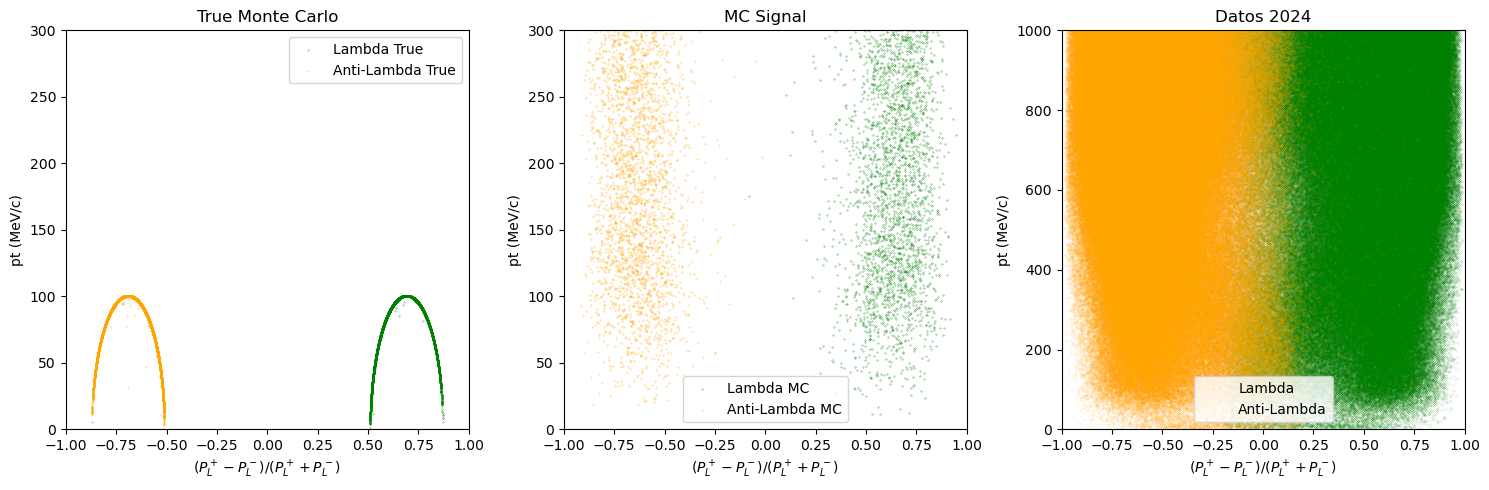

In [86]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 3 filas, 1 columna

# Primer gráfico
axs[0].scatter(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], c='green', s=0.05, label='Lambda True')
axs[0].scatter(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 300)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[0].set_ylabel('pt (MeV/c)')
axs[0].legend()
axs[0].set_title('True Monte Carlo')

# Segundo gráfico
axs[1].scatter(armenteros_particle_mc['alpha'], armenteros_particle_mc['pT'], c='green', s=0.05, label='Lambda MC')
axs[1].scatter(armenteros_antiparticle_mc['alpha'], armenteros_antiparticle_mc['pT'], c='orange', s=0.05, label='Anti-Lambda MC')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 300)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[1].set_ylabel('pt (MeV/c)')
axs[1].legend()
axs[1].set_title('MC Signal')

# Tercer gráfico
axs[2].scatter(armenteros_particle['alpha'], armenteros_particle['pT'], c='green', s=0.005, label='Lambda')
axs[2].scatter(armenteros_antiparticle['alpha'], armenteros_antiparticle['pT'], c='orange', s=0.005, label='Anti-Lambda')
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 1000)
axs[2].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[2].set_ylabel('pt (MeV/c)')
axs[2].legend()
axs[2].set_title('Datos 2024')

plt.tight_layout()
plt.show()


/tmp/javeser/ipykernel_19851/3379843745.py:11: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[0].legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/javeser/ipykernel_19851/3379843745.py:20: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[1].legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/tmp/javeser/ipykernel_19851/3379843745.py:29: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[2].legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


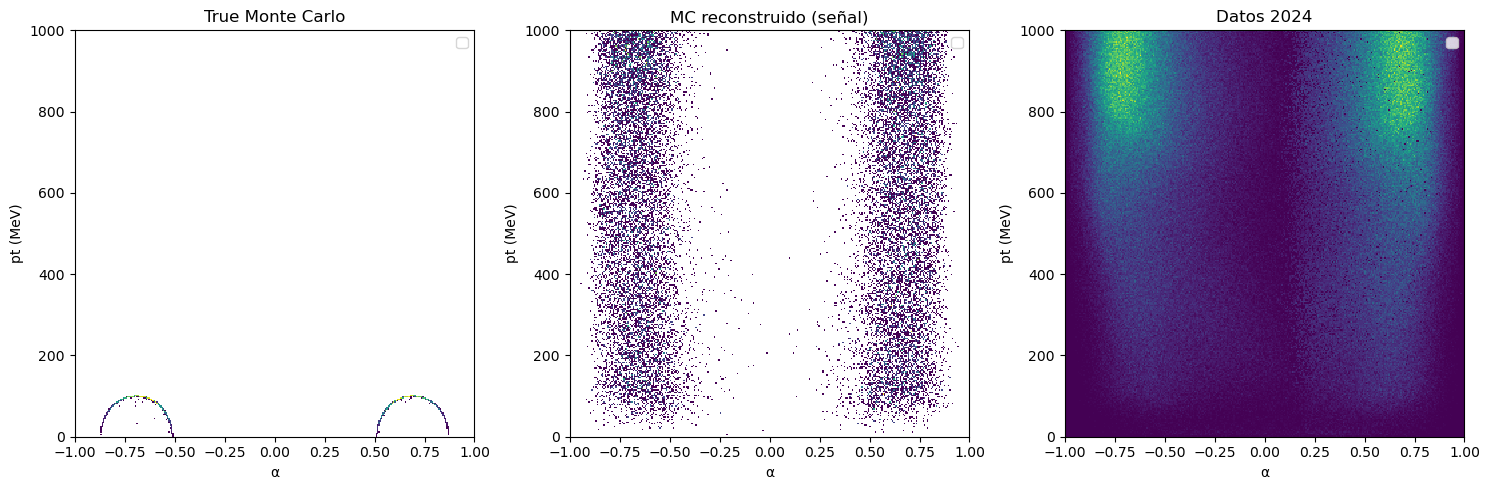

In [85]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 3 filas, 1 columna

x_num_bins = np.linspace(-1,1,300)
y_num_bins = np.linspace(0,1000,300)
# Primer gráfico
axs[0].hist2d(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], bins=[x_num_bins,y_num_bins], label='Lambda True', cmin=0.01)
axs[0].hist2d(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'],bins=[x_num_bins,y_num_bins], label='Anti-Lambda True', cmin=0.01)

axs[0].set_xlabel('α')
axs[0].set_ylabel('pt (MeV)')
axs[0].legend()
axs[0].set_title('True Monte Carlo')

# Segundo gráfico
axs[1].hist2d(armenteros_particle_mc['alpha'], armenteros_particle_mc['pT'], bins=[x_num_bins,y_num_bins], label='Lambda MC', cmin=0.01)
axs[1].hist2d(armenteros_antiparticle_mc['alpha'], armenteros_antiparticle_mc['pT'],bins=[x_num_bins,y_num_bins], label='Anti-Lambda MC', cmin=0.01)

axs[1].set_xlabel('α')
axs[1].set_ylabel('pt (MeV)')
axs[1].legend()
axs[1].set_title('MC reconstruido (señal)')

# Tercer gráfico
axs[2].hist2d(armenteros_particle['alpha'], armenteros_particle['pT'],bins=[x_num_bins,y_num_bins], label='Lambda', cmin=0.0)
axs[2].hist2d(armenteros_antiparticle['alpha'], armenteros_antiparticle['pT'], bins=[x_num_bins,y_num_bins], label='Anti-Lambda', cmin=0.01)

axs[2].set_xlabel('α')
axs[2].set_ylabel('pt (MeV)')
axs[2].legend()
axs[2].set_title('Datos 2024')

plt.tight_layout()
plt.show()

In [15]:
# import ROOT
# from ROOT import TVector3, TLorentzVector
# import pandas as pd

# particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
# antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

# mc_signal1 = signal_data.query(particulas)
# mc_signal2 = signal_data.query(antiparticulas)

# def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector 
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Convertir TLorentzVector a TVector3
#     pV0 = pV0_4.Vect()
#     pplus = pplus_4.Vect()
#     pminus = pminus_4.Vect()
    
#     # Dirección de vuelo
#     u = pV0.Unit()
    
#     # Calcular alpha
#     pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
#     pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
#     alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
#     # Calcular pT
#     pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
#     pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
#     # pT debería ser el mismo para pTplus y pTminus
#     pT = pTplus
    
#     return alpha, pT

# def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Sumar los cuadrimomentos
#     total_momentum = pplus_4 + pminus_4
    
#     # Calcular la masa invariante
#     invariant_mass = total_momentum.M()
#     invariant_mass_pion = pminus_4.M()
#     invariant_mass_proton = pplus_4.M()
#     invariant_mass_lambda = pV0_4.M()
    
#     return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# # Inicializar columnas para almacenar los resultados
# signal_data['alpha'] = np.nan
# signal_data['pT'] = np.nan
# signal_data['alpha_anti'] = np.nan
# signal_data['pT_anti'] = np.nan

# # Calcular para partículas
# particle = True

# for index, row in mc_signal1.iterrows():
#     pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
#     pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
#     pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     signal_data.at[index, 'alpha'] = alpha
#     signal_data.at[index, 'pT'] = pT

# # Calcular para antipartículas
# particle = False

# for index, row in mc_signal2.iterrows():
#     pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
#     pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
#     pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     signal_data.at[index, 'alpha_anti'] = alpha
#     signal_data.at[index, 'pT_anti'] = pT

# # Mostrar resultados
# print("Datos actualizados:")
# print(signal_data[['alpha', 'pT']].dropna())


In [87]:
from rk_transport import FarRKTrkTransport, propagate_to_vertex

def propagate_to_vertex(vz, xi, yi, zi, pxi, pyi, pzi, qoverp,rk):
    xf,yf,txf,tyf = rk.propagate(vz/10., 1., xi/10., yi/10., zi/10., pxi/1000., pyi/1000., pzi/1000., qoverp*1000.)
    mom = np.array([txf,tyf,1])*((np.abs(1/(qoverp*1000.)))/np.sqrt(txf**2. + tyf**2. + 1.))
    return mom[0]*1000., mom[1]*1000., mom[2]*1000., xf*10., yf*10.

rk = FarRKTrkTransport()

vertex_values = pd.DataFrame(columns=['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V'])
vertex_values2 = pd.DataFrame(columns=['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V'])

vertex_values[['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V']] = mc_signal.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.p_TRACK_POS_CLOSESTTOBEAM_X,row.p_TRACK_POS_CLOSESTTOBEAM_Y,row.p_TRACK_POS_CLOSESTTOBEAM_Z,row.p_PX,row.p_PY,row.p_PZ,row.p_QOVERP,rk),axis='columns',result_type='expand')
vertex_values2[['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V']] = mc_signal.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.pim_TRACK_POS_CLOSESTTOBEAM_X,row.pim_TRACK_POS_CLOSESTTOBEAM_Y,row.pim_TRACK_POS_CLOSESTTOBEAM_Z,row.pim_PX,row.pim_PY,row.pim_PZ,row.pim_QOVERP,rk),axis='columns',result_type='expand')

mc_signal = pd.concat([mc_signal,vertex_values],axis='columns')
mc_signal = pd.concat([mc_signal,vertex_values2],axis='columns')


FarRKTrkTransport: reading B field mapping from file /l/javeser/farvertexing/db/MagneticFieldMapping20x20x100.root
FarRKTrkTransport: reading B field mapping with: x in [-300,300] and 21 points
                                                 y in [-300,300] and 21 points
                                                 z in [0,1000] and 101 points


In [88]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = mc_signal.query(particulas)
mc_signal2 = mc_signal.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Calcular para partículas
particle = True
results = []
# results_mass = []
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# Convertir resultados a DataFrame
armenteros_particle_mc_ext = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados
# results_mass = []  # Reinicializar la lista de masas
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
armenteros_antiparticle_mc_ext = pd.DataFrame(results, columns=['alpha_anti', 'pT_anti'])
# invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Combinar los resultados
armenteros_combined = pd.DataFrame()
armenteros_combined['alpha'] = pd.concat([armenteros_particle_mc_ext['alpha'], armenteros_antiparticle_mc_ext['alpha_anti']])
armenteros_combined['pT'] = pd.concat([armenteros_particle_mc_ext['pT'], armenteros_antiparticle_mc_ext['pT_anti']])

# Mostrar resultados
# print("Partículas:")
# print(armenteros_particle)
# # print("\nMasa invariante de la Lambda:")
# # print(invariant_mass_particle)
# # print("\nMasa invariante del Proton:")
# # print(invariant_mass_particle_p)
# # print("\nMasa invariante del Pion:")
# # print(invariant_mass_particle_pion)

# print("\nAntipartículas:")
# print(armenteros_antiparticle)
# # print("\nMasa invariante de la Anti-Lambda:")
# # print(invariant_mass_antiparticle)
# # print("\nMasa invariante del Anti-Proton:")
# # print(invariant_mass_antiparticle_p)
# # print("\nMasa invariante del Anti-Pion:")
# # print(invariant_mass_antiparticle_pion)


In [89]:
from rk_transport import FarRKTrkTransport, propagate_to_vertex

def propagate_to_vertex(vz, xi, yi, zi, pxi, pyi, pzi, qoverp,rk):
    xf,yf,txf,tyf = rk.propagate(vz/10., 1., xi/10., yi/10., zi/10., pxi/1000., pyi/1000., pzi/1000., qoverp*1000.)
    mom = np.array([txf,tyf,1])*((np.abs(1/(qoverp*1000.)))/np.sqrt(txf**2. + tyf**2. + 1.))
    return mom[0]*1000., mom[1]*1000., mom[2]*1000., xf*10., yf*10.

rk = FarRKTrkTransport()

vertex_values = pd.DataFrame(columns=['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V'])
vertex_values2 = pd.DataFrame(columns=['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V'])

vertex_values[['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V']] = signal_data.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.p_TRACK_POS_CLOSESTTOBEAM_X,row.p_TRACK_POS_CLOSESTTOBEAM_Y,row.p_TRACK_POS_CLOSESTTOBEAM_Z,row.p_PX,row.p_PY,row.p_PZ,row.p_QOVERP,rk),axis='columns',result_type='expand')
vertex_values2[['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V']] = signal_data.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.pim_TRACK_POS_CLOSESTTOBEAM_X,row.pim_TRACK_POS_CLOSESTTOBEAM_Y,row.pim_TRACK_POS_CLOSESTTOBEAM_Z,row.pim_PX,row.pim_PY,row.pim_PZ,row.pim_QOVERP,rk),axis='columns',result_type='expand')

signal_data = pd.concat([signal_data,vertex_values],axis='columns')
signal_data = pd.concat([signal_data,vertex_values2],axis='columns')

FarRKTrkTransport: reading B field mapping from file /l/javeser/farvertexing/db/MagneticFieldMapping20x20x100.root
FarRKTrkTransport: reading B field mapping with: x in [-300,300] and 21 points
                                                 y in [-300,300] and 21 points
                                                 z in [0,1000] and 101 points


In [90]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = signal_data.query(particulas)
mc_signal2 = signal_data.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Inicializar columnas para almacenar los resultados
signal_data['alpha'] = np.nan
signal_data['pT'] = np.nan
signal_data['alpha_anti'] = np.nan
signal_data['pT_anti'] = np.nan

signal_data['p_inv_MASS_part'] = np.nan
signal_data['pim_inv_MASS_part'] = np.nan
signal_data['L_inv_MASS_part'] = np.nan

signal_data['p_inv_MASS_anti'] = np.nan
signal_data['pim_inv_MASS_anti'] = np.nan
signal_data['L_inv_MASS_anti'] = np.nan

particle = True

for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    signal_data.at[index, 'alpha'] = alpha
    signal_data.at[index, 'pT'] = pT
    invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    signal_data.at[index, 'p_inv_MASS_part'] = invariant_mass_proton
    signal_data.at[index, 'pim_inv_MASS_part'] = invariant_mass_pion
    signal_data.at[index, 'L_inv_MASS_part'] = invariant_mass

particle = False
for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    signal_data.at[index, 'alpha_anti'] = alpha
    signal_data.at[index, 'pT_anti'] = pT
    invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    signal_data.at[index, 'p_inv_MASS_anti'] = invariant_mass_proton
    signal_data.at[index, 'pim_inv_MASS_anti'] = invariant_mass_pion
    signal_data.at[index, 'L_inv_MASS_anti'] = invariant_mass

# Combine alpha and alpha_anti into a single column without overwriting
signal_data['alpha_combined'] = signal_data['alpha'].combine_first(signal_data['alpha_anti'])
signal_data['pT_combined'] = signal_data['pT'].combine_first(signal_data['pT_anti'])

signal_data['p_inv_MASS'] =  signal_data['p_inv_MASS_part'].combine_first(signal_data['p_inv_MASS_anti'])
signal_data['pim_inv_MASS'] =  signal_data['pim_inv_MASS_part'].combine_first(signal_data['pim_inv_MASS_anti'])
signal_data['L_inv_MASS'] =  signal_data['L_inv_MASS_part'].combine_first(signal_data['L_inv_MASS_anti'])

# Mostrar resultados
print("Datos actualizados:")
print(signal_data[['alpha_combined', 'pT_combined']].dropna())


Datos actualizados:
         alpha_combined  pT_combined
0             -0.749566   472.611671
1              0.733453   643.697434
2             -0.732493   719.870238
3              0.736426   596.136449
4              0.737372    28.297652
...                 ...          ...
2385520       -0.567747   261.950988
2385521        0.821228   210.534975
2385522       -0.404775   612.538044
2385523        0.242069   287.617964
2385524        0.655139   526.536158

[2385525 rows x 2 columns]


In [20]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 3 filas, 1 columna

# # Primer gráfico
# axs[0].scatter(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], c='green', s=0.05, label='Lambda True')
# axs[0].scatter(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'], c='orange', s=0.05, label='Anti-Lambda True')
# axs[0].set_xlim(-1, 1)
# axs[0].set_ylim(0, 1000)
# axs[0].set_xlabel('α')
# axs[0].set_ylabel('pt (MeV)')
# axs[0].legend()
# axs[0].set_title('True Monte Carlo')

# # Segundo gráfico
# axs[1].scatter(armenteros_particle_mc['alpha'], armenteros_particle_mc['pT'], c='green', s=0.05, label='Lambda MC')
# axs[1].scatter(armenteros_antiparticle_mc['alpha'], armenteros_antiparticle_mc['pT'], c='orange', s=0.05, label='Anti-Lambda MC')
# axs[1].set_xlim(-1, 1)
# axs[1].set_ylim(0, 1000)
# axs[1].set_xlabel('α')
# axs[1].set_ylabel('pt (MeV)')
# axs[1].legend()
# axs[1].set_title('MC reconstruido (señal)')

# # Tercer gráfico
# axs[2].scatter(armenteros_particle_mc_ext['alpha'],armenteros_particle_mc_ext['pT'], c='green', s=0.05, label='Lambda')
# axs[2].scatter(armenteros_antiparticle_mc_extr['alpha_anti'],armenteros_antiparticle_mc_extr['pT_anti'], c='orange', s=0.05, label='Anti-Lambda')
# axs[2].set_xlim(-1, 1)
# axs[2].set_ylim(0, 500)
# axs[2].set_xlabel('α')
# axs[2].set_ylabel('pt (MeV)')
# axs[2].legend()
# axs[2].set_title('MC Extrapolator')

# plt.tight_layout()
# plt.show()


In [91]:
model = CatBoostClassifier().load_model("new_BDT")
prob = model.predict_proba(signal_data)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
signal_data['prob1'] = signal_MVA_probs

[[9.78795271e-01 2.12047294e-02]
 [9.98432147e-01 1.56785346e-03]
 [9.99258256e-01 7.41743647e-04]
 ...
 [9.99999451e-01 5.49478713e-07]
 [9.99999999e-01 1.14266221e-09]
 [9.99927399e-01 7.26013441e-05]]


/tmp/javeser/ipykernel_19851/4145808771.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/l/javeser/micromamba/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


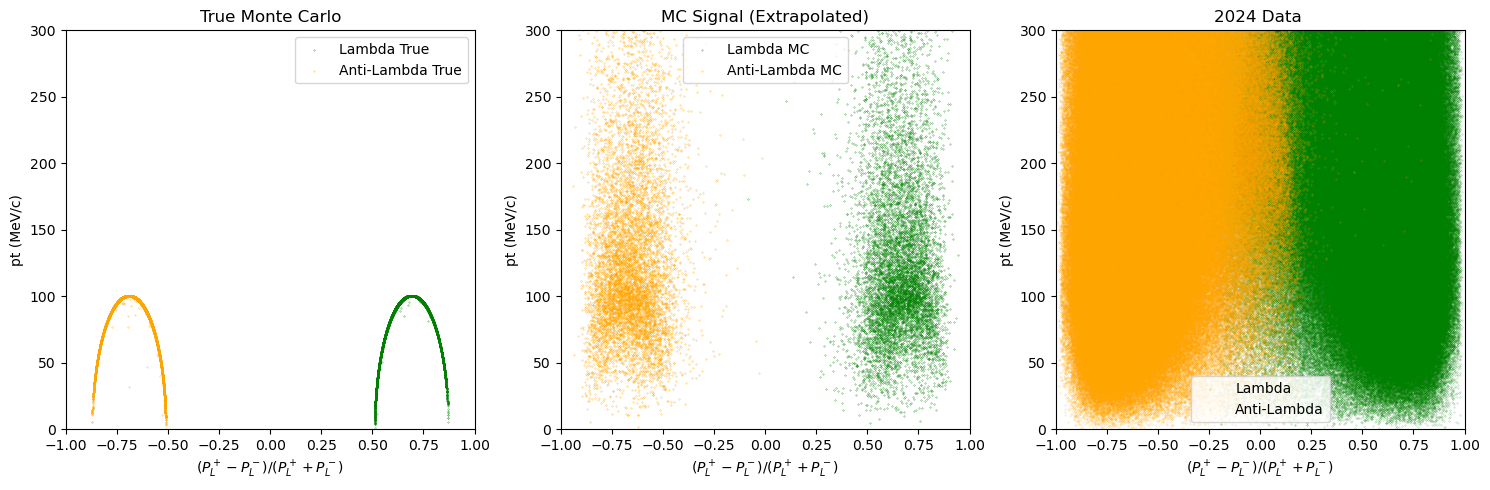

In [92]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 3 filas, 1 columna

# Primer gráfico
axs[0].scatter(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], c='green', s=0.05, label='Lambda True')
axs[0].scatter(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 300)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[0].set_ylabel('pt (MeV/c)')
axs[0].legend()
axs[0].set_title('True Monte Carlo')

# Segundo gráfico
axs[1].scatter(armenteros_particle_mc_ext['alpha'],armenteros_particle_mc_ext['pT'], c='green', s=0.05, label='Lambda MC')
axs[1].scatter(armenteros_antiparticle_mc_ext['alpha_anti'], armenteros_antiparticle_mc_ext['pT_anti'], c='orange', s=0.05, label='Anti-Lambda MC')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 300)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[1].set_ylabel('pt (MeV/c)')
axs[1].legend()
axs[1].set_title('MC Signal (Extrapolated)')

# Tercer gráfico
axs[2].scatter(signal_data['alpha'],signal_data['pT'], c='green', s=0.05, label='Lambda', alpha = 0.5)
axs[2].scatter(signal_data['alpha_anti'],signal_data['pT_anti'], c='orange', s=0.05, label='Anti-Lambda', alpha = 0.5)
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 300)
axs[2].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[2].set_ylabel('pt (MeV/c)')
axs[2].legend()
axs[2].set_title('2024 Data ')

plt.tight_layout()
plt.show()


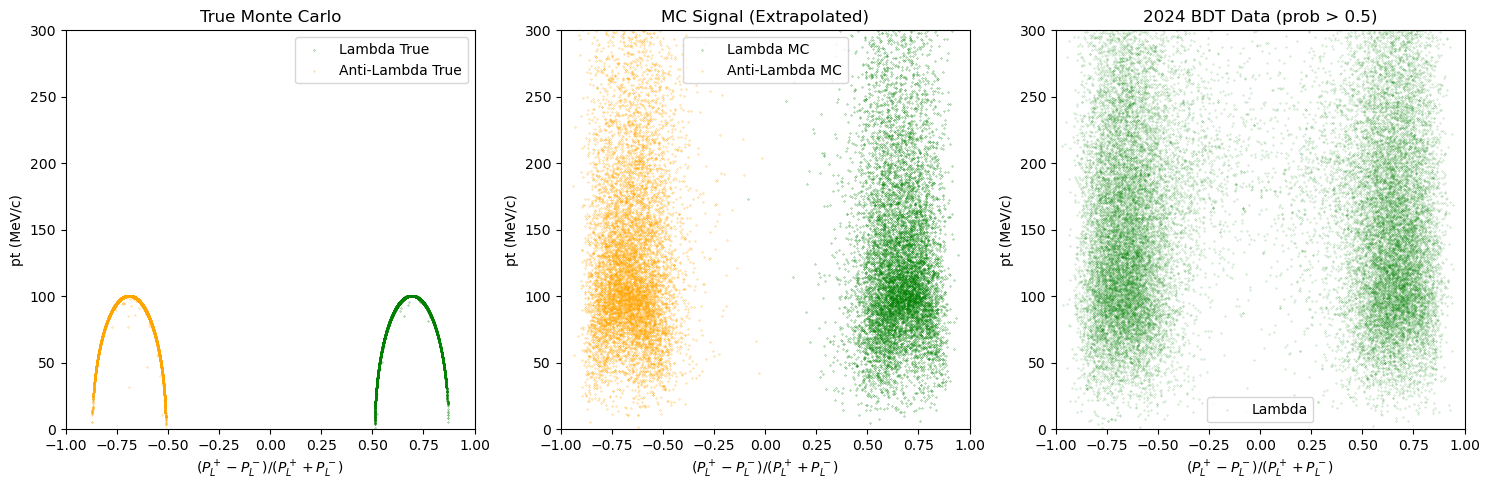

In [94]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 3 filas, 1 columna

# Primer gráfico
axs[0].scatter(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], c='green', s=0.05, label='Lambda True')
axs[0].scatter(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 300)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[0].set_ylabel('pt (MeV/c)')
axs[0].legend()
axs[0].set_title('True Monte Carlo')

# Segundo gráfico
axs[1].scatter(armenteros_particle_mc_ext['alpha'],armenteros_particle_mc_ext['pT'], c='green', s=0.05, label='Lambda MC')
axs[1].scatter(armenteros_antiparticle_mc_ext['alpha_anti'], armenteros_antiparticle_mc_ext['pT_anti'], c='orange', s=0.05, label='Anti-Lambda MC')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 300)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[1].set_ylabel('pt (MeV/c)')
axs[1].legend()
axs[1].set_title('MC Signal (Extrapolated)')


# Tercer gráfico
axs[2].scatter(signal_data.query('(prob1 > 0.5)')['alpha_combined'],signal_data.query('(prob1 > 0.5) ')['pT_combined'], c='green', s=0.05, label='Lambda', alpha = 0.5)
# axs[2].scatter(signal_data.query('(prob1 > 0.9)')['alpha_combined'],signal_data.query('(prob1 > 0.9)')['pT_combined'], c='orange', s=0.05, label='Anti-Lambda', alpha = 0.5)
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 300)
axs[2].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[2].set_ylabel('pt (MeV/c)')
axs[2].legend()
axs[2].set_title('2024 BDT Data (prob > 0.5)')

plt.tight_layout()
plt.show()


/tmp/javeser/ipykernel_19851/597284941.py:13: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[0].legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/javeser/ipykernel_19851/597284941.py:22: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[1].legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/javeser/ipykernel_19851/597284941.py:34: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#imp

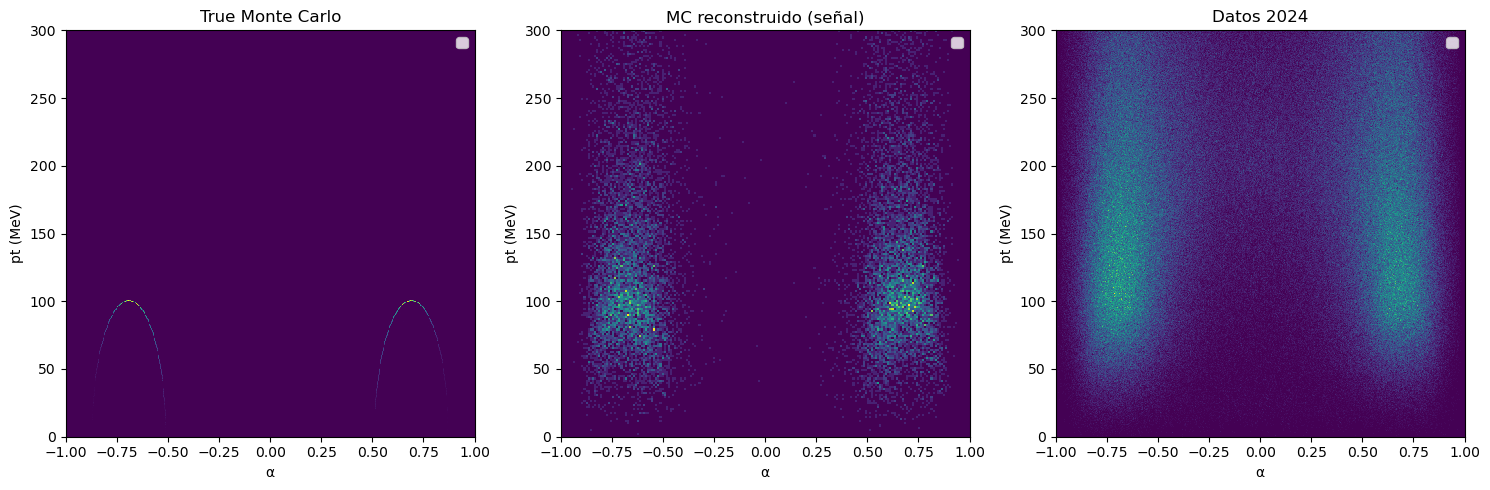

In [95]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 3 filas, 1 columna

x_num_bins = np.linspace(-1,1,500)
y_num_bins = np.linspace(0,300,500)
x_num_bins_mc = np.linspace(-1,1,200)
y_num_bins_mc = np.linspace(0,300,200)
# Primer gráfico
axs[0].hist2d(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], bins=[x_num_bins,y_num_bins], label='Lambda True', cmin=0.0)
axs[0].hist2d(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'],bins=[x_num_bins,y_num_bins], label='Anti-Lambda True', cmin=0.01)

axs[0].set_xlabel('α')
axs[0].set_ylabel('pt (MeV)')
axs[0].legend()
axs[0].set_title('True Monte Carlo')

# Segundo gráfico
axs[1].hist2d(armenteros_combined['alpha'],armenteros_combined['pT'], bins=[x_num_bins_mc,y_num_bins_mc], label='Lambda MC', cmin=0)
# axs[1].hist2d(armenteros_antiparticle_mc_extr['alpha'], armenteros_antiparticle_mc_extr['pT'],bins=[x_num_bins,y_num_bins], label='Anti-Lambda MC', cmin=0.001,cmap = plt.cm.jet)

axs[1].set_xlabel('α')
axs[1].set_ylabel('pt (MeV)')
axs[1].legend()
axs[1].set_title('MC reconstruido (señal)')

# # Tercer gráfico
# axs[2].hist2d(signal_data.query('(prob1 > 0.9)')['alpha'], signal_data.query('(prob1 > 0.9)')['pT'],bins=[x_num_bins,y_num_bins], label='Lambda', cmin=0,cmap = plt.cm.jet)
# axs[2].hist2d(signal_data.query('(prob1 > 0.9)')['alpha'], signal_data.query('(prob1 > 0.9)')['pT'], bins=[x_num_bins,y_num_bins], label='Anti-Lambda', cmin=0.001,cmap = plt.cm.jet)

axs[2].hist2d(signal_data['alpha_combined'], signal_data['pT_combined'],bins=[x_num_bins,y_num_bins], label='Lambda', cmin=0)
# axs[2].hist2d(signal_data['alpha'], signal_data['pT'], bins=[x_num_bins,y_num_bins], label='Anti-Lambda', cmin=0.001,cmap = plt.cm.jet)

axs[2].set_xlabel('α')
axs[2].set_ylabel('pt (MeV)')
axs[2].legend()
axs[2].set_title('Datos 2024')

plt.tight_layout()
plt.show()

/tmp/javeser/ipykernel_19851/3843141099.py:13: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[0].legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/javeser/ipykernel_19851/3843141099.py:22: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[1].legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/tmp/javeser/ipykernel_19851/3843141099.py:34: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[2].legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


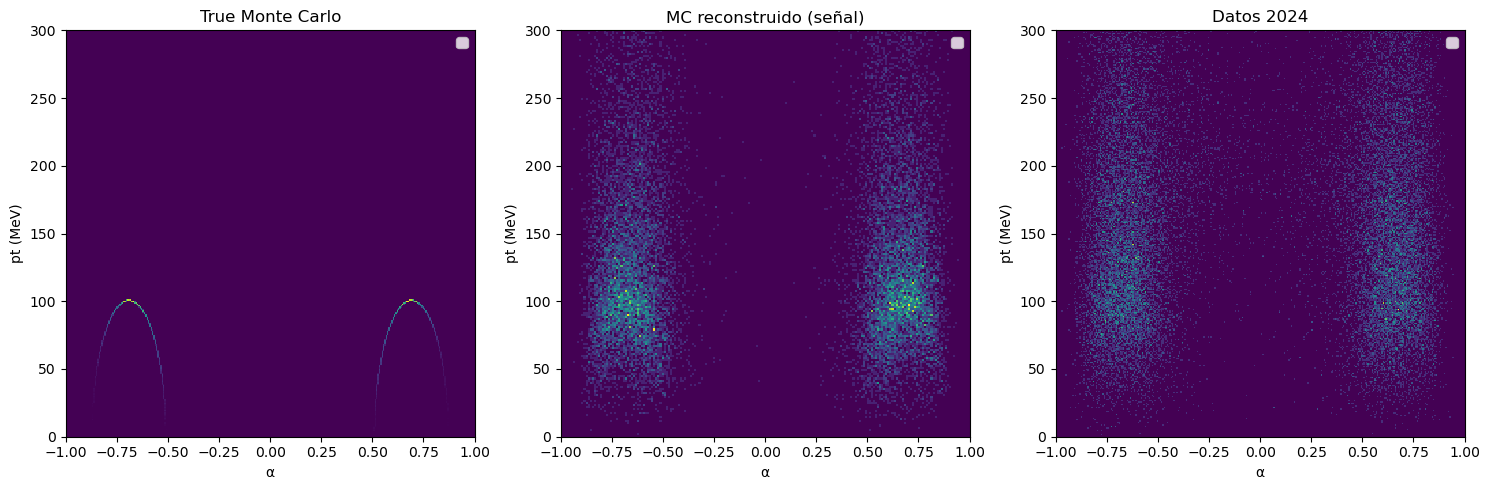

In [96]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 3 filas, 1 columna

x_num_bins = np.linspace(-1,1,300)
y_num_bins = np.linspace(0,300,300)
x_num_bins_mc = np.linspace(-1,1,200)
y_num_bins_mc = np.linspace(0,300,200)
# Primer gráfico
axs[0].hist2d(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], bins=[x_num_bins,y_num_bins], label='Lambda True', cmin=0.0)
axs[0].hist2d(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'],bins=[x_num_bins,y_num_bins], label='Anti-Lambda True', cmin=0.01)

axs[0].set_xlabel('α')
axs[0].set_ylabel('pt (MeV)')
axs[0].legend()
axs[0].set_title('True Monte Carlo')

# Segundo gráfico
axs[1].hist2d(armenteros_combined['alpha'],armenteros_combined['pT'], bins=[x_num_bins_mc,y_num_bins_mc], label='Lambda MC', cmin=0)
# axs[1].hist2d(armenteros_antiparticle_mc_extr['alpha'], armenteros_antiparticle_mc_extr['pT'],bins=[x_num_bins,y_num_bins], label='Anti-Lambda MC', cmin=0.001,cmap = plt.cm.jet)

axs[1].set_xlabel('α')
axs[1].set_ylabel('pt (MeV)')
axs[1].legend()
axs[1].set_title('MC reconstruido (señal)')

# # Tercer gráfico
# axs[2].hist2d(signal_data.query('(prob1 > 0.9)')['alpha'], signal_data.query('(prob1 > 0.9)')['pT'],bins=[x_num_bins,y_num_bins], label='Lambda', cmin=0,cmap = plt.cm.jet)
# axs[2].hist2d(signal_data.query('(prob1 > 0.9)')['alpha'], signal_data.query('(prob1 > 0.9)')['pT'], bins=[x_num_bins,y_num_bins], label='Anti-Lambda', cmin=0.001,cmap = plt.cm.jet)

axs[2].hist2d(signal_data.query('(prob1 > 0.5)')['alpha_combined'], signal_data.query('(prob1 > 0.5)')['pT_combined'],bins=[x_num_bins,y_num_bins], label='Lambda', cmin=0)
# axs[2].hist2d(signal_data['alpha'], signal_data['pT'], bins=[x_num_bins,y_num_bins], label='Anti-Lambda', cmin=0.001,cmap = plt.cm.jet)

axs[2].set_xlabel('α')
axs[2].set_ylabel('pt (MeV)')
axs[2].legend()
axs[2].set_title('Datos 2024')

plt.tight_layout()
plt.show()

In [97]:
model = CatBoostClassifier().load_model("new_BDT")
prob = model.predict_proba(signal_data)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
signal_data['prob1'] = signal_MVA_probs

[[9.78795271e-01 2.12047294e-02]
 [9.98432147e-01 1.56785346e-03]
 [9.99258256e-01 7.41743647e-04]
 ...
 [9.99999451e-01 5.49478713e-07]
 [9.99999999e-01 1.14266221e-09]
 [9.99927399e-01 7.26013441e-05]]


In [98]:
from rk_transport import FarRKTrkTransport, propagate_to_vertex

signal_data_after_BDT = signal_data.query('(prob1 > 0.9)')
particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

signal_data_after_BDT1 = signal_data_after_BDT.query(particulas)
signal_data_after_BDT2 = signal_data_after_BDT.query(antiparticulas)

def propagate_to_vertex(vz, xi, yi, zi, pxi, pyi, pzi, qoverp,rk):
    xf,yf,txf,tyf = rk.propagate(vz/10., 1., xi/10., yi/10., zi/10., pxi/1000., pyi/1000., pzi/1000., qoverp*1000.)
    mom = np.array([txf,tyf,1])*((np.abs(1/(qoverp*1000.)))/np.sqrt(txf**2. + tyf**2. + 1.))
    return mom[0]*1000., mom[1]*1000., mom[2]*1000., xf*10., yf*10.

rk = FarRKTrkTransport()

vertex_values = pd.DataFrame(columns=['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V'])
vertex_values2 = pd.DataFrame(columns=['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V'])

vertex_values[['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V']] = signal_data_after_BDT1.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.p_TRACK_POS_CLOSESTTOBEAM_X,row.p_TRACK_POS_CLOSESTTOBEAM_Y,row.p_TRACK_POS_CLOSESTTOBEAM_Z,row.p_PX,row.p_PY,row.p_PZ,row.p_QOVERP,rk),axis='columns',result_type='expand')
vertex_values2[['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V']] = signal_data_after_BDT1.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.pim_TRACK_POS_CLOSESTTOBEAM_X,row.pim_TRACK_POS_CLOSESTTOBEAM_Y,row.pim_TRACK_POS_CLOSESTTOBEAM_Z,row.pim_PX,row.pim_PY,row.pim_PZ,row.pim_QOVERP,rk),axis='columns',result_type='expand')

signal_data_after_BDT1 = pd.concat([signal_data_after_BDT1,vertex_values],axis='columns')
signal_data_after_BDT1 = pd.concat([signal_data_after_BDT1,vertex_values2],axis='columns')

vertex_values[['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V']] = signal_data_after_BDT2.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.p_TRACK_POS_CLOSESTTOBEAM_X,row.p_TRACK_POS_CLOSESTTOBEAM_Y,row.p_TRACK_POS_CLOSESTTOBEAM_Z,row.p_PX,row.p_PY,row.p_PZ,row.p_QOVERP,rk),axis='columns',result_type='expand')
vertex_values2[['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V']] = signal_data_after_BDT2.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.pim_TRACK_POS_CLOSESTTOBEAM_X,row.pim_TRACK_POS_CLOSESTTOBEAM_Y,row.pim_TRACK_POS_CLOSESTTOBEAM_Z,row.pim_PX,row.pim_PY,row.pim_PZ,row.pim_QOVERP,rk),axis='columns',result_type='expand')

signal_data_after_BDT2= pd.concat([signal_data_after_BDT2,vertex_values],axis='columns')
signal_data_after_BDT2 = pd.concat([signal_data_after_BDT2,vertex_values2],axis='columns')

FarRKTrkTransport: reading B field mapping from file /l/javeser/farvertexing/db/MagneticFieldMapping20x20x100.root
FarRKTrkTransport: reading B field mapping with: x in [-300,300] and 21 points
                                                 y in [-300,300] and 21 points
                                                 z in [0,1000] and 101 points


In [28]:
# import ROOT
# from ROOT import TVector3, TLorentzVector
# import pandas as pd

# def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector 
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Convertir TLorentzVector a TVector3
#     pV0 = pV0_4.Vect()
#     pplus = pplus_4.Vect()
#     pminus = pminus_4.Vect()
    
#     # Dirección de vuelo
#     u = pV0.Unit()
    
#     # Calcular alpha
#     pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
#     pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
#     alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
#     # Calcular pT
#     pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
#     pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
#     # pT debería ser el mismo para pTplus y pTminus
#     pT = pTplus
    
#     return alpha, pT

# def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Sumar los cuadrimomentos
#     total_momentum = pplus_4 + pminus_4
    
#     # Calcular la masa invariante
#     invariant_mass = total_momentum.M()
#     invariant_mass_pion = pminus_4.M()
#     invariant_mass_proton = pplus_4.M()
#     invariant_mass_lambda = pV0_4.M()
    
#     return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# # Inicializar columnas para almacenar los resultados
# signal_data_after_BDT['alpha'] = np.nan
# signal_data_after_BDT['pT'] = np.nan
# signal_data_after_BDT['alpha_anti'] = np.nan
# signal_data_after_BDT['pT_anti'] = np.nan

# particle = True

# for index, row in signal_data_after_BDT1.iterrows():
#     pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
#     pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
#     pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     signal_data_after_BDT.at[index, 'alpha'] = alpha
#     signal_data_after_BDT.at[index, 'pT'] = pT

# particle = False
# for index, row in signal_data_after_BDT2.iterrows():
#     pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
#     pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
#     pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     signal_data_after_BDT.at[index, 'alpha_anti'] = alpha
#     signal_data_after_BDT.at[index, 'pT_anti'] = pT

# # Combine alpha and alpha_anti into a single column without overwriting
# signal_data_after_BDT['alpha_combined'] = signal_data_after_BDT['alpha'].combine_first(signal_data_after_BDT['alpha_anti'])
# signal_data_after_BDT['pT_combined'] = signal_data_after_BDT['pT'].combine_first(signal_data_after_BDT['pT_anti'])

# # Mostrar resultados
# print("Datos actualizados:")
# print(signal_data[['alpha_combined', 'pT_combined']].dropna())


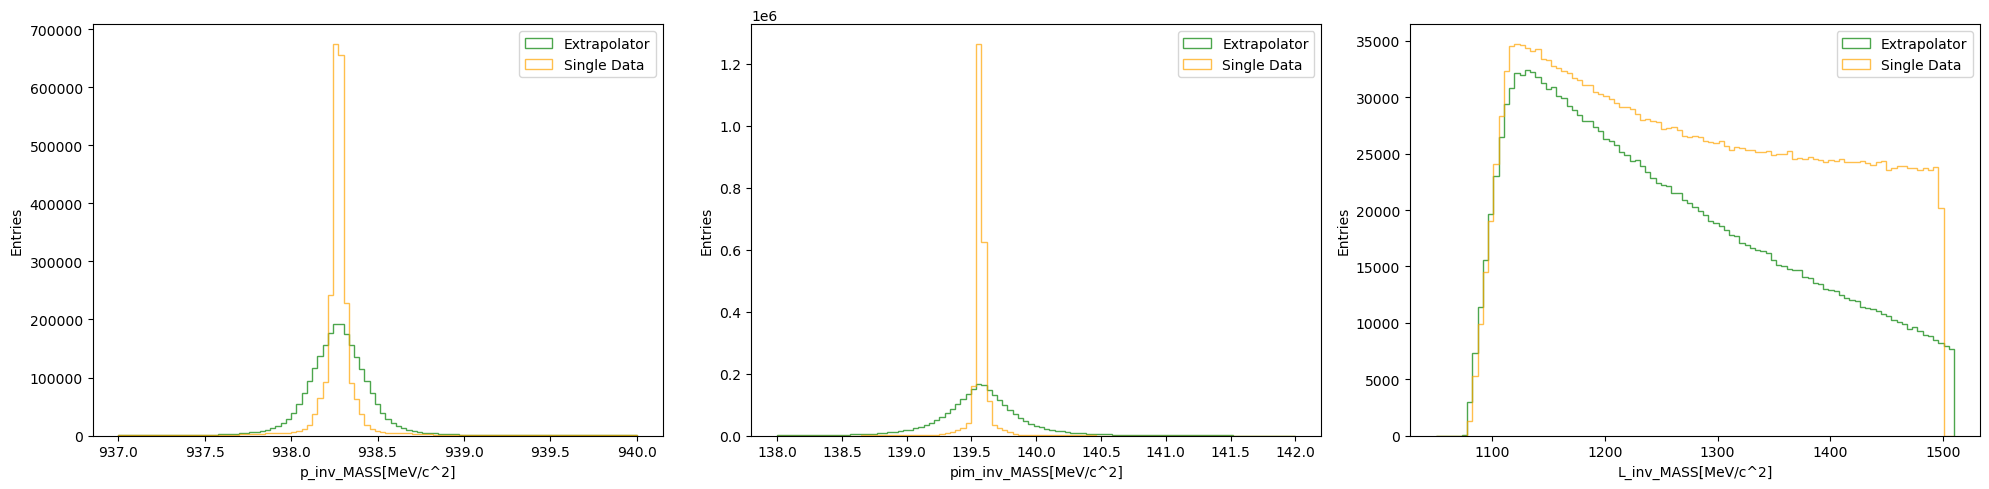

In [99]:

lin_bins = {
    "p_inv_MASS" : np.linspace(937,940,100), 
    "pim_inv_MASS" : np.linspace(138,142,100),
    "L_inv_MASS": np.linspace(1050,1510,100),  
    }

# Create a single figure with a 1x3 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

# List of invariant mass variables
inviant_mass_list = ['p_inv_MASS', 'pim_inv_MASS', 'L_inv_MASS']

for i, var in enumerate(inviant_mass_list):
    # Get the corresponding subplot
    ax = axes[i]
    # Plot histograms on the subplot
    hist1, bins1, _ = ax.hist(signal_data[var], bins=lin_bins[var], label='Extrapolator', color='green', alpha=0.7, histtype='step')
    hist2, bins2, _ = ax.hist(signal_data_mass[var], bins=lin_bins[var], label='Single Data', color='orange', alpha=0.7, histtype='step')
    # Set labels and legend
    ax.set_xlabel(var + '[MeV/c^2]')
    ax.set_ylabel('Entries')
    ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


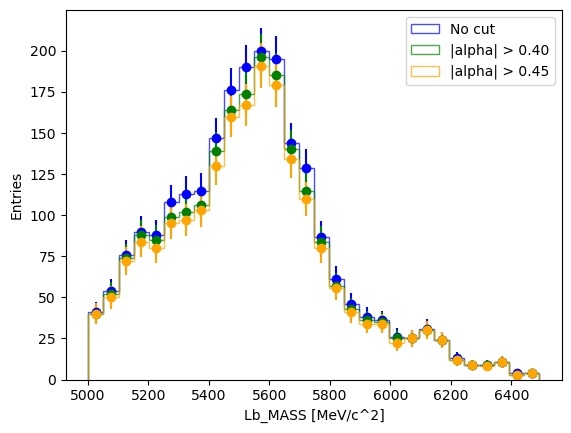

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

num_bin = 30
# Filtrar datos con condiciones combinadas
filtered_data1 = signal_data.loc[(abs(signal_data['alpha_combined']) > 0.40) & (signal_data['prob1'] > 0.99), 'Lb_MASS']
filtered_data2 = signal_data.loc[(abs(signal_data['alpha_combined']) > 0.45) & (signal_data['prob1'] > 0.99), 'Lb_MASS']

# Crear la figura y los ejes
fig, axes = plt.subplots()

# Graficar histogramas
hist1, bins1, _ = axes.hist(signal_data.query('prob1 > 0.99')['Lb_MASS'], bins=num_bin, label='No cut', color='blue', alpha=0.7, histtype='step')
hist2, bins2, _ = axes.hist(filtered_data1, bins=num_bin, label='|alpha| > 0.40', color='green', alpha=0.7, histtype='step')
hist3, bins3, _ = axes.hist(filtered_data2, bins=num_bin, label='|alpha| > 0.45', color='orange', alpha=0.7, histtype='step')

# Calcular los centros de los bins para las barras de error
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])
bin_centers3 = 0.5 * (bins3[1:] + bins3[:-1])

# Graficar las barras de error para el primer histograma
axes.errorbar(
    bin_centers1,
    hist1,
    yerr=np.sqrt(hist1),
    fmt='o',
    color='blue',
    drawstyle='steps-mid'
)

# Graficar las barras de error para el segundo histograma
axes.errorbar(
    bin_centers2,
    hist2,
    yerr=np.sqrt(hist2),
    fmt='o',
    color='green',
    drawstyle='steps-mid'
)
axes.errorbar(
    bin_centers3,
    hist3,
    yerr=np.sqrt(hist3),
    fmt='o',
    color='orange',
    drawstyle='steps-mid'
)

# Configurar etiquetas y leyenda
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Mostrar la gráfica
plt.show()


In [32]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import ROOT
# from catboost import CatBoostClassifier

# # Cargar el modelo
# model = CatBoostClassifier().load_model("new_BDT")

# # Obtener las probabilidades de la BDT
# prob = model.predict_proba(signal_data)

# # Evaluar y asignar las probabilidades al DataFrame
# signal_MVA_prob_eval = prob
# signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
# signal_data['prob1'] = signal_MVA_probs

# # Seleccionar los datos que cumplen con la probabilidad > 0.99
# mass_data = signal_data.query('prob1 > 0.99')['Lb_MASS']

# # Crear un histograma de ROOT
# hist = ROOT.TH1F("hist", "Invariant Mass of Lb", 50, 5000, 6000)
# for mass in mass_data:
#     hist.Fill(mass)

# # Definir la función combinada (Argus + Gaussiana)
# def argus_plus_gaussian(x, par):
#     argus = ROOT.TMath.Exp(par[0] * (x[0] - par[1]) ** 2) * x[0] * np.sqrt(1 - (x[0] / par[1]) ** 2)
#     gaussian = par[2] * ROOT.TMath.Gaus(x[0], par[3], par[4])
#     return par[5] * argus + gaussian

# # Crear una función TF1
# fit_func = ROOT.TF1("fit_func", argus_plus_gaussian, 5000, 6000, 6)
# fit_func.SetParameters(-0.002, 6000, 1, 5600, 20, 0.1)  # Parámetros iniciales

# # Ajustar el histograma con la función
# hist.Fit(fit_func, "R")

# # Crear un canvas para dibujar el histograma y el ajuste
# canvas = ROOT.TCanvas("canvas", "Fit Canvas", 800, 600)
# hist.Draw()
# fit_func.Draw("same")

# # Guardar el canvas como una imagen
# canvas.SaveAs("fit_result.png")

# # Mostrar el canvas
# canvas.Draw()


In [33]:
# import ROOT

# # Seleccionar los datos que cumplen con la probabilidad > 0.99
# mass_data = signal_data.query('prob1 > 0.99')['Lb_MASS']

# # Crear un histograma de ROOT
# hist = ROOT.TH1F("hist", "Invariant Mass of Lb", 100, 5000, 6400)
# for mass in mass_data:
#     hist.Fill(mass)

# # Definir la función combinada (Argus + Gaussiana)
# def argus_plus_gaussian(x, par):
#     if x[0] >= par[1]:  # Argus function is defined for x < par[1]
#         return 0
#     argus = par[0] * x[0] * np.sqrt(1 - (x[0] / par[1]) ** 2) * np.exp(par[2] * (1 - (x[0] / par[1]) ** 2))
#     gaussian = par[3] * ROOT.TMath.Gaus(x[0], par[4], par[5])
#     return argus + gaussian

# # def mirrored_argus_plus_gaussian(x, par):
# #     if x[0] <= par[1]:  # Argus function is defined for x > par[1] now
# #         return 0
# #     argus = par[0] * x[0] * np.sqrt(1 - ((6400 - x[0]) / par[1]) ** 2) * np.exp(par[2] * (1 - ((6400 - x[0]) / par[1]) ** 2))
# #     gaussian = par[3] * ROOT.TMath.Gaus(x[0], par[4], par[5])
# #     return argus + gaussian


# # Crear una función TF1
# fit_func = ROOT.TF1("fit_func", argus_plus_gaussian, 5000, 6400, 6)
# fit_func.SetParameters(1, 6400, -0.001, 1000, 5600, 20)  # Parámetros iniciales

# # Ajustar el histograma con la función
# hist.Fit(fit_func, "R")

# # Crear un canvas para dibujar el histograma y el ajuste
# canvas = ROOT.TCanvas("canvas", "Fit Canvas", 800, 600)
# hist.Draw()
# fit_func.Draw("same")

# # # Guardar el canvas como una imagen
# # canvas.SaveAs("fit_result.png")

# # Mostrar el canvas
# canvas.Draw()


In [34]:
# import ROOT
# import numpy as np
# import pandas as pd


# masses = signal_data.query('(prob1 > 0.99)')['Lb_MASS']

# # Crear la variable observable
# x = ROOT.RooRealVar("x", "Lb_MASS", min(masses), max(masses))

# # Convertir los datos a un RooDataSet
# data = ROOT.RooDataSet("data", "dataset with Lb_MASS", ROOT.RooArgSet(x))

# for mass in masses:
#     x.setVal(mass)
#     data.add(ROOT.RooArgSet(x))

# # Definir los parámetros de la señal (Gaussiana)
# mean = ROOT.RooRealVar("mean", "mean of gaussian", np.mean(masses), min(masses), max(masses))
# sigma = ROOT.RooRealVar("sigma", "width of gaussian", np.std(masses), 0.1, 10.0)
# signal = ROOT.RooGaussian("signal", "Gaussian Signal", x, mean, sigma)

# # Definir los parámetros del fondo (Argus)
# argpar = ROOT.RooRealVar("argpar", "Argus shape parameter", -0.5, -10., -0.01)
# cutoff = ROOT.RooRealVar("cutoff", "cutoff", max(masses) - 1.0)
# background = ROOT.RooArgusBG("background", "Argus Background", x, cutoff, argpar)

# # Definir el modelo compuesto
# nsig = ROOT.RooRealVar("nsig", "number of signal events", 100, 0., len(masses))
# nbkg = ROOT.RooRealVar("nbkg", "number of background events", 100, 0., len(masses))
# model = ROOT.RooAddPdf("model", "signal + background", ROOT.RooArgList(signal, background), ROOT.RooArgList(nsig, nbkg))

# # Ajustar el modelo a los datos
# result = model.fitTo(data, ROOT.RooFit.Save())

# # Crear el marco para el ajuste
# frame = x.frame()
# data.plotOn(frame)
# model.plotOn(frame)
# model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed))

# # Dibujar el ajuste
# c = ROOT.TCanvas("c", "Fit", 800, 600)
# frame.Draw()
# c.SaveAs("fit_result.png")

# # Imprimir los resultados del ajuste
# result.Print()


In [35]:
# import ROOT
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Suponiendo que tienes un DataFrame llamado signal_data con las columnas 'prob1' y 'Lb_MASS'
# # Por ejemplo, podrías cargarlo desde un archivo CSV:
# # signal_data = pd.read_csv('your_signal_data.csv')

# # Para este ejemplo, asumiré que ya tienes el DataFrame 'signal_data' cargado
# masses = signal_data.query('(prob1 > 0.99)')['Lb_MASS'].values

# # Crear la variable observable
# x = ROOT.RooRealVar("x", "Lb_MASS", min(masses), max(masses))

# # Convertir los datos a un RooDataSet
# data = ROOT.RooDataSet("data", "dataset with Lb_MASS", ROOT.RooArgSet(x))

# for mass in masses:
#     x.setVal(mass)
#     data.add(ROOT.RooArgSet(x))

# # Definir los parámetros de la señal (Gaussiana)
# mean = ROOT.RooRealVar("mean", "mean of gaussian", 5619, 5400,5800)
# sigma = ROOT.RooRealVar("sigma", "width of gaussian", np.std(masses), 0.1, 140.0)
# signal = ROOT.RooGaussian("signal", "Gaussian Signal", x, mean, sigma)

# # Definir los parámetros del fondo (Argus)
# argpar = ROOT.RooRealVar("argpar", "Argus shape parameter", -0.5, -10., -0.01)
# cutoff = ROOT.RooRealVar("cutoff", "cutoff", 6400 - 1.0)
# background = ROOT.RooArgusBG("background", "Argus Background", x, cutoff, argpar)

# # Definir el modelo compuesto
# nsig = ROOT.RooRealVar("nsig", "number of signal events", 100, 0., len(masses))
# nbkg = ROOT.RooRealVar("nbkg", "number of background events", 100, 0., len(masses))
# model = ROOT.RooAddPdf("model", "signal + background", ROOT.RooArgList(signal, background), ROOT.RooArgList(nsig, nbkg))

# # Ajustar el modelo a los datos
# result = model.fitTo(data, ROOT.RooFit.Save())

# # Crear el marco para el ajuste
# frame = x.frame()
# data.plotOn(frame)
# model.plotOn(frame)
# model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed))

# # Extraer los datos y curvas del frame
# data_hist = frame.getHist("h_data")
# curve = frame.getCurve("model_Norm[x]")
# background_curve = frame.getCurve("background_Norm[x]")

# # Extraer los puntos de datos
# x_vals = np.array([data_hist.GetX()[i] for i in range(data_hist.GetN())])
# y_vals = np.array([data_hist.GetY()[i] for i in range(data_hist.GetN())])
# y_err = np.sqrt(y_vals)

# # Extraer la curva de ajuste
# x_curve = np.linspace(min(masses), max(masses), 1000)
# y_curve = np.array([curve.interpolate(x) for x in x_curve])

# # Extraer la curva de fondo solo si no es None
# if background_curve:
#     y_background_curve = np.array([background_curve.interpolate(x) for x in x_curve])
# else:
#     y_background_curve = np.zeros_like(x_curve)

# # Plotear los datos y los ajustes con matplotlib
# plt.errorbar(x_vals, y_vals, yerr=y_err, fmt='o', label='Data', color='black')
# plt.plot(x_curve, y_curve, label='Total Fit', color='blue')
# plt.plot(x_curve, y_background_curve, label='Background', linestyle='--', color='red')

# # Configurar el gráfico
# plt.xlabel('Lb_MASS [MeV/c^2]')
# plt.ylabel('Entries')
# plt.legend()

# # Mostrar el gráfico
# plt.show()


In [36]:
# import pandas as pd


# masses = signal_data.query('(prob1 > 0.99)')['Lb_MASS'].values
# df = pd.DataFrame({'Lb_MASS': masses})
# df.to_csv('Lb_MASS_data.csv', index=False)

In [37]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit

# # Define the functions
# def argus(x, N, mu, c):
#     return N * x * np.sqrt(np.maximum(0, 1 - x**2)) * np.exp(-c * np.maximum(0, 1 - x**2))

# def gauss(x, N, mu, sigma):
#     return N * np.exp(-0.5 * ((x - mu) / sigma)**2)

# # Load data
# df = pd.read_csv('Lb_MASS_data.csv')

# # Define the histogram binning
# bin_edges = np.linspace(df['Lb_MASS'].min(), df['Lb_MASS'].max(), 100)

# # Histogram the data
# counts, _ = np.histogram(df['Lb_MASS'], bins=bin_edges)

# # Calculate bin centers
# bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# # Initial guesses for parameters
# initial_guess_argus = [5000, 6400, 0.1]  # Adjust these values based on your data
# initial_guess_gauss = [5300, 5800, 130]  # Adjust these values based on your data

# # Bounds for parameters (optional but can help improve convergence)
# bounds_argus = ([0, 5000, 0], [np.inf, 6400, np.inf])  # Adjust these values based on your data and constraints

# # Fit the data with the functions and initial guesses
# popt_argus, _ = curve_fit(argus, bin_centers, counts, p0=initial_guess_argus, bounds=bounds_argus)
# popt_gauss, _ = curve_fit(gauss, bin_centers, counts, p0=initial_guess_gauss)

# # Plot the data points with error bars
# plt.figure(figsize=(8, 6))
# plt.errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='o', color='black', label='Data')

# # Plot the total fit
# total_fit = argus(bin_centers, *popt_argus) + gauss(bin_centers, *popt_gauss)
# plt.plot(bin_centers, total_fit, color='blue', label='Total Fit')

# # Plot the background function
# x_bg = np.linspace(df['Lb_MASS'].min(), df['Lb_MASS'].max(), 1000)
# plt.plot(x_bg, argus(x_bg, *popt_argus), linestyle='--', color='red', label='Background')

# plt.xlabel('Lb_MASS')
# plt.ylabel('Counts')
# plt.legend()
# plt.show()


In [38]:
import subprocess
data_dir = "/l/izaac/data/24mc/jpsiLambdaGen"
result = subprocess.run(['ls', data_dir], stdout=subprocess.PIPE, text=True)
file_list = [data_dir+"/"+file_path+":Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree" for file_path in result.stdout.split('\n') if file_path]

print(file_list)

['/l/izaac/data/24mc/jpsiLambdaGen/00225134_00000001_1.mcdecaytree24.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree', '/l/izaac/data/24mc/jpsiLambdaGen/00225134_00000002_1.mcdecaytree24.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree', '/l/izaac/data/24mc/jpsiLambdaGen/00225136_00000001_1.mcdecaytree24.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree', '/l/izaac/data/24mc/jpsiLambdaGen/00225136_00000002_1.mcdecaytree24.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree']


In [39]:
my_tuple_gen_magup1 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225134_00000001_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")
my_tuple_gen_magup2 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225134_00000002_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")

my_tuple_gen_magdown1 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225136_00000001_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")
my_tuple_gen_magdown2 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225136_00000002_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")

my_tuple_gen_magup1.keys()

['MCPV_IDX',
 'MCPVT',
 'MCPVX',
 'MCPVY',
 'MCPVZ',
 'MCPV_SIZE',
 'Lb_ETA',
 'Lb_PHI',
 'Lb_TAU',
 'Lb_ORIGIN_VX',
 'Lb_ORIGIN_VY',
 'Lb_ORIGIN_VZ',
 'Lb_END_VX',
 'Lb_END_VY',
 'Lb_END_VZ',
 'Lb_M',
 'Lb_FOURMOMENTUME',
 'Lb_FOURMOMENTUMX',
 'Lb_FOURMOMENTUMY',
 'Lb_FOURMOMENTUMZ',
 'Lb_PT',
 'Lb_P',
 'Lb_PX',
 'Lb_PY',
 'Lb_PZ',
 'Lb_ENERGY',
 'L_ETA',
 'L_PHI',
 'L_TAU',
 'L_ORIGIN_VX',
 'L_ORIGIN_VY',
 'L_ORIGIN_VZ',
 'L_END_VX',
 'L_END_VY',
 'L_END_VZ',
 'L_M',
 'L_FOURMOMENTUME',
 'L_FOURMOMENTUMX',
 'L_FOURMOMENTUMY',
 'L_FOURMOMENTUMZ',
 'L_PT',
 'L_P',
 'L_PX',
 'L_PY',
 'L_PZ',
 'L_ENERGY',
 'p_ETA',
 'p_PHI',
 'p_ORIGIN_VX',
 'p_ORIGIN_VY',
 'p_ORIGIN_VZ',
 'p_M',
 'p_FOURMOMENTUME',
 'p_FOURMOMENTUMX',
 'p_FOURMOMENTUMY',
 'p_FOURMOMENTUMZ',
 'p_PT',
 'p_P',
 'p_PX',
 'p_PY',
 'p_PZ',
 'p_ENERGY',
 'pim_ETA',
 'pim_PHI',
 'pim_ORIGIN_VX',
 'pim_ORIGIN_VY',
 'pim_ORIGIN_VZ',
 'pim_M',
 'pim_FOURMOMENTUME',
 'pim_FOURMOMENTUMX',
 'pim_FOURMOMENTUMY',
 'pim_FOURMOMENTUMZ',


In [40]:
armenteros_keys = ['L_PX', 'L_PY', 'L_PZ','L_ENERGY','L_FOURMOMENTUMX','L_FOURMOMENTUMY','L_FOURMOMENTUMZ','L_FOURMOMENTUME','p_PX', 'p_PY', 'p_PZ', 'p_ENERGY','p_FOURMOMENTUMX','p_FOURMOMENTUMY','p_FOURMOMENTUMZ','p_FOURMOMENTUME','pim_PX', 'pim_PY', 'pim_PZ','pim_ENERGY','pim_FOURMOMENTUMX','pim_FOURMOMENTUMY','pim_FOURMOMENTUMZ','pim_FOURMOMENTUME']

In [41]:
# # mc_data1up = my_tuple_gen_magup1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
# # mc_data2up = my_tuple_gen_magup2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
# # mc_data1down = my_tuple_gen_magdown1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
# # mc_data2down = my_tuple_gen_magdown2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z','L_BKGCAT'], library="pd", cut="(Lb_BKGCAT==0)")
# # Open the ROOT files
# my_tuple_gen_magup1 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225134_00000001_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")
# my_tuple_gen_magup2 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225134_00000002_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")
# my_tuple_gen_magdown1 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225136_00000001_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")
# my_tuple_gen_magdown2 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225136_00000002_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")

# # Inspect available branches in one of the files to ensure they match with armenteros_keys
# available_keys = my_tuple_gen_magup1.keys()
# print("Available keys:", available_keys)

# # Check if all keys in armenteros_keys are in the available_keys
# missing_keys = [key for key in armenteros_keys if key not in available_keys]
# if missing_keys:
#     print("Missing keys:", missing_keys)
# else:
#     print("All keys are available")

# # Extract data arrays
# try:
#     mc_data1up = my_tuple_gen_magup1.arrays(armenteros_keys, library='pd')
#     mc_data2up = my_tuple_gen_magup2.arrays(armenteros_keys, library='pd')
#     mc_data1down = my_tuple_gen_magdown1.arrays(armenteros_keys, library='pd')
#     mc_data2down = my_tuple_gen_magdown2.arrays(armenteros_keys, library='pd')
# except ValueError as e:
#     print("Error extracting data arrays:", e)
#     raise

# # Combine the data
# mc_mag_up = pd.concat([mc_data1up, mc_data2up], ignore_index=True)
# mc_mag_down = pd.concat([mc_data1down, mc_data2down], ignore_index=True)
# mc_data_gen = pd.concat([mc_mag_up, mc_mag_down], ignore_index=True)

# # Apply preselection cut
# mc_signal_gen = mc_data_gen.query(preselection_cut_mc)



In [42]:
# import uproot
# import pandas as pd


# # Open the ROOT files
# my_tuple_gen_magup1 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225134_00000001_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")
# my_tuple_gen_magup2 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225134_00000002_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")
# my_tuple_gen_magdown1 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225136_00000001_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")
# my_tuple_gen_magdown2 = uproot.open("/l/izaac/data/24mc/jpsiLambdaGen/00225136_00000002_1.mcdecaytree24.root:MCDecayTreeTuple/MCDecayTree;1")

# # Function to extract and check lengths of individual branches
# def check_branch_lengths(tfile, keys):
#     lengths = {}
#     for key in keys:
#         try:
#             data = tfile[key].array(library='np')
#             lengths[key] = len(data)
#         except Exception as e:
#             lengths[key] = str(e)
#     return lengths

# # Check lengths for each file
# lengths1up = check_branch_lengths(my_tuple_gen_magup1, armenteros_keys)
# lengths2up = check_branch_lengths(my_tuple_gen_magup2, armenteros_keys)
# lengths1down = check_branch_lengths(my_tuple_gen_magdown1, armenteros_keys)
# lengths2down = check_branch_lengths(my_tuple_gen_magdown2, armenteros_keys)

# # Function to extract data with handling for missing values
# def extract_data(tfile, keys):
#     data_dict = {}
#     for key in keys:
#         try:
#             data = tfile[key].array(library='pd')
#             data_dict[key] = data
#         except Exception as e:
#             print(f"Error extracting {key}: {e}")
#             data_dict[key] = pd.Series([None]*tfile.num_entries)
#     return pd.DataFrame(data_dict)

# # Extract data with handling for missing values
# mc_data1up = extract_data(my_tuple_gen_magup1, armenteros_keys)
# mc_data2up = extract_data(my_tuple_gen_magup2, armenteros_keys)
# mc_data1down = extract_data(my_tuple_gen_magdown1, armenteros_keys)
# mc_data2down = extract_data(my_tuple_gen_magdown2, armenteros_keys)

# # Combine the data
# mc_mag_up = pd.concat([mc_data1up, mc_data2up], ignore_index=True)
# mc_mag_down = pd.concat([mc_data1down, mc_data2down], ignore_index=True)
# mc_data_gen = pd.concat([mc_mag_up, mc_mag_down], ignore_index=True)

# # # Apply preselection cut
# # mc_signal_gen = mc_data_gen.query(preselection_cut_mc)


# # Print lengths to diagnose the issue
# print("Lengths in magup1:", lengths1up)
# print("Lengths in magup2:", lengths2up)
# print("Lengths in magdown1:", lengths1down)
# print("Lengths in magdown2:", lengths2down)


In [43]:
# my_tuple_gen_magup1.keys()

In [44]:
# import ROOT
# from ROOT import TVector3, TLorentzVector
# import pandas as pd

# # Filtrar los datos según las condiciones dadas
# mc_signal3 = mc_data_gen
# mc_signal4 = mc_data_gen

# def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Convertir TLorentzVector a TVector3
#     pV0 = pV0_4.Vect()
#     pplus = pplus_4.Vect()
#     pminus = pminus_4.Vect()
    
#     # Dirección de vuelo
#     u = pV0.Unit()
    
#     # Calcular alpha
#     pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
#     pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
#     alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
#     # Calcular pT
#     pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
#     pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
#     # pT debería ser el mismo para pTplus y pTminus
#     pT = pTplus
    
#     return alpha, pT

# def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Sumar los cuadrimomentos
#     total_momentum = pplus_4 + pminus_4
    
#     # Calcular la masa invariante
#     invariant_mass = total_momentum.M()
#     invariant_mass_pion = pminus_4.M()
#     invariant_mass_proton = pplus_4.M()
#     invariant_mass_lambda = pV0_4.M()
    
#     return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# # Calcular para partículas
# particle = True
# results = []
# results_mass = []
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

# for index, row in mc_signal3.iterrows():
#     pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
#     pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
#     pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     results.append((alpha, pT))
#     results_mass.append(mass)
#     results_mass_p.append(mass_p)
#     results_mass_pion.append(mass_pion)
#     results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
# armenteros_particle_true = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# # Calcular para antipartículas
# particle = False
# results = []  # Reinicializar la lista de resultados
# results_mass = []  # Reinicializar la lista de masas
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

# for index, row in mc_signal4.iterrows():
#     pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
#     pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
#     pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     results.append((alpha, pT))
#     results_mass.append(mass)
#     results_mass_p.append(mass_p)
#     results_mass_pion.append(mass_pion)
#     results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
# armenteros_antiparticle_true = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# # Mostrar resultados
# print("Partículas:")
# print(armenteros_particle_true)
# print("\nMasa invariante de la Lambda:")
# print(invariant_mass_particle)
# print("\nMasa invariante del Proton:")
# print(invariant_mass_particle_p)
# print("\nMasa invariante del Pion:")
# print(invariant_mass_particle_pion)

# print("\nAntipartículas:")
# print(armenteros_antiparticle_true)
# print("\nMasa invariante de la Anti-Lambda:")
# print(invariant_mass_antiparticle)
# print("\nMasa invariante del Anti-Proton:")
# print(invariant_mass_antiparticle_p)
# print("\nMasa invariante del Anti-Pion:")
# print(invariant_mass_antiparticle_pion)


In [45]:
# import ROOT
# from ROOT import TVector3, TLorentzVector
# import pandas as pd

# # Filtrar los datos según las condiciones dadas
# mc_signal3 = mc_data_gen
# mc_signal4 = mc_data_gen
# def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Convertir TLorentzVector a TVector3
#     pV0 = pV0_4.Vect()
#     pplus = pplus_4.Vect()
#     pminus = pminus_4.Vect()
    
#     # Dirección de vuelo
#     u = pV0.Unit()
    
#     # Calcular alpha
#     pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
#     pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
#     alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
#     # Calcular pT
#     pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
#     pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
#     # pT debería ser el mismo para pTplus y pTminus
#     pT = pTplus
    
#     return alpha, pT

# def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Sumar los cuadrimomentos
#     total_momentum = pplus_4 + pminus_4
    
#     # Calcular la masa invariante
#     invariant_mass = total_momentum.M()
#     invariant_mass_pion = pminus_4.M()
#     invariant_mass_proton = pplus_4.M()
#     invariant_mass_lambda = pV0_4.M()
    
#     return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# # Calcular para partículas
# particle = True
# results = []
# results_mass = []
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

# for index, row in mc_signal3.iterrows():
#     pV0_4 = [row['L_FOURMOMENTUMX'], row['L_FOURMOMENTUMY'], row['L_FOURMOMENTUMZ'], row['L_FOURMOMENTUME']]
#     pplus_4 = [row['p_FOURMOMENTUMX'], row['p_FOURMOMENTUMY'], row['p_FOURMOMENTUMZ'], row['p_FOURMOMENTUME']]
#     pminus_4 = [row['pim_FOURMOMENTUMX'], row['pim_FOURMOMENTUMY'], row['pim_FOURMOMENTUMZ'], row['pim_FOURMOMENTUME']]

    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     results.append((alpha, pT))
#     results_mass.append(mass)
#     results_mass_p.append(mass_p)
#     results_mass_pion.append(mass_pion)
#     results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
# armenteros_particle_true2 = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# # Calcular para antipartículas
# particle = False
# results = []  # Reinicializar la lista de resultados
# results_mass = []  # Reinicializar la lista de masas
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

# for index, row in mc_signal4.iterrows():
#     pV0_4 = [row['L_FOURMOMENTUMX'], row['L_FOURMOMENTUMY'], row['L_FOURMOMENTUMZ'], row['L_FOURMOMENTUME']]
#     pplus_4 = [row['p_FOURMOMENTUMX'], row['p_FOURMOMENTUMY'], row['p_FOURMOMENTUMZ'], row['p_FOURMOMENTUME']]
#     pminus_4 = [row['pim_FOURMOMENTUMX'], row['pim_FOURMOMENTUMY'], row['pim_FOURMOMENTUMZ'], row['pim_FOURMOMENTUME']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     results.append((alpha, pT))
#     results_mass.append(mass)
#     results_mass_p.append(mass_p)
#     results_mass_pion.append(mass_pion)
#     results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
# armenteros_antiparticle_true2 = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# # Mostrar resultados
# print("Partículas:")
# print(armenteros_particle_true)
# print("\nMasa invariante de la Lambda:")
# print(invariant_mass_particle)
# print("\nMasa invariante del Proton:")
# print(invariant_mass_particle_p)
# print("\nMasa invariante del Pion:")
# print(invariant_mass_particle_pion)

# print("\nAntipartículas:")
# print(armenteros_antiparticle_true)
# print("\nMasa invariante de la Anti-Lambda:")
# print(invariant_mass_antiparticle)
# print("\nMasa invariante del Anti-Proton:")
# print(invariant_mass_antiparticle_p)
# print("\nMasa invariante del Anti-Pion:")
# print(invariant_mass_antiparticle_pion)


In [46]:
# fig, axs = plt.subplots()  # 3 filas, 1 columna

# # Primer gráfico
# axs.scatter(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], c='green', s=0.05, label='Lambda True')
# axs.scatter(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'], c='orange', s=0.05, label='Anti-Lambda True')
# axs.set_xlim(-1, 1)
# axs.set_ylim(0, 300)
# axs.set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# axs.set_ylabel('pt (MeV/c)')
# axs.legend()
# axs.set_title('True Monte Carlo')


# plt.tight_layout()
# plt.show()


In [47]:
# fig, axs = plt.subplots()  # 3 filas, 1 columna

# # Primer gráfico
# axs.scatter(armenteros_particle_true2['alpha'], armenteros_particle_true2['pT'], c='green', s=0.05, label='Lambda True')
# # axs.scatter(armenteros_antiparticle_true2['alpha'], armenteros_antiparticle_true2['pT'], c='orange', s=0.05, label='Anti-Lambda True')

# axs.set_xlim(-1, 1)
# axs.set_ylim(0, 300)
# axs.set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# axs.set_ylabel('pt (MeV/c)')
# axs.legend()
# axs.set_title('True Monte Carlo')


# plt.tight_layout()
# plt.show()


In [48]:
# import ROOT
# from ROOT import TVector3, TLorentzVector
# import pandas as pd
# import numpy as np

# # Definir la función auxiliar para comparar signos
# def compare_signs(row):
#     return np.sign(row['p_QOVERP']) == np.sign(row['p_TRUEID']) and (np.sign(row['pim_QOVERP']) == np.sign(row['pim_TRUEID']))

# # Filtrar los datos según las nuevas condiciones utilizando apply
# mc_signal_filtered = mc_signal[mc_signal.apply(compare_signs, axis=1)]

# # Filtrar los datos según las condiciones dadas
# mc_signal3 = mc_signal_filtered.query("(p_TRUEID == 2212) & (pim_TRUEID == -211) & (p_MC_GD_MOTHER_ID == 5122) & (pim_MC_GD_MOTHER_ID == 5122) & (p_MC_MOTHER_ID == 3122) & (pim_MC_MOTHER_ID == 3122)")
# mc_signal4 = mc_signal_filtered.query("(p_TRUEID == -2212) & (pim_TRUEID == 211) & (p_MC_GD_MOTHER_ID == -5122) & (pim_MC_GD_MOTHER_ID == -5122) & (p_MC_MOTHER_ID == -3122) & (pim_MC_MOTHER_ID == -3122)")

# def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Convertir TLorentzVector a TVector3
#     pV0 = pV0_4.Vect()
#     pplus = pplus_4.Vect()
#     pminus = pminus_4.Vect()
    
#     # Dirección de vuelo
#     u = pV0.Unit()
    
#     # Calcular alpha
#     pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
#     pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
#     alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
#     # Calcular pT
#     pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
#     pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
#     # pT debería ser el mismo para pTplus y pTminus
#     pT = pTminus
    
#     return alpha, pT

# def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Sumar los cuadrimomentos
#     total_momentum = pplus_4 + pminus_4
    
#     # Calcular la masa invariante
#     invariant_mass = total_momentum.M()
#     invariant_mass_pion = pminus_4.M()
#     invariant_mass_proton = pplus_4.M()
#     invariant_mass_lambda = pV0_4.M()
    
#     return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# # Inicializar las columnas en mc_signal y signal_data_mass
# mc_signal['alpha_TRUE_minus'] = np.nan
# mc_signal['alpha_anti_TRUE_minus'] = np.nan
# mc_signal['pT_TRUE_minus'] = np.nan
# mc_signal['pT_anti_TRUE_minus'] = np.nan

# signal_data_mass['p_inv_TRUEMASS_part'] = np.nan
# signal_data_mass['pim_inv_TRUEMASS_part'] = np.nan
# signal_data_mass['L_inv_TRUEMASS_part'] = np.nan

# signal_data_mass['p_inv_TRUEMASS_anti'] = np.nan
# signal_data_mass['pim_inv_TRUEMASS_anti'] = np.nan
# signal_data_mass['L_inv_TRUEMASS_anti'] = np.nan

# # Calcular para partículas
# particle = True
# for index, row in mc_signal3.iterrows():
#     pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
#     pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
#     pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
#     mc_signal.at[index, 'alpha_TRUE_minus'] = alpha
#     mc_signal.at[index, 'pT_TRUE_minus'] = pT
#     signal_data_mass.at[index, 'p_inv_TRUEMASS_part'] = mass_p
#     signal_data_mass.at[index, 'pim_inv_TRUEMASS_part'] = mass_pion
#     signal_data_mass.at[index, 'L_inv_TRUEMASS_part'] = mass_lambda

# # Calcular para antipartículas
# particle = False
# for index, row in mc_signal4.iterrows():
#     pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
#     pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
#     pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
#     mc_signal.at[index, 'alpha_anti_TRUE_minus'] = alpha
#     mc_signal.at[index, 'pT_anti_TRUE_minus'] = pT
#     signal_data_mass.at[index, 'p_inv_TRUEMASS_anti'] = mass_p
#     signal_data_mass.at[index, 'pim_inv_TRUEMASS_anti'] = mass_pion
#     signal_data_mass.at[index, 'L_inv_TRUEMASS_anti'] = mass_lambda

# # Combinar resultados de partículas y antipartículas
# mc_signal['alpha_combined_TRUE_minus'] = mc_signal['alpha_TRUE_minus'].combine_first(mc_signal['alpha_anti_TRUE_minus'])
# mc_signal['pT_combined_TRUE_minus'] = mc_signal['pT_TRUE_minus'].combine_first(mc_signal['pT_anti_TRUE_minus'])
# signal_data_mass['p_inv_TRUEMASS'] = signal_data_mass['p_inv_TRUEMASS_part'].combine_first(signal_data_mass['p_inv_TRUEMASS_anti'])
# signal_data_mass['pim_inv_TRUEMASS'] = signal_data_mass['pim_inv_TRUEMASS_part'].combine_first(signal_data_mass['pim_inv_TRUEMASS_anti'])
# signal_data_mass['L_inv_TRUEMASS'] = signal_data_mass['L_inv_TRUEMASS_part'].combine_first(signal_data_mass['L_inv_TRUEMASS_anti'])

# # Mostrar resultados
# print("Resultados combinados de partículas y antipartículas:")
# print(mc_signal[['alpha_combined_TRUE', 'pT_combined_TRUE']])
# print(signal_data_mass[['p_inv_TRUEMASS', 'pim_inv_TRUEMASS', 'L_inv_TRUEMASS']])


In [49]:
# fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 4 filas, 1 columna

# # Primer gráfico
# axs[0].scatter(mc_signal['alpha_TRUE'],mc_signal['pT_TRUE'], c='green', s=0.05, label='Lambda True')
# axs[0].scatter(mc_signal['alpha_anti_TRUE'],mc_signal['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
# axs[0].set_xlim(-1, 1)
# axs[0].set_ylim(0, 300)
# axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# axs[0].set_ylabel('pt (MeV/c)')
# axs[0].legend()
# axs[0].set_title('True MC PT_plus')

# # Segundo gráfico
# axs[1].scatter(mc_signal['alpha_TRUE_minus'],mc_signal['pT_TRUE_minus'], c='green', s=0.05, label='Lambda True')
# # axs[1].scatter(mc_signal['alpha_anti_TRUE_minus'],mc_signal['pT_anti_TRUE_minus'], c='orange', s=0.05, label='Anti-Lambda True')
# axs[1].set_xlim(-1, 1)
# axs[1].set_ylim(0, 300)
# axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# axs[1].set_ylabel('pt (MeV/c)')
# axs[1].legend()
# axs[1].set_title('True MC PT_minus')


# plt.tight_layout()
# plt.show()


In [101]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = mc_signal.query(particulas)
mc_signal2 = mc_signal.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTminus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Calcular para partículas
particle = True
mc_signal['alpha_minus'] = np.nan
mc_signal['alpha_anti_minus'] = np.nan
mc_signal['pT_minus'] = np.nan
mc_signal['pT_anti_minus'] = np.nan


for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'alpha_minus'] = alpha
    mc_signal.at[index, 'pT_minus'] = pT



# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados


for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'alpha_anti_minus'] = alpha
    mc_signal.at[index, 'pT_anti_minus'] = pT

# Combinar resultados de partículas y antipartículas
mc_signal['alpha_combined_minus'] = mc_signal['alpha_minus'].combine_first(mc_signal['alpha_anti_minus'])
mc_signal['pT_combined_minus'] = mc_signal['pT_minus'].combine_first(mc_signal['pT_anti_minus'])



In [102]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = mc_signal.query(particulas)
mc_signal2 = mc_signal.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus

    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Calcular para partículas
particle = True
mc_signal['alpha'] = np.nan
mc_signal['alpha_anti'] = np.nan
mc_signal['pT'] = np.nan
mc_signal['pT_anti'] = np.nan


for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'alpha'] = alpha
    mc_signal.at[index, 'pT'] = pT



# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados


for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    mc_signal.at[index, 'alpha_anti'] = alpha
    mc_signal.at[index, 'pT_anti'] = pT

# Combinar resultados de partículas y antipartículas
mc_signal['alpha_combined'] = mc_signal['alpha'].combine_first(mc_signal['alpha_anti'])
mc_signal['pT_combined'] = mc_signal['pT'].combine_first(mc_signal['pT_anti'])



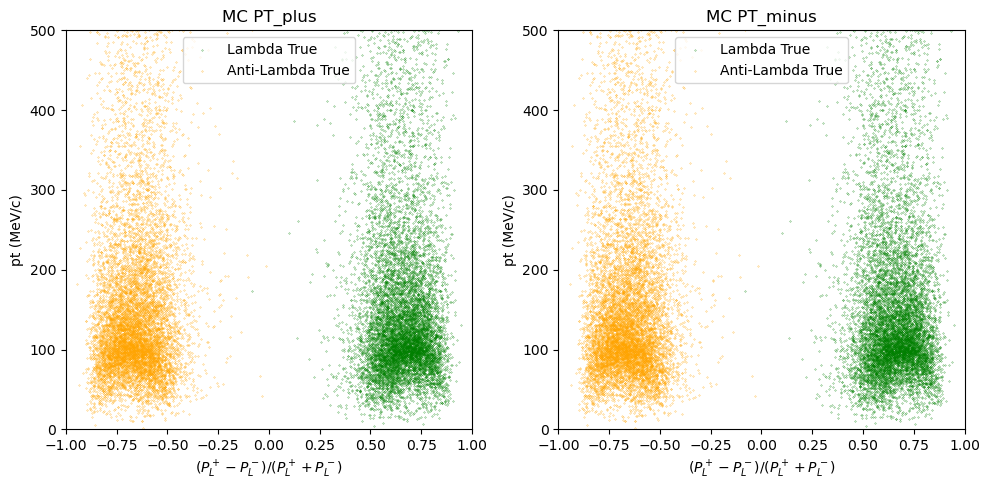

In [103]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 4 filas, 1 columna

# Primer gráfico
axs[0].scatter( mc_signal['alpha'],mc_signal['pT'], c='green', s=0.05, label='Lambda True')
axs[0].scatter( mc_signal['alpha_anti'], mc_signal['pT_anti'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 500)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[0].set_ylabel('pt (MeV/c)')
axs[0].legend()
axs[0].set_title('MC PT_plus')

# Segundo gráfico
axs[1].scatter(mc_signal['alpha_minus'],mc_signal['pT_minus'], c='green', s=0.05, label='Lambda True')
axs[1].scatter(mc_signal['alpha_anti_minus'], mc_signal['pT_anti_minus'], c='orange', s=0.05, label='Anti-Lambda True')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 500)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[1].set_ylabel('pt (MeV/c)')
axs[1].legend()
axs[1].set_title('MC PT_minus')


plt.tight_layout()
plt.show()


In [53]:
# import ROOT
# from ROOT import TVector3, TLorentzVector
# import pandas as pd

# mc_signal1 = mc_data_gen
# mc_signal2 = mc_data_gen

# def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector 
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Convertir TLorentzVector a TVector3
#     pV0 = pV0_4.Vect()
#     pplus = pplus_4.Vect()
#     pminus = pminus_4.Vect()
    
#     # Dirección de vuelo
#     u = pV0.Unit()
    
#     # Calcular alpha
#     pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
#     pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
#     alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
#     # Calcular pT
#     pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
#     pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
#     # pT debería ser el mismo para pTplus y pTminus
#     pT = pTminus
    
#     return alpha, pT

# def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Sumar los cuadrimomentos
#     total_momentum = pplus_4 + pminus_4
    
#     # Calcular la masa invariante
#     invariant_mass = total_momentum.M()
#     invariant_mass_pion = pminus_4.M()
#     invariant_mass_proton = pplus_4.M()
#     invariant_mass_lambda = pV0_4.M()
    
#     return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# # Calcular para partículas
# particle = True
# mc_data_gen['alpha_minus'] = np.nan
# mc_data_gen['alpha_anti_minus'] = np.nan
# mc_data_gen['pT_minus'] = np.nan
# mc_data_gen['pT_anti_minus'] = np.nan


# for index, row in mc_signal1.iterrows():
#     pV0_4 = [row['L_FOURMOMENTUMX'], row['L_FOURMOMENTUMY'], row['L_FOURMOMENTUMZ'], row['L_FOURMOMENTUME']]
#     pplus_4 = [row['p_FOURMOMENTUMX'], row['p_FOURMOMENTUMY'], row['p_FOURMOMENTUMZ'], row['p_FOURMOMENTUME']]
#     pminus_4 = [row['pim_FOURMOMENTUMX'], row['pim_FOURMOMENTUMY'], row['pim_FOURMOMENTUMZ'], row['pim_FOURMOMENTUME']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     mc_data_gen.at[index, 'alpha_minus'] = alpha
#     mc_data_gen.at[index, 'pT_minus'] = pT



# # Calcular para antipartículas
# particle = False
# results = []  # Reinicializar la lista de resultados


# for index, row in mc_signal2.iterrows():
#     pV0_4 = [row['L_FOURMOMENTUMX'], row['L_FOURMOMENTUMY'], row['L_FOURMOMENTUMZ'], row['L_FOURMOMENTUME']]
#     pplus_4 = [row['p_FOURMOMENTUMX'], row['p_FOURMOMENTUMY'], row['p_FOURMOMENTUMZ'], row['p_FOURMOMENTUME']]
#     pminus_4 = [row['pim_FOURMOMENTUMX'], row['pim_FOURMOMENTUMY'], row['pim_FOURMOMENTUMZ'], row['pim_FOURMOMENTUME']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     mc_data_gen.at[index, 'alpha_anti_minus'] = alpha
#     mc_data_gen.at[index, 'pT_anti_minus'] = pT

# # Combinar resultados de partículas y antipartículas
# mc_data_gen['alpha_combined_minus'] = mc_data_gen['alpha_minus'].combine_first(mc_data_gen['alpha_anti_minus'])
# mc_data_gen['pT_combined_minus'] = mc_data_gen['pT_minus'].combine_first(mc_data_gen['pT_anti_minus'])




In [54]:
# import ROOT
# from ROOT import TVector3, TLorentzVector
# import pandas as pd

# mc_signal1 = mc_data_gen
# mc_signal2 = mc_data_gen

# def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector 
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Convertir TLorentzVector a TVector3
#     pV0 = pV0_4.Vect()
#     pplus = pplus_4.Vect()
#     pminus = pminus_4.Vect()
    
#     # Dirección de vuelo
#     u = pV0.Unit()
    
#     # Calcular alpha
#     pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
#     pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
#     alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
#     # Calcular pT
#     pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
#     pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
#     # pT debería ser el mismo para pTplus y pTminus
#     pT = pTplus
    
#     return alpha, pT

# def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Sumar los cuadrimomentos
#     total_momentum = pplus_4 + pminus_4
    
#     # Calcular la masa invariante
#     invariant_mass = total_momentum.M()
#     invariant_mass_pion = pminus_4.M()
#     invariant_mass_proton = pplus_4.M()
#     invariant_mass_lambda = pV0_4.M()
    
#     return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# # Calcular para partículas
# particle = True
# mc_data_gen['alpha'] = np.nan
# mc_data_gen['alpha_anti'] = np.nan
# mc_data_gen['pT'] = np.nan
# mc_data_gen['pT_anti'] = np.nan


# for index, row in mc_signal1.iterrows():
#     pV0_4 = [row['L_FOURMOMENTUMX'], row['L_FOURMOMENTUMY'], row['L_FOURMOMENTUMZ'], row['L_FOURMOMENTUME']]
#     pplus_4 = [row['p_FOURMOMENTUMX'], row['p_FOURMOMENTUMY'], row['p_FOURMOMENTUMZ'], row['p_FOURMOMENTUME']]
#     pminus_4 = [row['pim_FOURMOMENTUMX'], row['pim_FOURMOMENTUMY'], row['pim_FOURMOMENTUMZ'], row['pim_FOURMOMENTUME']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     mc_data_gen.at[index, 'alpha'] = alpha
#     mc_data_gen.at[index, 'pT'] = pT



# # Calcular para antipartículas
# particle = False
# results = []  # Reinicializar la lista de resultados


# for index, row in mc_signal2.iterrows():
#     pV0_4 = [row['L_FOURMOMENTUMX'], row['L_FOURMOMENTUMY'], row['L_FOURMOMENTUMZ'], row['L_FOURMOMENTUME']]
#     pplus_4 = [row['p_FOURMOMENTUMX'], row['p_FOURMOMENTUMY'], row['p_FOURMOMENTUMZ'], row['p_FOURMOMENTUME']]
#     pminus_4 = [row['pim_FOURMOMENTUMX'], row['pim_FOURMOMENTUMY'], row['pim_FOURMOMENTUMZ'], row['pim_FOURMOMENTUME']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     mc_data_gen.at[index, 'alpha_anti'] = alpha
#     mc_data_gen.at[index, 'pT_anti'] = pT

# # Combinar resultados de partículas y antipartículas
# mc_data_gen['alpha_combined'] = mc_data_gen['alpha'].combine_first(mc_data_gen['alpha_anti'])
# mc_data_gen['pT_combined'] = mc_data_gen['pT'].combine_first(mc_data_gen['pT_anti'])




In [55]:
# fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 4 filas, 1 columna

# # Primer gráfico
# axs[0].scatter(mc_data_gen['alpha_combined'], mc_data_gen['pT_combined'] , c='green', s=0.05, label='Lambda True')
# # axs[0].scatter(mc_data_gen['alpha_anti'], mc_data_gen['pT_anti'], armenteros_antiparticle_true2['pT_anti'], c='orange', s=0.05, label='Anti-Lambda True')
# axs[0].set_xlim(-1, 1)
# axs[0].set_ylim(0, 300)
# axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# axs[0].set_ylabel('pt (MeV/c)')
# axs[0].legend()
# axs[0].set_title('MC matched PT_plus')

# # Segundo gráfico
# axs[1].scatter(mc_data_gen['alpha_minus'],mc_data_gen['pT_minus'], c='green', s=0.05, label='Lambda True')
# axs[1].scatter(mc_data_gen['alpha_anti_minus'],mc_data_gen['pT_anti_minus'], c='orange', s=0.05, label='Anti-Lambda True')
# axs[1].set_xlim(-1, 1)
# axs[1].set_ylim(0, 300)
# axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# axs[1].set_ylabel('pt (MeV/c)')
# axs[1].legend()
# axs[1].set_title('MC matched PT_minus')


# plt.tight_layout()
# plt.show()


In [56]:
# fig, axs = plt.subplots()  # 4 filas, 1 columna

# # density = 'True'
# num_bins = 50
# # Plot histograms
# hist1 = plt.hist(mc_signal['pT_TRUE'], bins=22, label='PT (proton)', color='blue', alpha=0.7, histtype='step' )
# hist2 = plt.hist(mc_signal['pT_TRUE_minus'], bins=10, label='PT (pion)', color='red', alpha=0.7, histtype='step')

# # Set labels and legend
# plt.xlabel('pT [MeV/c]')
# plt.ylabel('Entries')
# plt.title('Truth Monte Carlo')
# plt.legend()

# # Display the plot
# plt.show()

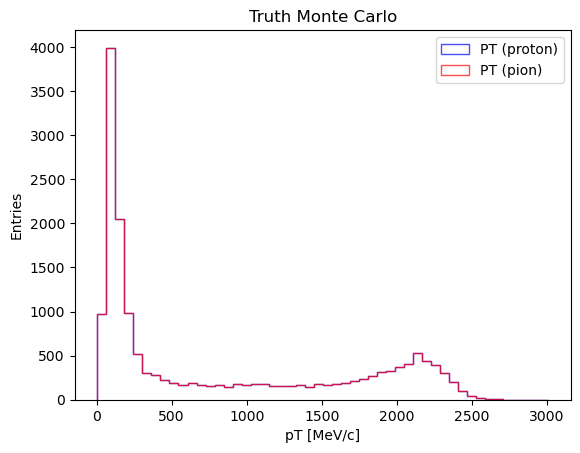

In [104]:
fig, axs = plt.subplots()  # 4 filas, 1 columna

# density = 'True'
num_bins = 50
# Plot histograms
hist1 = plt.hist(mc_signal['pT'], bins=num_bins, label='PT (proton)', color='blue', alpha=0.7, histtype='step' )
hist2 = plt.hist(mc_signal['pT_minus'], bins=num_bins, label='PT (pion)', color='red', alpha=0.7, histtype='step')

# Set labels and legend
plt.xlabel('pT [MeV/c]')
plt.ylabel('Entries')
plt.title('Truth Monte Carlo')
plt.legend()

# Display the plot
plt.show()

In [105]:
# fig, axs = plt.subplots()  # 4 filas, 1 columna

# # density = 'True'
# num_bins = 50
# # Plot histograms
# hist1 = plt.hist( mc_data_gen['pT_combined'], bins=num_bins, label='PT (proton)', color='blue', alpha=0.7, histtype='step' )
# hist2 = plt.hist(mc_data_gen['pT_minus'], bins=num_bins, label='PT (pion)', color='red', alpha=0.7, histtype='step')

# # Set labels and legend
# plt.xlabel('pT [MeV/c]')
# plt.ylabel('Entries')
# plt.title('Truth Monte Carlo')
# plt.legend()

# # Display the plot
# plt.show()

In [106]:
# fig, axs = plt.subplots()  # 4 filas, 1 columna

# # density = 'True'
# num_bins = 50
# # Plot histograms
# hist1 = plt.hist(armenteros_particle_true2['pT'], bins=num_bins, label='PT (proton)', color='blue', alpha=0.7, histtype='step' )
# hist2 = plt.hist(armenteros_particle_true2['pT_minus'], bins=num_bins, label='PT (pion)', color='red', alpha=0.7, histtype='step')

# # Set labels and legend
# plt.xlabel('pT [MeV/c]')
# plt.ylabel('Entries')
# plt.title('Truth Monte Carlo')
# plt.legend()

# # Display the plot
# plt.show()

In [107]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# # Supongamos que tienes un DataFrame llamado mc_signal con las columnas necesarias
# # mc_signal = pd.read_csv('ruta_a_tus_datos.csv')

# # Filtrar datos para eliminar NaNs
# mc_signal = mc_signal.dropna(subset=['alpha_TRUE', 'pT_TRUE', 'alpha_anti_TRUE', 'pT_anti_TRUE'])

# # Configuración del histograma
# bins = 50  # Ajusta el número de bins según tus necesidades

# # Crear un histograma 2D para las partículas Lambda
# hist, xedges, yedges = np.histogram2d(mc_signal['alpha_TRUE'], mc_signal['pT_TRUE'], bins=bins)

# # Crear un histograma 2D para las partículas Anti-Lambda
# hist_anti, xedges_anti, yedges_anti = np.histogram2d(mc_signal['alpha_anti_TRUE'], mc_signal['pT_anti_TRUE'], bins=bins)

# # Crear una figura y un conjunto de subgráficos 3D
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# # Construir las coordenadas para las barras del histograma
# xpos, ypos = np.meshgrid(xedges[:-1] + 0.5 * (xedges[1] - xedges[0]),
#                          yedges[:-1] + 0.5 * (yedges[1] - yedges[0]),
#                          indexing="ij")
# xpos = xpos.ravel()
# ypos = ypos.ravel()
# zpos = 0

# dx = dy = 0.05 * (xedges[1] - xedges[0])  # Ajustar el tamaño de las barras
# dz = hist.ravel()

# # Agregar las barras del histograma para Lambda
# ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color='green', zsort='average', alpha=0.7, label='Lambda True')

# # Construir las coordenadas para las barras del histograma Anti-Lambda
# xpos_anti, ypos_anti = np.meshgrid(xedges_anti[:-1] + 0.5 * (xedges_anti[1] - xedges_anti[0]),
#                                    yedges_anti[:-1] + 0.5 * (yedges_anti[1] - yedges_anti[0]),
#                                    indexing="ij")
# xpos_anti = xpos_anti.ravel()
# ypos_anti = ypos_anti.ravel()
# dz_anti = hist_anti.ravel()

# # Agregar las barras del histograma para Anti-Lambda
# ax.bar3d(xpos_anti, ypos_anti, zpos, dx, dy, dz_anti, color='orange', zsort='average', alpha=0.7, label='Anti-Lambda True')

# # Configuración del gráfico
# ax.set_xlim([-1, 1])
# ax.set_ylim([0, 300])
# ax.set_zlim([0,6000])

# ax.set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# ax.set_ylabel('pt (MeV/c)')
# ax.set_zlabel('Entries')
# ax.legend()
# ax.set_title('True MC PT_plus 3D Histogram')

# # Muestra el gráfico
# plt.show()


In [108]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# # Supongamos que tienes un DataFrame llamado mc_signal con las columnas necesarias
# # mc_signal = pd.read_csv('ruta_a_tus_datos.csv')

# # Filtrar datos para eliminar NaNs
# mc_signal = mc_signal.dropna(subset=['alpha_TRUE', 'pT_TRUE', 'alpha_anti_TRUE', 'pT_anti_TRUE'])

# # Configuración del histograma
# bins = 50  # Ajusta el número de bins según tus necesidades

# # Crear un histograma 2D para las partículas Lambda
# hist, xedges, yedges = np.histogram2d(mc_signal['alpha_TRUE'], mc_signal['pT_TRUE'], bins=bins)

# # Crear un histograma 2D para las partículas Anti-Lambda
# hist_anti, xedges_anti, yedges_anti = np.histogram2d(mc_signal['alpha_anti_TRUE'], mc_signal['pT_anti_TRUE'], bins=bins)

# # Crear una figura y un conjunto de subgráficos 3D
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# # Construir las coordenadas para las barras del histograma Lambda
# xpos, ypos = np.meshgrid(xedges[:-1] + 0.5 * (xedges[1] - xedges[0]),
#                          yedges[:-1] + 0.5 * (yedges[1] - yedges[0]),
#                          indexing="ij")
# xpos = xpos.ravel()
# ypos = ypos.ravel()
# zpos = 0

# dx = dy = 0.05 * (xedges[1] - xedges[0])  # Ajustar el tamaño de las barras
# dz = hist.ravel()

# # Agregar las barras del histograma para Lambda
# ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color='green', zsort='average', alpha=0.7, label='Lambda True')

# # Construir las coordenadas para las barras del histograma Anti-Lambda
# xpos_anti, ypos_anti = np.meshgrid(xedges_anti[:-1] + 0.5 * (xedges_anti[1] - xedges_anti[0]),
#                                    yedges_anti[:-1] + 0.5 * (yedges_anti[1] - yedges_anti[0]),
#                                    indexing="ij")
# xpos_anti = xpos_anti.ravel()
# ypos_anti = ypos_anti.ravel()
# dz_anti = hist_anti.ravel()

# # Agregar las barras del histograma para Anti-Lambda
# ax.bar3d(xpos_anti, ypos_anti, zpos, dx, dy, dz_anti, color='orange', zsort='average', alpha=0.7, label='Anti-Lambda True')

# # Configuración del gráfico
# ax.set_xlim([-1, 1])
# ax.set_ylim([0, 300])
# ax.set_zlim([0, np.max([dz.max(), dz_anti.max()])])

# ax.set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# ax.set_ylabel('pt (MeV/c)')
# ax.set_zlabel('Entries')
# ax.legend()
# ax.set_title('True MC PT_plus 3D Histogram')

# # Muestra el gráfico
# plt.show()


In [109]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# # Supongamos que tienes un DataFrame llamado mc_signal con las columnas necesarias
# # mc_signal = pd.read_csv('ruta_a_tus_datos.csv')

# # Filtrar datos para eliminar NaNs
# mc_signal = mc_signal.dropna(subset=['alpha_TRUE', 'pT_TRUE', 'alpha_anti_TRUE', 'pT_anti_TRUE'])

# # Configuración del histograma
# bins = 50  # Ajusta el número de bins según tus necesidades

# # Crear un histograma 2D para las partículas Lambda
# hist, xedges, yedges = np.histogram2d(mc_signal['alpha_TRUE'], mc_signal['pT_TRUE'], bins=bins)

# # Crear un histograma 2D para las partículas Anti-Lambda
# hist_anti, xedges_anti, yedges_anti = np.histogram2d(mc_signal['alpha_anti_TRUE'], mc_signal['pT_anti_TRUE'], bins=bins)

# # Crear una figura y un conjunto de subgráficos 3D
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# # Construir las coordenadas para las barras del histograma Lambda
# xpos, ypos = np.meshgrid(xedges[:-1] + 0.5 * (xedges[1] - xedges[0]),
#                          yedges[:-1] + 0.5 * (yedges[1] - yedges[0]),
#                          indexing="ij")
# xpos = xpos.ravel()
# ypos = ypos.ravel()
# zpos = np.zeros_like(xpos)

# dx = dy = 0.5 * (xedges[1] - xedges[0])  # Ajustar el tamaño de las barras para mayor visibilidad
# dz = hist.ravel()

# # Agregar las barras del histograma para Lambda
# ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color='green', zsort='average', alpha=0.7, label='Lambda True')

# # Construir las coordenadas para las barras del histograma Anti-Lambda
# xpos_anti, ypos_anti = np.meshgrid(xedges_anti[:-1] + 0.5 * (xedges_anti[1] - xedges_anti[0]),
#                                    yedges_anti[:-1] + 0.5 * (yedges_anti[1] - yedges_anti[0]),
#                                    indexing="ij")
# xpos_anti = xpos_anti.ravel()
# ypos_anti = ypos_anti.ravel()
# dz_anti = hist_anti.ravel()

# # Agregar las barras del histograma para Anti-Lambda
# ax.bar3d(xpos_anti, ypos_anti, zpos, dx, dy, dz_anti, color='orange', zsort='average', alpha=0.7, label='Anti-Lambda True')

# # Configuración del gráfico
# ax.set_xlim([-1, 1])
# ax.set_ylim([0, 300])
# ax.set_zlim([0, max(dz.max(), dz_anti.max())])

# ax.set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# ax.set_ylabel('pt (MeV/c)')
# ax.set_zlabel('Entries')
# ax.legend()
# ax.set_title('True MC PT_plus 3D Histogram')

# # Muestra el gráfico
# plt.show()


In [110]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd
import numpy as np

# Definir la función auxiliar para comparar signos
def compare_signs(row):
    return np.sign(row['p_QOVERP']) == np.sign(row['p_TRUEID']) and (np.sign(row['pim_QOVERP']) == np.sign(row['pim_TRUEID']))

# Filtrar los datos según las nuevas condiciones utilizando apply
mc_signal_filtered = mc_signal[mc_signal.apply(compare_signs, axis=1)]

# Filtrar los datos según las condiciones dadas
mc_signal3 = mc_signal_filtered.query("(p_TRUEID == 2212) & (pim_TRUEID == -211) & (p_MC_GD_MOTHER_ID == 5122) & (pim_MC_GD_MOTHER_ID == 5122) & (p_MC_MOTHER_ID == 3122) & (pim_MC_MOTHER_ID == 3122)")
mc_signal4 = mc_signal_filtered.query("(p_TRUEID == -2212) & (pim_TRUEID == 211) & (p_MC_GD_MOTHER_ID == -5122) & (pim_MC_GD_MOTHER_ID == -5122) & (p_MC_MOTHER_ID == -3122) & (pim_MC_MOTHER_ID == -3122)")

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    pV0_sum4 = pplus_4 + pminus_4
    pV0 = pV0_sum4.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Inicializar las columnas en mc_signal y signal_data_mass
mc_signal['alpha_TRUE_minus'] = np.nan
mc_signal['alpha_anti_TRUE_minus'] = np.nan
mc_signal['pT_TRUE_minus'] = np.nan
mc_signal['pT_anti_TRUE_minus'] = np.nan

signal_data_mass['p_inv_TRUEMASS_part'] = np.nan
signal_data_mass['pim_inv_TRUEMASS_part'] = np.nan
signal_data_mass['L_inv_TRUEMASS_part'] = np.nan

signal_data_mass['p_inv_TRUEMASS_anti'] = np.nan
signal_data_mass['pim_inv_TRUEMASS_anti'] = np.nan
signal_data_mass['L_inv_TRUEMASS_anti'] = np.nan

# Calcular para partículas
particle = True
for index, row in mc_signal3.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
    mc_signal.at[index, 'alpha_TRUE_minus'] = alpha
    mc_signal.at[index, 'pT_TRUE_minus'] = pT
    signal_data_mass.at[index, 'p_inv_TRUEMASS_part'] = mass_p
    signal_data_mass.at[index, 'pim_inv_TRUEMASS_part'] = mass_pion
    signal_data_mass.at[index, 'L_inv_TRUEMASS_part'] = mass_lambda

# Calcular para antipartículas
particle = False
for index, row in mc_signal4.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
    mc_signal.at[index, 'alpha_anti_TRUE_minus'] = alpha
    mc_signal.at[index, 'pT_anti_TRUE_minus'] = pT
    signal_data_mass.at[index, 'p_inv_TRUEMASS_anti'] = mass_p
    signal_data_mass.at[index, 'pim_inv_TRUEMASS_anti'] = mass_pion
    signal_data_mass.at[index, 'L_inv_TRUEMASS_anti'] = mass_lambda

# Combinar resultados de partículas y antipartículas
mc_signal['alpha_combined_TRUE_minus'] = mc_signal['alpha_TRUE_minus'].combine_first(mc_signal['alpha_anti_TRUE_minus'])
mc_signal['pT_combined_TRUE_minus'] = mc_signal['pT_TRUE_minus'].combine_first(mc_signal['pT_anti_TRUE_minus'])
signal_data_mass['p_inv_TRUEMASS'] = signal_data_mass['p_inv_TRUEMASS_part'].combine_first(signal_data_mass['p_inv_TRUEMASS_anti'])
signal_data_mass['pim_inv_TRUEMASS'] = signal_data_mass['pim_inv_TRUEMASS_part'].combine_first(signal_data_mass['pim_inv_TRUEMASS_anti'])
signal_data_mass['L_inv_TRUEMASS'] = signal_data_mass['L_inv_TRUEMASS_part'].combine_first(signal_data_mass['L_inv_TRUEMASS_anti'])

# Mostrar resultados


In [64]:
# fig, axs = plt.subplots(1, 2, figsize=(10, 5))  # 4 filas, 1 columna

# # Primer gráfico
# axs[0].scatter(mc_signal['alpha_TRUE'],mc_signal['pT_TRUE'], c='green', s=0.05, label='Lambda True')
# axs[0].scatter(mc_signal['alpha_anti_TRUE'],mc_signal['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
# axs[0].set_xlim(-1, 1)
# axs[0].set_ylim(0, 300)
# axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# axs[0].set_ylabel('pt (MeV/c)')
# axs[0].legend()
# axs[0].set_title('True MC PT_plus')

# # Segundo gráfico
# axs[1].scatter(mc_signal['alpha_TRUE_minus'],mc_signal['pT_TRUE_minus'], c='green', s=0.05, label='Lambda True')
# axs[1].scatter(mc_signal['alpha_anti_TRUE_minus'],mc_signal['pT_anti_TRUE_minus'], c='orange', s=0.05, label='Anti-Lambda True')
# axs[1].set_xlim(-1, 1)
# axs[1].set_ylim(0, 300)
# axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# axs[1].set_ylabel('pt (MeV/c)')
# axs[1].legend()
# axs[1].set_title('True MC PT_plus, L_P = sum(Pp+Ppim)')


# plt.tight_layout()
# plt.show()


In [65]:
# import ROOT
# from ROOT import TVector3, TLorentzVector
# import pandas as pd

# # Filtrar los datos según las condiciones dadas
# mc_signal3 = mc_data_gen
# mc_signal4 = mc_data_gen
# def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Convertir TLorentzVector a TVector3
#     total_momentum = pplus_4 + pminus_4
#     pV0 = total_momentum.Vect()
#     pplus = pplus_4.Vect()
#     pminus = pminus_4.Vect()
    
#     # Dirección de vuelo
#     u = pV0.Unit()
    
#     # Calcular alpha
#     pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
#     pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
#     alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
#     # Calcular pT
#     pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
#     pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
#     # pT debería ser el mismo para pTplus y pTminus
#     pT = pTplus
    
#     return alpha, pT

# def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
#     # Convertir listas a TLorentzVector si es necesario
#     if isinstance(pV0_4, list):
#         pV0_4 = TLorentzVector(*pV0_4)
#     if isinstance(pplus_4, list):
#         pplus_4 = TLorentzVector(*pplus_4)
#     if isinstance(pminus_4, list):
#         pminus_4 = TLorentzVector(*pminus_4)
    
#     # Sumar los cuadrimomentos
#     total_momentum = pplus_4 + pminus_4
    
#     # Calcular la masa invariante
#     invariant_mass = total_momentum.M()
#     invariant_mass_pion = pminus_4.M()
#     invariant_mass_proton = pplus_4.M()
#     invariant_mass_lambda = pV0_4.M()
    
#     return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# # Calcular para partículas
# particle = True
# results = []
# results_mass = []
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

# for index, row in mc_signal3.iterrows():
#     pV0_4 = [row['L_FOURMOMENTUMX'], row['L_FOURMOMENTUMY'], row['L_FOURMOMENTUMZ'], row['L_FOURMOMENTUME']]
#     pplus_4 = [row['p_FOURMOMENTUMX'], row['p_FOURMOMENTUMY'], row['p_FOURMOMENTUMZ'], row['p_FOURMOMENTUME']]
#     pminus_4 = [row['pim_FOURMOMENTUMX'], row['pim_FOURMOMENTUMY'], row['pim_FOURMOMENTUMZ'], row['pim_FOURMOMENTUME']]

    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     results.append((alpha, pT))
#     results_mass.append(mass)
#     results_mass_p.append(mass_p)
#     results_mass_pion.append(mass_pion)
#     results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
# armenteros_particle_true2 = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# # Calcular para antipartículas
# particle = False
# results = []  # Reinicializar la lista de resultados
# results_mass = []  # Reinicializar la lista de masas
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

# for index, row in mc_signal4.iterrows():
#     pV0_4 = [row['L_FOURMOMENTUMX'], row['L_FOURMOMENTUMY'], row['L_FOURMOMENTUMZ'], row['L_FOURMOMENTUME']]
#     pplus_4 = [row['p_FOURMOMENTUMX'], row['p_FOURMOMENTUMY'], row['p_FOURMOMENTUMZ'], row['p_FOURMOMENTUME']]
#     pminus_4 = [row['pim_FOURMOMENTUMX'], row['pim_FOURMOMENTUMY'], row['pim_FOURMOMENTUMZ'], row['pim_FOURMOMENTUME']]
    
#     alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
#     mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
#     results.append((alpha, pT))
#     results_mass.append(mass)
#     results_mass_p.append(mass_p)
#     results_mass_pion.append(mass_pion)
#     results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
# armenteros_antiparticle_true2 = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# # Mostrar resultados
# print("Partículas:")
# print(armenteros_particle_true)
# print("\nMasa invariante de la Lambda:")
# print(invariant_mass_particle)
# print("\nMasa invariante del Proton:")
# print(invariant_mass_particle_p)
# print("\nMasa invariante del Pion:")
# print(invariant_mass_particle_pion)

# print("\nAntipartículas:")
# print(armenteros_antiparticle_true)
# print("\nMasa invariante de la Anti-Lambda:")
# print(invariant_mass_antiparticle)
# print("\nMasa invariante del Anti-Proton:")
# print(invariant_mass_antiparticle_p)
# print("\nMasa invariante del Anti-Pion:")
# print(invariant_mass_antiparticle_pion)

In [66]:
# fig, axs = plt.subplots()  # 3 filas, 1 columna

# # Primer gráfico
# axs.scatter(armenteros_particle_true2['alpha'], armenteros_particle_true2['pT'], c='green', s=0.05, label='Lambda True')
# axs.scatter(armenteros_antiparticle_true2['alpha'], armenteros_antiparticle_true2['pT'], c='orange', s=0.05, label='Anti-Lambda True')
# axs.set_xlim(-1, 1)
# axs.set_ylim(0, 300)
# axs.set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# axs.set_ylabel('pt (MeV/c)')
# axs.legend()
# axs.set_title('True Monte Carlo')


# plt.tight_layout()
# plt.show()


In [111]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd
import numpy as np

# Definir la función auxiliar para comparar signos
def compare_signs(row):
    return np.sign(row['p_QOVERP']) == np.sign(row['p_TRUEID']) and (np.sign(row['pim_QOVERP']) == np.sign(row['pim_TRUEID']))

# Filtrar los datos según las nuevas condiciones utilizando apply
mc_signal_background_filtered = mc_signal_background[mc_signal_background.apply(compare_signs, axis=1)]
mc_signal_filtered = mc_signal_background_filtered.query('(Jpsi_BKGCAT == 0)')

# # Filtrar los datos según las condiciones dadas
# mc_signal3 = mc_signal_filtered.query("(p_TRUEID == 2212) & (pim_TRUEID == -211) & (p_MC_GD_MOTHER_ID == 5122) & (pim_MC_GD_MOTHER_ID == 5122) & (p_MC_MOTHER_ID == 3122) & (pim_MC_MOTHER_ID == 3122) & (Jpsi_MC_MOTHER_ID == 5122) ")
# mc_signal4 = mc_signal_filtered.query("(p_TRUEID == -2212) & (pim_TRUEID == 211) & (p_MC_GD_MOTHER_ID == -5122) & (pim_MC_GD_MOTHER_ID == -5122) & (p_MC_MOTHER_ID == -3122) & (pim_MC_MOTHER_ID == -3122)& (Jpsi_MC_MOTHER_ID == -5122)")

mc_signal3 = mc_signal_filtered.query("(p_QOVERP > 0)")
mc_signal4 = mc_signal_filtered.query("(p_QOVERP < 0)")

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Inicializar las columnas en mc_signal y signal_data_mass
mc_signal['alpha_TRUE'] = np.nan
mc_signal['alpha_anti_TRUE'] = np.nan
mc_signal['pT_TRUE'] = np.nan
mc_signal['pT_anti_TRUE'] = np.nan

signal_data_mass['p_inv_TRUEMASS_part'] = np.nan
signal_data_mass['pim_inv_TRUEMASS_part'] = np.nan
signal_data_mass['L_inv_TRUEMASS_part'] = np.nan

signal_data_mass['p_inv_TRUEMASS_anti'] = np.nan
signal_data_mass['pim_inv_TRUEMASS_anti'] = np.nan
signal_data_mass['L_inv_TRUEMASS_anti'] = np.nan

# Calcular para partículas
particle = True
for index, row in mc_signal3.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
    mc_signal.at[index, 'alpha_TRUE'] = alpha
    mc_signal.at[index, 'pT_TRUE'] = pT
    signal_data_mass.at[index, 'p_inv_TRUEMASS_part'] = mass_p
    signal_data_mass.at[index, 'pim_inv_TRUEMASS_part'] = mass_pion
    signal_data_mass.at[index, 'L_inv_TRUEMASS_part'] = mass_lambda

# Calcular para antipartículas
particle = False
for index, row in mc_signal4.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
    mc_signal.at[index, 'alpha_anti_TRUE'] = alpha
    mc_signal.at[index, 'pT_anti_TRUE'] = pT
    signal_data_mass.at[index, 'p_inv_TRUEMASS_anti'] = mass_p
    signal_data_mass.at[index, 'pim_inv_TRUEMASS_anti'] = mass_pion
    signal_data_mass.at[index, 'L_inv_TRUEMASS_anti'] = mass_lambda

# Combinar resultados de partículas y antipartículas
mc_signal['alpha_combined_TRUE'] = mc_signal['alpha_TRUE'].combine_first(mc_signal['alpha_anti_TRUE'])
mc_signal['pT_combined_TRUE'] = mc_signal['pT_TRUE'].combine_first(mc_signal['pT_anti_TRUE'])
signal_data_mass['p_inv_TRUEMASS'] = signal_data_mass['p_inv_TRUEMASS_part'].combine_first(signal_data_mass['p_inv_TRUEMASS_anti'])
signal_data_mass['pim_inv_TRUEMASS'] = signal_data_mass['pim_inv_TRUEMASS_part'].combine_first(signal_data_mass['pim_inv_TRUEMASS_anti'])
signal_data_mass['L_inv_TRUEMASS'] = signal_data_mass['L_inv_TRUEMASS_part'].combine_first(signal_data_mass['L_inv_TRUEMASS_anti'])

# Mostrar resultados
print("Resultados combinados de partículas y antipartículas:")
print(mc_signal[['alpha_combined_TRUE', 'pT_combined_TRUE']])


Resultados combinados de partículas y antipartículas:
       alpha_combined_TRUE  pT_combined_TRUE
0                      NaN               NaN
2                      NaN               NaN
3                 0.722349         99.104033
4                 0.762896         92.385248
5                      NaN               NaN
...                    ...               ...
84520            -0.793384        339.354295
84537            -0.851953        395.943271
84560            -0.842131         55.439827
84566            -0.852216         45.720538
84579            -0.811132         75.305255

[56763 rows x 2 columns]


In [112]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd
import numpy as np

# Definir la función auxiliar para comparar signos
def compare_signs(row):
    return np.sign(row['p_QOVERP']) != np.sign(row['p_TRUEID']) and (np.sign(row['pim_QOVERP']) == np.sign(row['pim_TRUEID']))

# Filtrar los datos según las nuevas condiciones utilizando apply
mc_signal_background_filtered = mc_signal_background[mc_signal_background.apply(compare_signs, axis=1)]
mc_signal_filtered = mc_signal_background_filtered.query('(Jpsi_BKGCAT ==0)')

# mc_signal3 = mc_signal_filtered.query("(p_TRUEID == 2212) & (pim_TRUEID == -211) & (p_MC_GD_MOTHER_ID == 5122) & (pim_MC_GD_MOTHER_ID == 5122) & (p_MC_MOTHER_ID == 3122) & (pim_MC_MOTHER_ID == 3122)& (Jpsi_MC_MOTHER_ID == 5122)")
# mc_signal4 = mc_signal_filtered.query("(p_TRUEID == -2212) & (pim_TRUEID == 211) & (p_MC_GD_MOTHER_ID == -5122) & (pim_MC_GD_MOTHER_ID == -5122) & (p_MC_MOTHER_ID == -3122) & (pim_MC_MOTHER_ID == -3122)& (Jpsi_MC_MOTHER_ID == -5122)")

# Filtrar los datos según las condiciones dadas
mc_signal3 = mc_signal_filtered.query("(p_QOVERP > 0)")
mc_signal4 = mc_signal_filtered.query("(p_QOVERP < 0)")

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Inicializar las columnas en mc_signal y signal_data_mass
mc_signal['alpha_TRUE2'] = np.nan
mc_signal['alpha_anti_TRUE2'] = np.nan
mc_signal['pT_TRUE2'] = np.nan
mc_signal['pT_anti_TRUE2'] = np.nan

signal_data_mass['p_inv_TRUEMASS_part'] = np.nan
signal_data_mass['pim_inv_TRUEMASS_part'] = np.nan
signal_data_mass['L_inv_TRUEMASS_part'] = np.nan

signal_data_mass['p_inv_TRUEMASS_anti'] = np.nan
signal_data_mass['pim_inv_TRUEMASS_anti'] = np.nan
signal_data_mass['L_inv_TRUEMASS_anti'] = np.nan

# Calcular para partículas
particle = True
for index, row in mc_signal3.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
    mc_signal.at[index, 'alpha_TRUE2'] = alpha
    mc_signal.at[index, 'pT_TRUE2'] = pT
    signal_data_mass.at[index, 'p_inv_TRUEMASS_part'] = mass_p
    signal_data_mass.at[index, 'pim_inv_TRUEMASS_part'] = mass_pion
    signal_data_mass.at[index, 'L_inv_TRUEMASS_part'] = mass_lambda

# Calcular para antipartículas
particle = False
for index, row in mc_signal4.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
    mc_signal.at[index, 'alpha_anti_TRUE2'] = alpha
    mc_signal.at[index, 'pT_anti_TRUE2'] = pT
    signal_data_mass.at[index, 'p_inv_TRUEMASS_anti'] = mass_p
    signal_data_mass.at[index, 'pim_inv_TRUEMASS_anti'] = mass_pion
    signal_data_mass.at[index, 'L_inv_TRUEMASS_anti'] = mass_lambda

# Combinar resultados de partículas y antipartículas
mc_signal['alpha_combined_TRUE2'] = mc_signal['alpha_TRUE2'].combine_first(mc_signal['alpha_anti_TRUE2'])
mc_signal['pT_combined_TRUE2'] = mc_signal['pT_TRUE2'].combine_first(mc_signal['pT_anti_TRUE2'])
signal_data_mass['p_inv_TRUEMASS'] = signal_data_mass['p_inv_TRUEMASS_part'].combine_first(signal_data_mass['p_inv_TRUEMASS_anti'])
signal_data_mass['pim_inv_TRUEMASS'] = signal_data_mass['pim_inv_TRUEMASS_part'].combine_first(signal_data_mass['pim_inv_TRUEMASS_anti'])
signal_data_mass['L_inv_TRUEMASS'] = signal_data_mass['L_inv_TRUEMASS_part'].combine_first(signal_data_mass['L_inv_TRUEMASS_anti'])

# Mostrar resultados
print("Resultados combinados de partículas y antipartículas:")
print(mc_signal[['alpha_combined_TRUE2', 'pT_combined_TRUE2']])


Resultados combinados de partículas y antipartículas:
       alpha_combined_TRUE2  pT_combined_TRUE2
0                       NaN                NaN
2                       NaN                NaN
3                       NaN                NaN
4                       NaN                NaN
5                       NaN                NaN
...                     ...                ...
84277                   NaN                NaN
84291                   NaN                NaN
84295                   NaN                NaN
84357                   NaN                NaN
84393                   NaN                NaN

[57770 rows x 2 columns]


In [113]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd
import numpy as np

# Definir la función auxiliar para comparar signos
def compare_signs(row):
    return np.sign(row['p_QOVERP']) == np.sign(row['p_TRUEID']) and (np.sign(row['pim_QOVERP']) != np.sign(row['pim_TRUEID']))

# Filtrar los datos según las nuevas condiciones utilizando apply
mc_signal_background_filtered = mc_signal_background[mc_signal_background.apply(compare_signs, axis=1)]
mc_signal_filtered = mc_signal_background_filtered.query('(Jpsi_BKGCAT ==0)')

# mc_signal3 = mc_signal_filtered.query("(p_TRUEID == 2212) & (pim_TRUEID == -211) & (p_MC_GD_MOTHER_ID == 5122) & (pim_MC_GD_MOTHER_ID == 5122) & (p_MC_MOTHER_ID == 3122) & (pim_MC_MOTHER_ID == 3122)& (Jpsi_MC_MOTHER_ID == 5122)")
# mc_signal4 = mc_signal_filtered.query("(p_TRUEID == -2212) & (pim_TRUEID == 211) & (p_MC_GD_MOTHER_ID == -5122) & (pim_MC_GD_MOTHER_ID == -5122) & (p_MC_MOTHER_ID == -3122) & (pim_MC_MOTHER_ID == -3122)& (Jpsi_MC_MOTHER_ID == -5122)")

# Filtrar los datos según las condiciones dadas
mc_signal3 = mc_signal_filtered.query("(p_QOVERP > 0)")
mc_signal4 = mc_signal_filtered.query("(p_QOVERP < 0)")

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Inicializar las columnas en mc_signal y signal_data_mass
mc_signal['alpha_TRUE3'] = np.nan
mc_signal['alpha_anti_TRUE3'] = np.nan
mc_signal['pT_TRUE3'] = np.nan
mc_signal['pT_anti_TRUE3'] = np.nan

signal_data_mass['p_inv_TRUEMASS_part'] = np.nan
signal_data_mass['pim_inv_TRUEMASS_part'] = np.nan
signal_data_mass['L_inv_TRUEMASS_part'] = np.nan

signal_data_mass['p_inv_TRUEMASS_anti'] = np.nan
signal_data_mass['pim_inv_TRUEMASS_anti'] = np.nan
signal_data_mass['L_inv_TRUEMASS_anti'] = np.nan

# Calcular para partículas
particle = True
for index, row in mc_signal3.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
    mc_signal.at[index, 'alpha_TRUE3'] = alpha
    mc_signal.at[index, 'pT_TRUE3'] = pT
    signal_data_mass.at[index, 'p_inv_TRUEMASS_part'] = mass_p
    signal_data_mass.at[index, 'pim_inv_TRUEMASS_part'] = mass_pion
    signal_data_mass.at[index, 'L_inv_TRUEMASS_part'] = mass_lambda

# Calcular para antipartículas
particle = False
for index, row in mc_signal4.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
    mc_signal.at[index, 'alpha_anti_TRUE3'] = alpha
    mc_signal.at[index, 'pT_anti_TRUE3'] = pT
    signal_data_mass.at[index, 'p_inv_TRUEMASS_anti'] = mass_p
    signal_data_mass.at[index, 'pim_inv_TRUEMASS_anti'] = mass_pion
    signal_data_mass.at[index, 'L_inv_TRUEMASS_anti'] = mass_lambda

# Combinar resultados de partículas y antipartículas
mc_signal['alpha_combined_TRUE3'] = mc_signal['alpha_TRUE3'].combine_first(mc_signal['alpha_anti_TRUE3'])
mc_signal['pT_combined_TRUE3'] = mc_signal['pT_TRUE3'].combine_first(mc_signal['pT_anti_TRUE3'])
signal_data_mass['p_inv_TRUEMASS'] = signal_data_mass['p_inv_TRUEMASS_part'].combine_first(signal_data_mass['p_inv_TRUEMASS_anti'])
signal_data_mass['pim_inv_TRUEMASS'] = signal_data_mass['pim_inv_TRUEMASS_part'].combine_first(signal_data_mass['pim_inv_TRUEMASS_anti'])
signal_data_mass['L_inv_TRUEMASS'] = signal_data_mass['L_inv_TRUEMASS_part'].combine_first(signal_data_mass['L_inv_TRUEMASS_anti'])

# Mostrar resultados
print("Resultados combinados de partículas y antipartículas:")
print(mc_signal[['alpha_combined_TRUE3', 'pT_combined_TRUE3']])


Resultados combinados de partículas y antipartículas:
       alpha_combined_TRUE3  pT_combined_TRUE3
0                       NaN                NaN
2                       NaN                NaN
3                       NaN                NaN
4                       NaN                NaN
5                       NaN                NaN
...                     ...                ...
84419                   NaN                NaN
84459             -0.683721         127.211863
84460                   NaN                NaN
84523                   NaN                NaN
84569             -0.763602         179.710616

[60017 rows x 2 columns]


In [114]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd
import numpy as np

# Definir la función auxiliar para comparar signos
def compare_signs(row):
    return np.sign(row['p_QOVERP']) != np.sign(row['p_TRUEID']) and (np.sign(row['pim_QOVERP']) != np.sign(row['pim_TRUEID']))

# Filtrar los datos según las nuevas condiciones utilizando apply
mc_signal_background_filtered = mc_signal_background[mc_signal_background.apply(compare_signs, axis=1)]
mc_signal_filtered = mc_signal_background_filtered.query('(Jpsi_BKGCAT ==0)')

# mc_signal3 = mc_signal_filtered.query("(p_TRUEID == 2212) & (pim_TRUEID == -211) & (p_MC_GD_MOTHER_ID == 5122) & (pim_MC_GD_MOTHER_ID == 5122) & (p_MC_MOTHER_ID == 3122) & (pim_MC_MOTHER_ID == 3122)& (Jpsi_MC_MOTHER_ID == 5122)")
# mc_signal4 = mc_signal_filtered.query("(p_TRUEID == -2212) & (pim_TRUEID == 211) & (p_MC_GD_MOTHER_ID == -5122) & (pim_MC_GD_MOTHER_ID == -5122) & (p_MC_MOTHER_ID == -3122) & (pim_MC_MOTHER_ID == -3122)& (Jpsi_MC_MOTHER_ID == -5122)")

# Filtrar los datos según las condiciones dadas
mc_signal3 = mc_signal_filtered.query("(p_QOVERP > 0)")
mc_signal4 = mc_signal_filtered.query("(p_QOVERP < 0)")

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    total_momentum = pplus_4 + pminus_4
    pV0 = total_momentum.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Inicializar las columnas en mc_signal y signal_data_mass
mc_signal['alpha_TRUE4'] = np.nan
mc_signal['alpha_anti_TRUE4'] = np.nan
mc_signal['pT_TRUE4'] = np.nan
mc_signal['pT_anti_TRUE4'] = np.nan

signal_data_mass['p_inv_TRUEMASS_part'] = np.nan
signal_data_mass['pim_inv_TRUEMASS_part'] = np.nan
signal_data_mass['L_inv_TRUEMASS_part'] = np.nan

signal_data_mass['p_inv_TRUEMASS_anti'] = np.nan
signal_data_mass['pim_inv_TRUEMASS_anti'] = np.nan
signal_data_mass['L_inv_TRUEMASS_anti'] = np.nan

# Calcular para partículas
particle = True
for index, row in mc_signal3.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
    mc_signal.at[index, 'alpha_TRUE4'] = alpha
    mc_signal.at[index, 'pT_TRUE4'] = pT
    signal_data_mass.at[index, 'p_inv_TRUEMASS_part'] = mass_p
    signal_data_mass.at[index, 'pim_inv_TRUEMASS_part'] = mass_pion
    signal_data_mass.at[index, 'L_inv_TRUEMASS_part'] = mass_lambda

# Calcular para antipartículas
particle = False
for index, row in mc_signal4.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    
    mc_signal.at[index, 'alpha_anti_TRUE4'] = alpha
    mc_signal.at[index, 'pT_anti_TRUE4'] = pT
    signal_data_mass.at[index, 'p_inv_TRUEMASS_anti'] = mass_p
    signal_data_mass.at[index, 'pim_inv_TRUEMASS_anti'] = mass_pion
    signal_data_mass.at[index, 'L_inv_TRUEMASS_anti'] = mass_lambda

# Combinar resultados de partículas y antipartículas
mc_signal['alpha_combined_TRUE4'] = mc_signal['alpha_TRUE4'].combine_first(mc_signal['alpha_anti_TRUE4'])
mc_signal['pT_combined_TRUE4'] = mc_signal['pT_TRUE4'].combine_first(mc_signal['pT_anti_TRUE4'])
signal_data_mass['p_inv_TRUEMASS'] = signal_data_mass['p_inv_TRUEMASS_part'].combine_first(signal_data_mass['p_inv_TRUEMASS_anti'])
signal_data_mass['pim_inv_TRUEMASS'] = signal_data_mass['pim_inv_TRUEMASS_part'].combine_first(signal_data_mass['pim_inv_TRUEMASS_anti'])
signal_data_mass['L_inv_TRUEMASS'] = signal_data_mass['L_inv_TRUEMASS_part'].combine_first(signal_data_mass['L_inv_TRUEMASS_anti'])

# Mostrar resultados
print("Resultados combinados de partículas y antipartículas:")
print(mc_signal[['alpha_combined_TRUE4', 'pT_combined_TRUE4']])


Resultados combinados de partículas y antipartículas:
       alpha_combined_TRUE4  pT_combined_TRUE4
0                 -0.784126           0.613654
2                       NaN                NaN
3                       NaN                NaN
4                       NaN                NaN
5                       NaN                NaN
...                     ...                ...
84470                   NaN                NaN
84514                   NaN                NaN
84524                   NaN                NaN
84564                   NaN                NaN
84574                   NaN                NaN

[61508 rows x 2 columns]


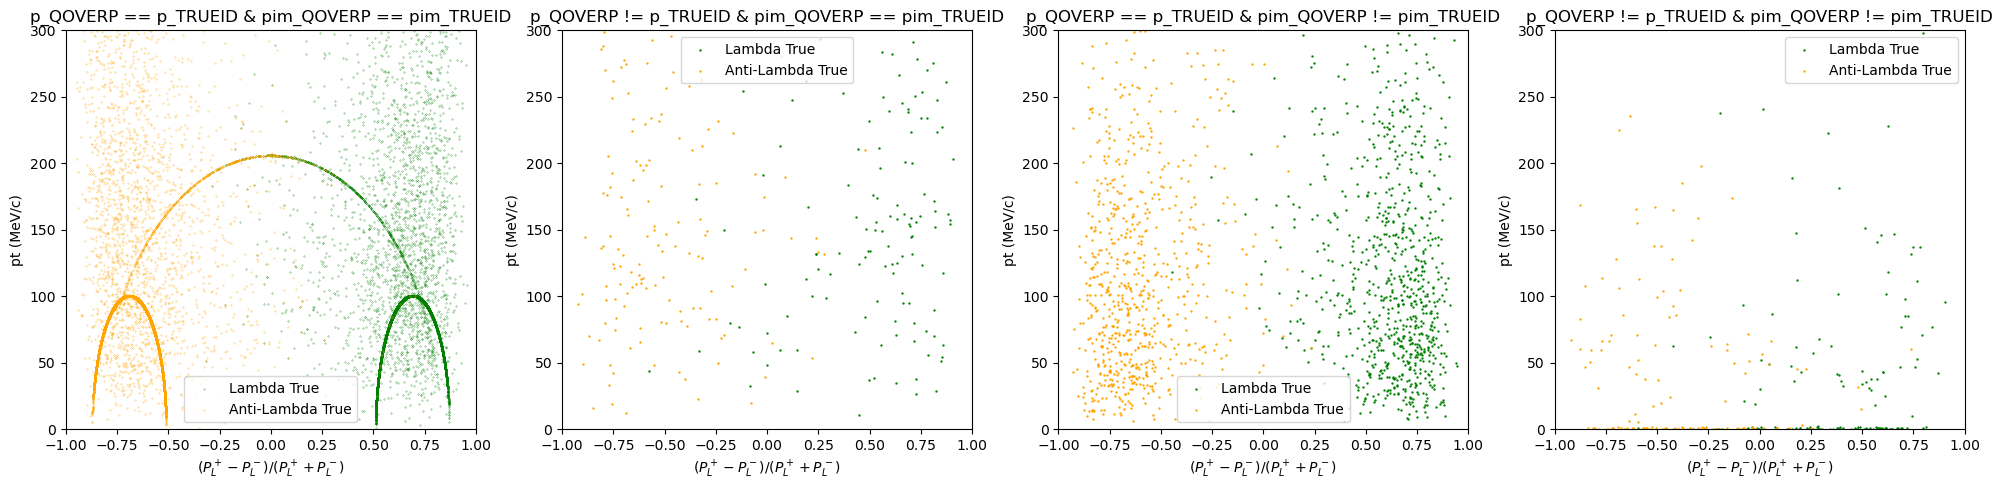

In [115]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))  # 4 filas, 1 columna

# Primer gráfico
axs[0].scatter(mc_signal['alpha_TRUE'],mc_signal['pT_TRUE'], c='green', s=0.05, label='Lambda True')
axs[0].scatter(mc_signal['alpha_anti_TRUE'],mc_signal['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 300)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[0].set_ylabel('pt (MeV/c)')
axs[0].legend()
axs[0].set_title('p_QOVERP == p_TRUEID & pim_QOVERP == pim_TRUEID')

# Segundo gráfico
axs[1].scatter(mc_signal['alpha_TRUE2'],mc_signal['pT_TRUE2'], c='green', s=0.5, label='Lambda True')
axs[1].scatter(mc_signal['alpha_anti_TRUE2'],mc_signal['pT_anti_TRUE2'], c='orange', s=0.5, label='Anti-Lambda True')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 300)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[1].set_ylabel('pt (MeV/c)')
axs[1].legend()
axs[1].set_title('p_QOVERP != p_TRUEID & pim_QOVERP == pim_TRUEID')


# Tercer gráfico
axs[2].scatter(mc_signal['alpha_TRUE3'],mc_signal['pT_TRUE3'], c='green', s=0.5, label='Lambda True')
axs[2].scatter(mc_signal['alpha_anti_TRUE3'],mc_signal['pT_anti_TRUE3'], c='orange', s=0.5, label='Anti-Lambda True')
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 300)
axs[2].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[2].set_ylabel('pt (MeV/c)')
axs[2].legend()
axs[2].set_title('p_QOVERP == p_TRUEID & pim_QOVERP != pim_TRUEID')

# Cuarto gráfico
axs[3].scatter(mc_signal['alpha_TRUE4'],mc_signal['pT_TRUE4'], c='green', s=0.5, label='Lambda True')
axs[3].scatter(mc_signal['alpha_anti_TRUE4'],mc_signal['pT_anti_TRUE4'], c='orange', s=0.5, label='Anti-Lambda True')
axs[3].set_xlim(-1, 1)
axs[3].set_ylim(0, 300)
axs[3].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[3].set_ylabel('pt (MeV/c)')
axs[3].legend()
axs[3].set_title('p_QOVERP != p_TRUEID & pim_QOVERP != pim_TRUEID')

plt.tight_layout()
plt.show()


In [116]:
# Definir la función auxiliar para comparar signos
def compare_signs(row):
    return np.sign(row['p_QOVERP']) == np.sign(row['p_TRUEID']) and (np.sign(row['pim_QOVERP']) == np.sign(row['pim_TRUEID']))

# Filtrar los datos según las nuevas condiciones utilizando apply
mc_signal_background_filtered = mc_signal_background[mc_signal_background.apply(compare_signs, axis=1)]
mc_signal_filtered = mc_signal_background_filtered.query('(Jpsi_BKGCAT ==0)')


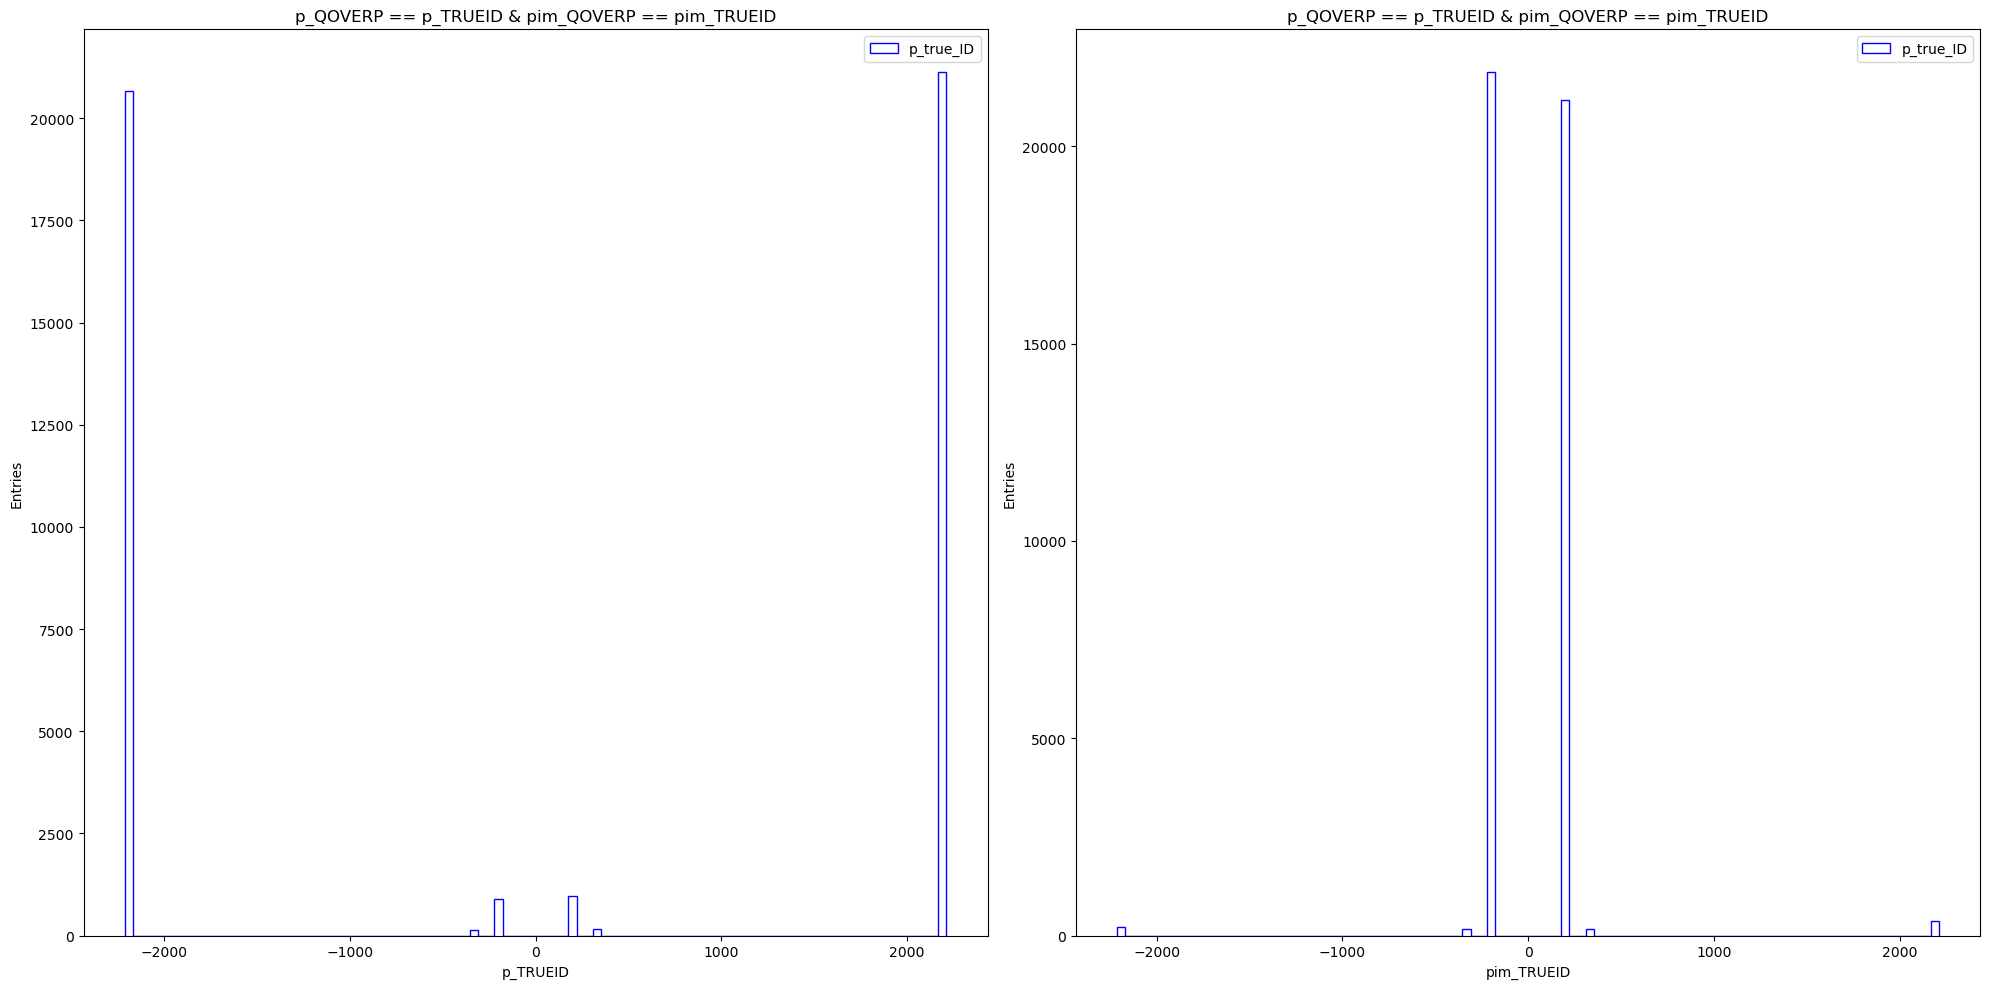

In [117]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # 4 filas, 1 columna

# Primer gráfico
axs[0].hist(mc_signal_filtered['p_TRUEID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[0].scatter(mc_signal_filtered['alpha_anti_TRUE'],mc_signal_filtered['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlabel('p_TRUEID')
axs[0].set_ylabel('Entries')
axs[0].legend()
axs[0].set_title('p_QOVERP == p_TRUEID & pim_QOVERP == pim_TRUEID')

# Segundo gráfico
axs[1].hist(mc_signal_filtered['pim_TRUEID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[1].scatter(mc_signal_filtered['alpha_anti_TRUE2'],mc_signal_filtered['pT_anti_TRUE2'], c='orange', s=0.5, label='Anti-Lambda True')

axs[1].set_xlabel('pim_TRUEID')
axs[1].set_ylabel('Entries')
axs[1].legend()
axs[1].set_title('p_QOVERP == p_TRUEID & pim_QOVERP == pim_TRUEID')


# # Tercer gráfico
# axs[2].scatter(mc_signal_filtered['p'],mc_signal_filtered['pT_TRUE3'], c='green', s=0.5, label='Lambda True')
# axs[2].scatter(mc_signal_filtered['alpha_anti_TRUE3'],mc_signal_filtered['pT_anti_TRUE3'], c='orange', s=0.5, label='Anti-Lambda True')
# axs[2].set_xlim(-1, 1)
# axs[2].set_ylim(0, 300)
# axs[2].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# axs[2].set_ylabel('pt (MeV/c)')
# axs[2].legend()
# axs[2].set_title('p_QOVERP == p_TRUEID & pim_QOVERP != pim_TRUEID')

# # Cuarto gráfico
# axs[3].scatter(mc_signal['alpha_TRUE4'],mc_signal['pT_TRUE4'], c='green', s=0.5, label='Lambda True')
# axs[3].scatter(mc_signal['alpha_anti_TRUE4'],mc_signal['pT_anti_TRUE4'], c='orange', s=0.5, label='Anti-Lambda True')
# axs[3].set_xlim(-1, 1)
# axs[3].set_ylim(0, 300)
# axs[3].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
# axs[3].set_ylabel('pt (MeV/c)')
# axs[3].legend()
# axs[3].set_title('p_QOVERP != p_TRUEID & pim_QOVERP != pim_TRUEID')

plt.tight_layout()
plt.show()


In [118]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered['p_TRUEID'].value_counts(normalize='True')*100

print(conteo)

p_TRUEID
 2212    48.039126
-2212    47.008644
 211      2.217925
-211      2.060965
 321      0.359418
-321      0.311647
-11       0.002275
Name: proportion, dtype: float64


In [119]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered['pim_TRUEID'].value_counts(normalize='True')*100
print(conteo)


pim_TRUEID
-211     49.756597
 211     48.164240
 2212     0.837125
-2212     0.477707
 321      0.382166
-321      0.382166
Name: proportion, dtype: float64


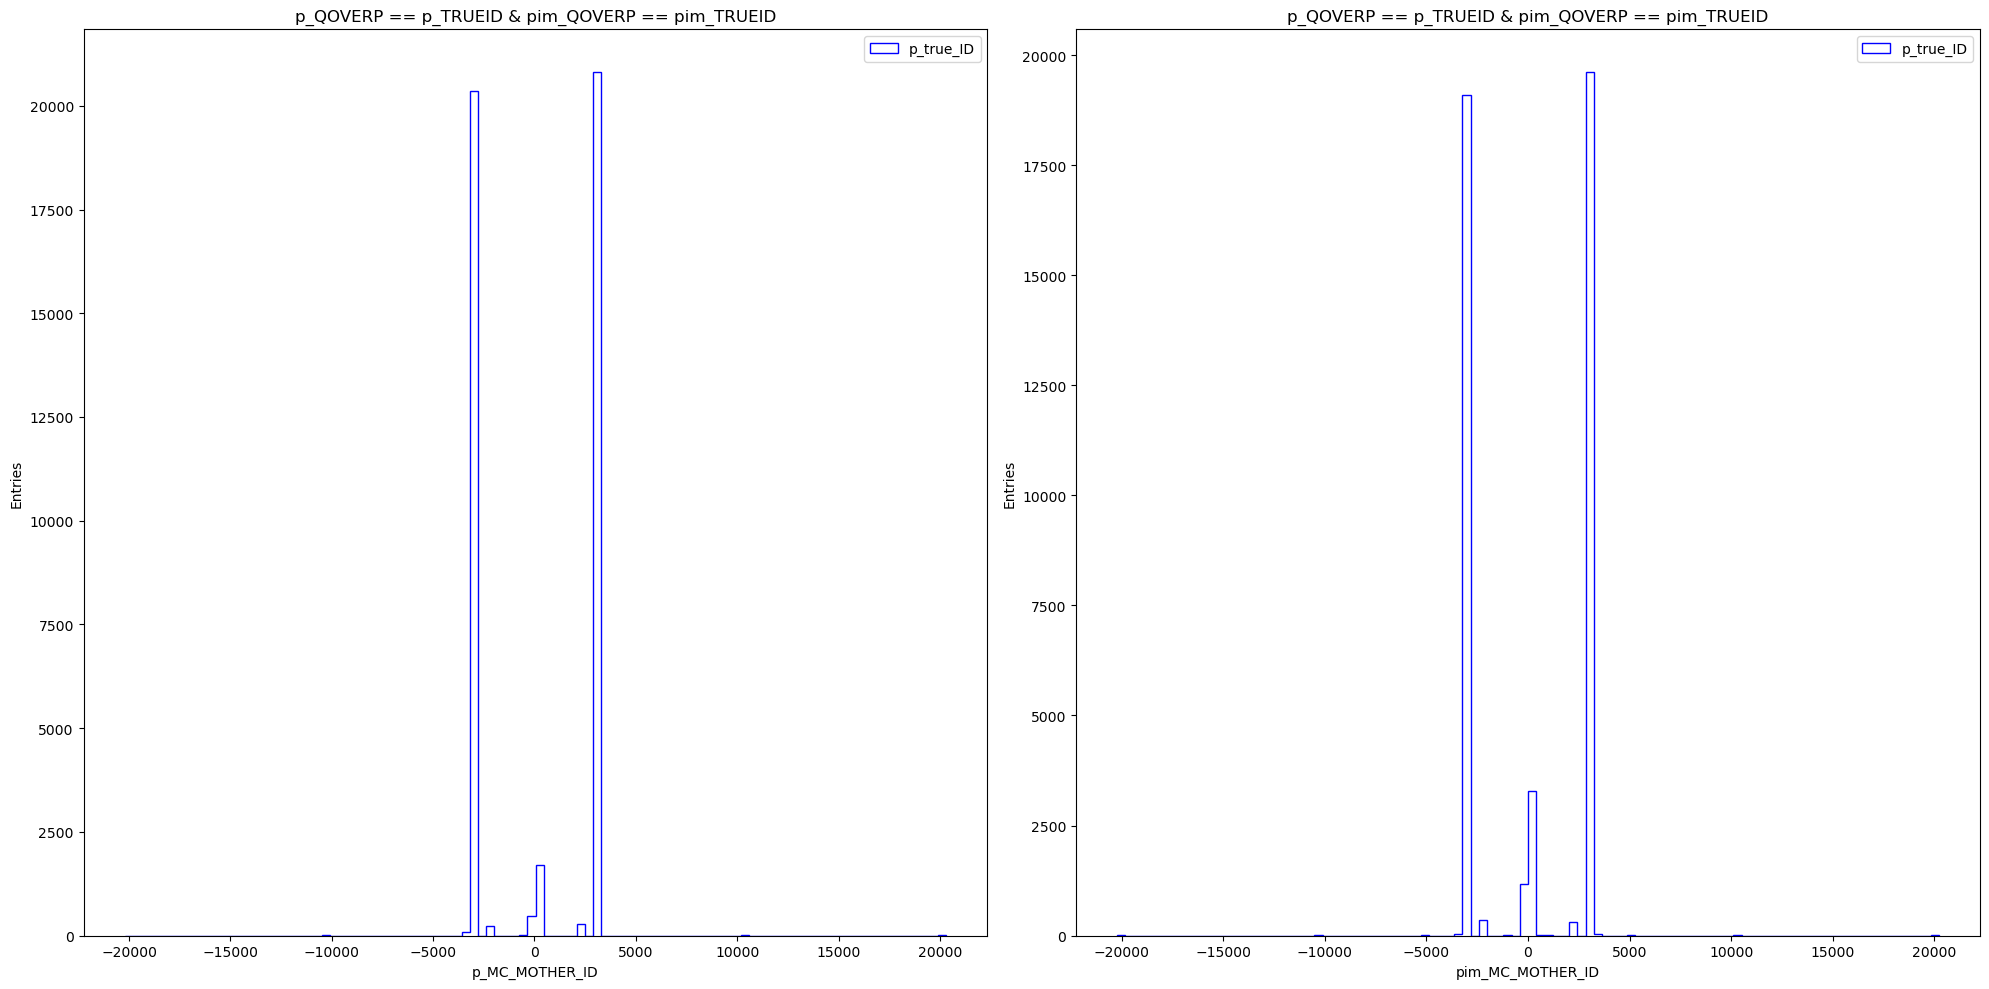

In [120]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # 4 filas, 1 columna

# Primer gráfico
axs[0].hist(mc_signal_filtered['p_MC_MOTHER_ID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[0].scatter(mc_signal_filtered['alpha_anti_TRUE'],mc_signal_filtered['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlabel('p_MC_MOTHER_ID')
axs[0].set_ylabel('Entries')
axs[0].legend()
axs[0].set_title('p_QOVERP == p_TRUEID & pim_QOVERP == pim_TRUEID')

# Segundo gráfico
axs[1].hist(mc_signal_filtered['pim_MC_MOTHER_ID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[1].scatter(mc_signal_filtered['alpha_anti_TRUE2'],mc_signal_filtered['pT_anti_TRUE2'], c='orange', s=0.5, label='Anti-Lambda True')

axs[1].set_xlabel('pim_MC_MOTHER_ID')
axs[1].set_ylabel('Entries')
axs[1].legend()
axs[1].set_title('p_QOVERP == p_TRUEID & pim_QOVERP == pim_TRUEID')

plt.tight_layout()
plt.show()


In [121]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered['p_MC_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)

p_MC_MOTHER_ID
 3122     47.161056
-3122     46.273885
 310       3.084622
 0         0.489081
 2212      0.439035
-2212      0.304823
 211       0.300273
-211       0.282075
-3222      0.184258
 3222      0.154686
-2112      0.136488
 2112      0.120564
 321       0.120564
-321       0.111465
 113       0.106915
 130       0.077343
 213       0.050045
-2224      0.050045
-213       0.047771
 313       0.040946
-5         0.038672
 2214      0.034122
-313       0.034122
 2224      0.029572
 223       0.027298
-4         0.025023
-2214      0.025023
 5         0.025023
-2114      0.022748
 323       0.022748
 221       0.020473
-323       0.015924
 333       0.015924
 2114      0.011374
 215       0.009099
 421       0.009099
-10323     0.009099
-3112      0.009099
-3312      0.006824
-215       0.004550
 10213     0.004550
 225       0.004550
 10223     0.004550
 4         0.004550
-315       0.004550
 3114      0.004550
 10323     0.002275
 335       0.002275
-20213     0.002275
-411 

In [122]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered['pim_MC_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)


pim_MC_MOTHER_ID
 3122     44.483621
-3122     43.346224
 310       4.019563
 211       1.926752
-211       1.858508
-321       0.441310
-2212      0.402639
 2212      0.379891
-2112      0.366242
 130       0.354868
 321       0.338944
 2112      0.313922
 113       0.275250
 0         0.211556
 221       0.175159
 223       0.172884
 3312      0.104641
 213       0.065969
-3312      0.063694
 3112      0.063694
-213       0.054595
-3112      0.054595
 331       0.054595
 3222      0.050045
-3222      0.045496
-323       0.043221
-313       0.029572
 313       0.027298
 20223     0.018198
-10213     0.018198
 323       0.015924
-2224      0.015924
 215       0.013649
 2224      0.013649
-5         0.011374
-1114      0.011374
 5         0.009099
 333       0.009099
 1114      0.009099
-2214      0.009099
-3322      0.006824
 10313     0.006824
 225       0.006824
 2214      0.006824
-2114      0.006824
 115       0.006824
-4         0.004550
-20213     0.004550
 4         0.004550
-10

In [123]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered['p_MC_GD_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)

p_MC_GD_MOTHER_ID
 5122     40.584622
-5122     39.924932
 0         5.448135
-311       1.424022
 3212      1.424022
 311       1.369427
-3212      1.339854
-3122      0.582348
 3312      0.566424
-3322      0.509554
 3214      0.505005
 3322      0.505005
 3122      0.502730
 3224      0.477707
-3312      0.473157
-3214      0.461783
 3114      0.441310
-3114      0.436761
-3224      0.414013
-5         0.354868
 5         0.288899
-4         0.150136
 4         0.141037
 113       0.106915
-421       0.086442
 4122      0.084167
 421       0.081893
 333       0.070519
-4122      0.059145
 213       0.054595
-211       0.050045
 2224      0.047771
-2212      0.045496
 2214      0.043221
-213       0.043221
 313       0.038672
 2212      0.038672
 223       0.036397
-2112      0.036397
 130       0.036397
 211       0.034122
-1114      0.034122
 310       0.031847
-2214      0.029572
 411       0.029572
-2224      0.029572
 2112      0.027298
-313       0.025023
 323       0.025023
 2

In [124]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered['pim_MC_GD_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)

pim_MC_GD_MOTHER_ID
 5122       38.673794
-5122       37.834395
 0           5.809827
-311         1.849409
 311         1.815287
 3212        1.269336
-3212        1.166970
 113         0.539126
-3122        0.532302
 223         0.477707
 3322        0.475432
 3214        0.464058
-3322        0.439035
 3224        0.420837
 3122        0.416288
 3312        0.416288
-3312        0.411738
-3214        0.400364
 3114        0.375341
-5           0.373066
-3224        0.368517
-3114        0.363967
 5           0.329845
 213         0.291174
 211         0.270701
-213         0.254777
 310         0.225205
-211         0.220655
 331         0.200182
 4           0.184258
-4           0.179709
-313         0.163785
 333         0.118289
-323         0.116015
 313         0.116015
-1114        0.106915
 130         0.104641
 221         0.100091
 2212        0.097816
 323         0.095541
-2212        0.093267
 421         0.088717
-2112        0.086442
-321         0.084167
 2224       

In [125]:
# Definir la función auxiliar para comparar signos
def compare_signs(row):
    return np.sign(row['p_QOVERP']) != np.sign(row['p_TRUEID']) and (np.sign(row['pim_QOVERP']) == np.sign(row['pim_TRUEID']))

# Filtrar los datos según las nuevas condiciones utilizando apply
mc_signal_background_filtered2 = mc_signal_background[mc_signal_background.apply(compare_signs, axis=1)]
mc_signal_filtered2 = mc_signal_background_filtered2.query('(Jpsi_BKGCAT ==0)')


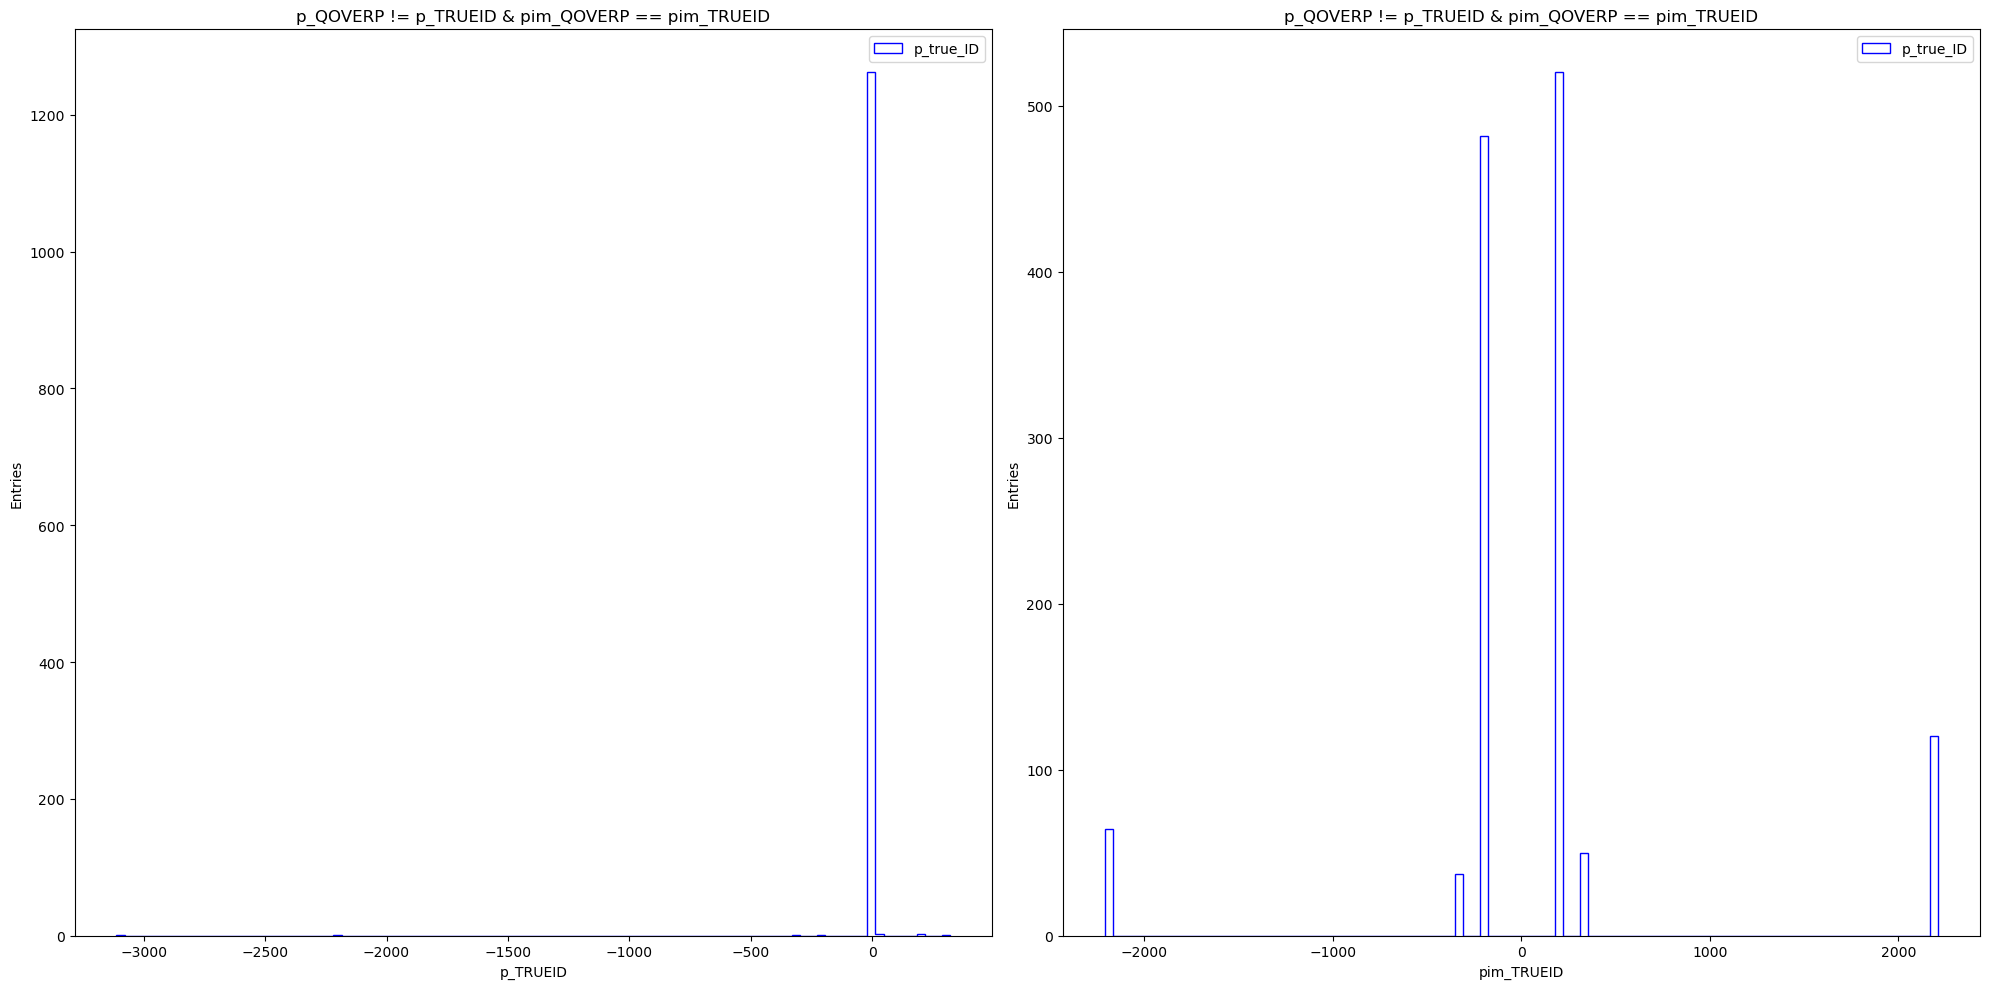

In [126]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # 4 filas, 1 columna

# Primer gráfico
axs[0].hist(mc_signal_filtered2['p_TRUEID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[0].scatter(mc_signal_filtered['alpha_anti_TRUE'],mc_signal_filtered['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlabel('p_TRUEID')
axs[0].set_ylabel('Entries')
axs[0].legend()
axs[0].set_title('p_QOVERP != p_TRUEID & pim_QOVERP == pim_TRUEID')

# Segundo gráfico
axs[1].hist(mc_signal_filtered2['pim_TRUEID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[1].scatter(mc_signal_filtered['alpha_anti_TRUE2'],mc_signal_filtered['pT_anti_TRUE2'], c='orange', s=0.5, label='Anti-Lambda True')

axs[1].set_xlabel('pim_TRUEID')
axs[1].set_ylabel('Entries')
axs[1].legend()
axs[1].set_title('p_QOVERP != p_TRUEID & pim_QOVERP == pim_TRUEID')

plt.tight_layout()
plt.show()


In [127]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered2['p_TRUEID'].value_counts(normalize='True')*100
print(conteo)


p_TRUEID
 0       75.490966
 11      12.411626
-11      10.054988
-13       1.178319
 13       0.235664
 211      0.235664
-321      0.078555
-211      0.078555
 321      0.078555
-3112     0.078555
-2212     0.078555
Name: proportion, dtype: float64


In [128]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered2['pim_TRUEID'].value_counts(normalize='True')*100
print(conteo)


pim_TRUEID
 211     40.848390
-211     37.863315
 2212     9.426551
-2212     5.027494
 321      3.927730
-321      2.906520
Name: proportion, dtype: float64


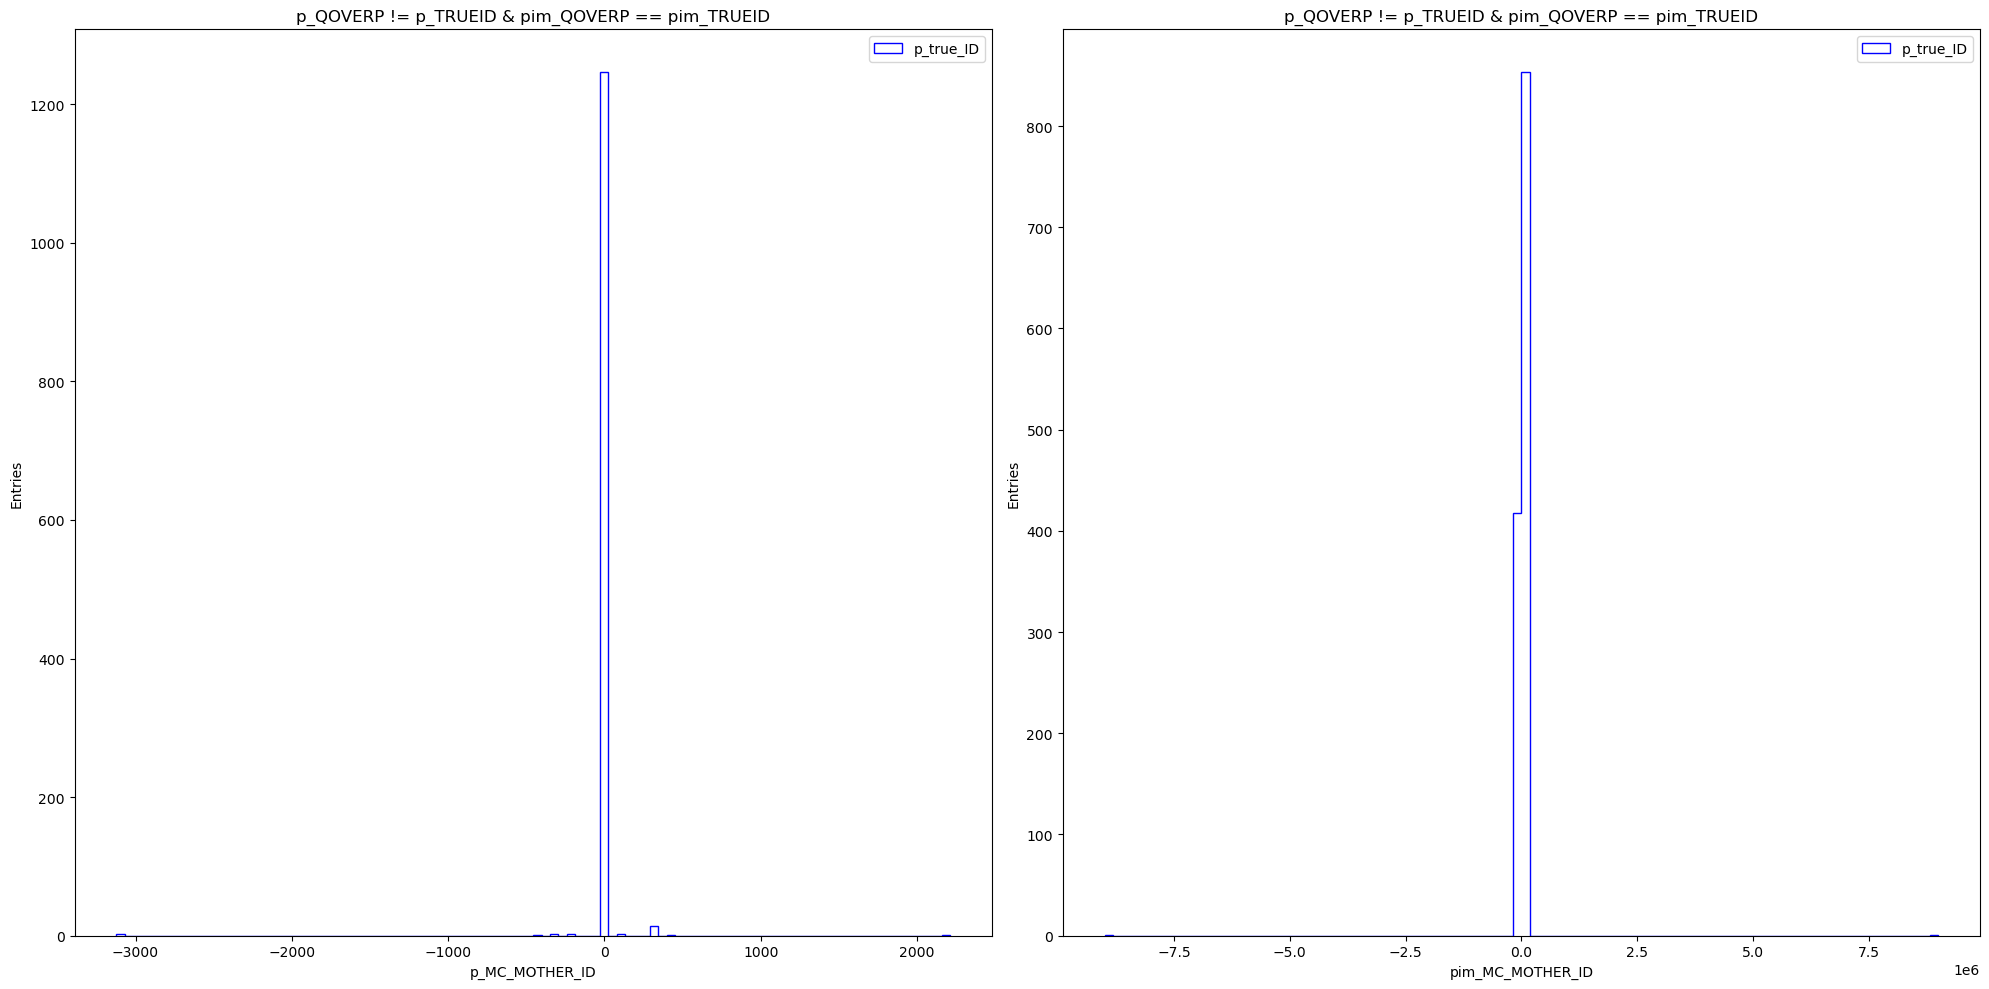

In [129]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # 4 filas, 1 columna

# Primer gráfico
axs[0].hist(mc_signal_filtered2['p_MC_MOTHER_ID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[0].scatter(mc_signal_filtered['alpha_anti_TRUE'],mc_signal_filtered['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlabel('p_MC_MOTHER_ID')
axs[0].set_ylabel('Entries')
axs[0].legend()
axs[0].set_title('p_QOVERP != p_TRUEID & pim_QOVERP == pim_TRUEID')

# Segundo gráfico
axs[1].hist(mc_signal_filtered2['pim_MC_MOTHER_ID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[1].scatter(mc_signal_filtered['alpha_anti_TRUE2'],mc_signal_filtered['pT_anti_TRUE2'], c='orange', s=0.5, label='Anti-Lambda True')

axs[1].set_xlabel('pim_MC_MOTHER_ID')
axs[1].set_ylabel('Entries')
axs[1].legend()
axs[1].set_title('p_QOVERP != p_TRUEID & pim_QOVERP == pim_TRUEID')

plt.tight_layout()
plt.show()


In [130]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered2['p_MC_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)


p_MC_MOTHER_ID
 0       75.569521
 22      22.309505
 321      0.942655
 130      0.235664
-321      0.235664
 310      0.157109
-211      0.157109
 421      0.078555
-3112     0.078555
 2212     0.078555
-3122     0.078555
-411      0.078555
Name: proportion, dtype: float64


In [131]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered2['pim_MC_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)


pim_MC_MOTHER_ID
 211        16.339356
 310        14.689709
-211        14.454046
 3122        7.855460
-3122        7.227023
 2212        3.770621
 130         3.142184
 321         3.142184
 0           3.063629
 113         3.063629
-321         2.985075
 2112        2.670856
-2112        2.670856
-2212        2.356638
 223         2.278083
 221         1.571092
-213         0.785546
 213         0.785546
 331         0.785546
 313         0.628437
-323         0.471328
-3112        0.392773
-3312        0.392773
 3222        0.392773
-313         0.314218
 22          0.314218
 225         0.235664
-3222        0.235664
 3112        0.235664
 2214        0.235664
 3312        0.235664
 20223       0.157109
 5           0.157109
-10213       0.157109
 115         0.157109
 2224        0.157109
 10213       0.157109
 20213       0.157109
 3224        0.078555
 531         0.078555
 323         0.078555
 431         0.078555
-10313       0.078555
 20333       0.078555
 9000211     0.

In [132]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered2['p_MC_GD_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)

p_MC_GD_MOTHER_ID
 0       75.883739
 111     18.224666
 221      3.142184
-421      0.392773
-311      0.235664
 223      0.235664
 11       0.235664
-313      0.235664
 5        0.157109
-11       0.157109
 313      0.157109
 311      0.157109
 331      0.157109
-323      0.078555
 423      0.078555
 323      0.078555
 3122     0.078555
-411      0.078555
-5122     0.078555
 511      0.078555
 2114     0.078555
Name: proportion, dtype: float64


In [133]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered2['pim_MC_GD_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)

pim_MC_GD_MOTHER_ID
 0        26.865672
 311       7.619796
-311       6.520031
 113       5.027494
 5122      3.456402
 223       2.985075
 213       2.906520
-213       2.670856
-5122      2.670856
 211       2.435192
-211       2.278083
 331       1.963865
 310       1.649647
-313       1.413983
 2212      1.099764
 221       1.021210
 4         0.942655
 3212      0.942655
-323       0.942655
-5         0.864101
 313       0.785546
 5         0.785546
 2112      0.785546
-1114      0.785546
 3122      0.706991
-3122      0.706991
 130       0.706991
 321       0.706991
-3212      0.706991
-321       0.628437
-2224      0.628437
-3114      0.628437
-2212      0.628437
 3214      0.549882
 323       0.549882
 2214      0.549882
 10223     0.471328
-3322      0.471328
 333       0.471328
 421       0.471328
 3224      0.471328
-2214      0.471328
 2114      0.471328
 3322      0.471328
 20223     0.471328
 3312      0.392773
 10213     0.392773
-3312      0.392773
-2114      0.314218


In [134]:
# Definir la función auxiliar para comparar signos
def compare_signs(row):
    return np.sign(row['p_QOVERP']) == np.sign(row['p_TRUEID']) and (np.sign(row['pim_QOVERP']) != np.sign(row['pim_TRUEID']))

# Filtrar los datos según las nuevas condiciones utilizando apply
mc_signal_background_filtered3 = mc_signal_background[mc_signal_background.apply(compare_signs, axis=1)]
mc_signal_filtered3 = mc_signal_background_filtered3.query('(Jpsi_BKGCAT ==0)')


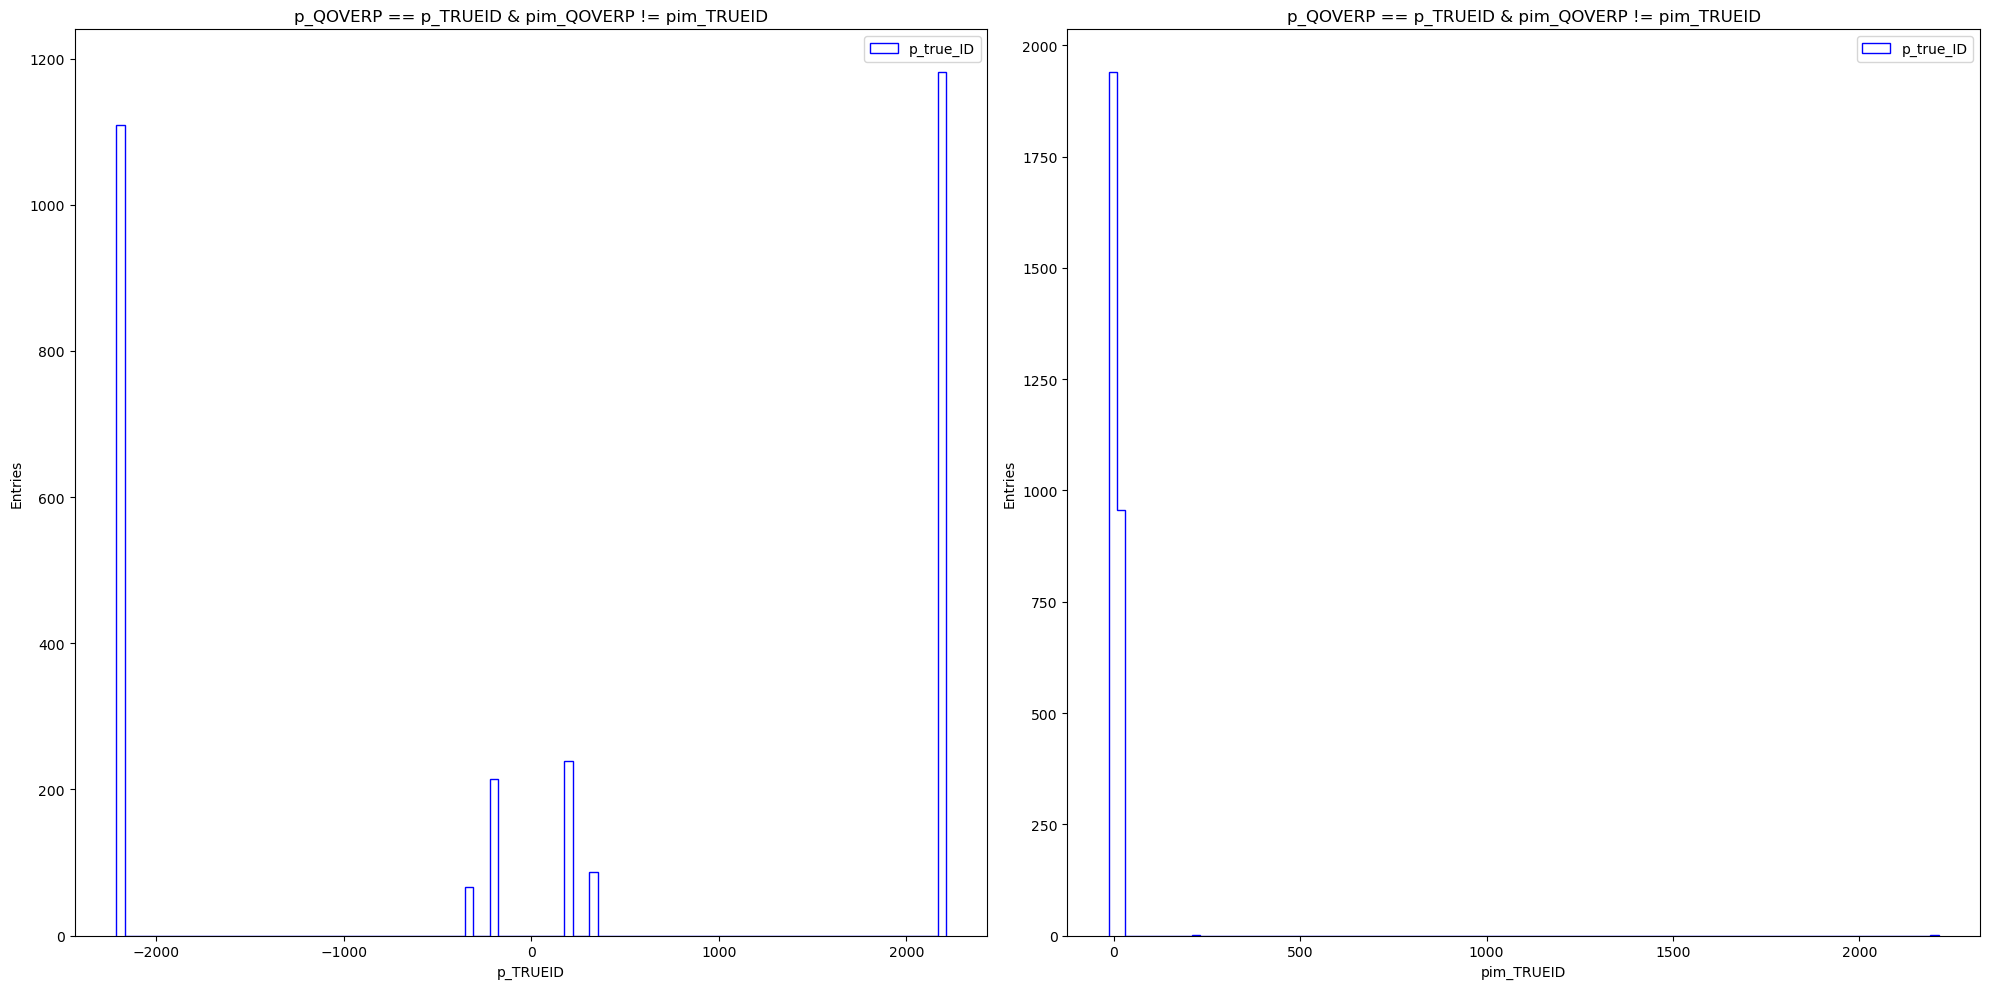

In [135]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # 4 filas, 1 columna

# Primer gráfico
axs[0].hist(mc_signal_filtered3['p_TRUEID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[0].scatter(mc_signal_filtered['alpha_anti_TRUE'],mc_signal_filtered['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlabel('p_TRUEID')
axs[0].set_ylabel('Entries')
axs[0].legend()
axs[0].set_title('p_QOVERP == p_TRUEID & pim_QOVERP != pim_TRUEID')

# Segundo gráfico
axs[1].hist(mc_signal_filtered3['pim_TRUEID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[1].scatter(mc_signal_filtered['alpha_anti_TRUE2'],mc_signal_filtered['pT_anti_TRUE2'], c='orange', s=0.5, label='Anti-Lambda True')

axs[1].set_xlabel('pim_TRUEID')
axs[1].set_ylabel('Entries')
axs[1].legend()
axs[1].set_title('p_QOVERP == p_TRUEID & pim_QOVERP != pim_TRUEID')

plt.tight_layout()
plt.show()


In [136]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered3['p_TRUEID'].value_counts(normalize='True')*100
print(conteo)


p_TRUEID
 2212    40.766310
-2212    38.280980
 211      8.249914
-211      7.386952
 321      3.003107
-321      2.312737
Name: proportion, dtype: float64


In [137]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered3['pim_TRUEID'].value_counts(normalize='True')*100
print(conteo)


pim_TRUEID
 0       35.968243
 11      24.818778
-11      22.437004
-13       8.526061
 13       8.180877
 211      0.034518
 2212     0.034518
Name: proportion, dtype: float64


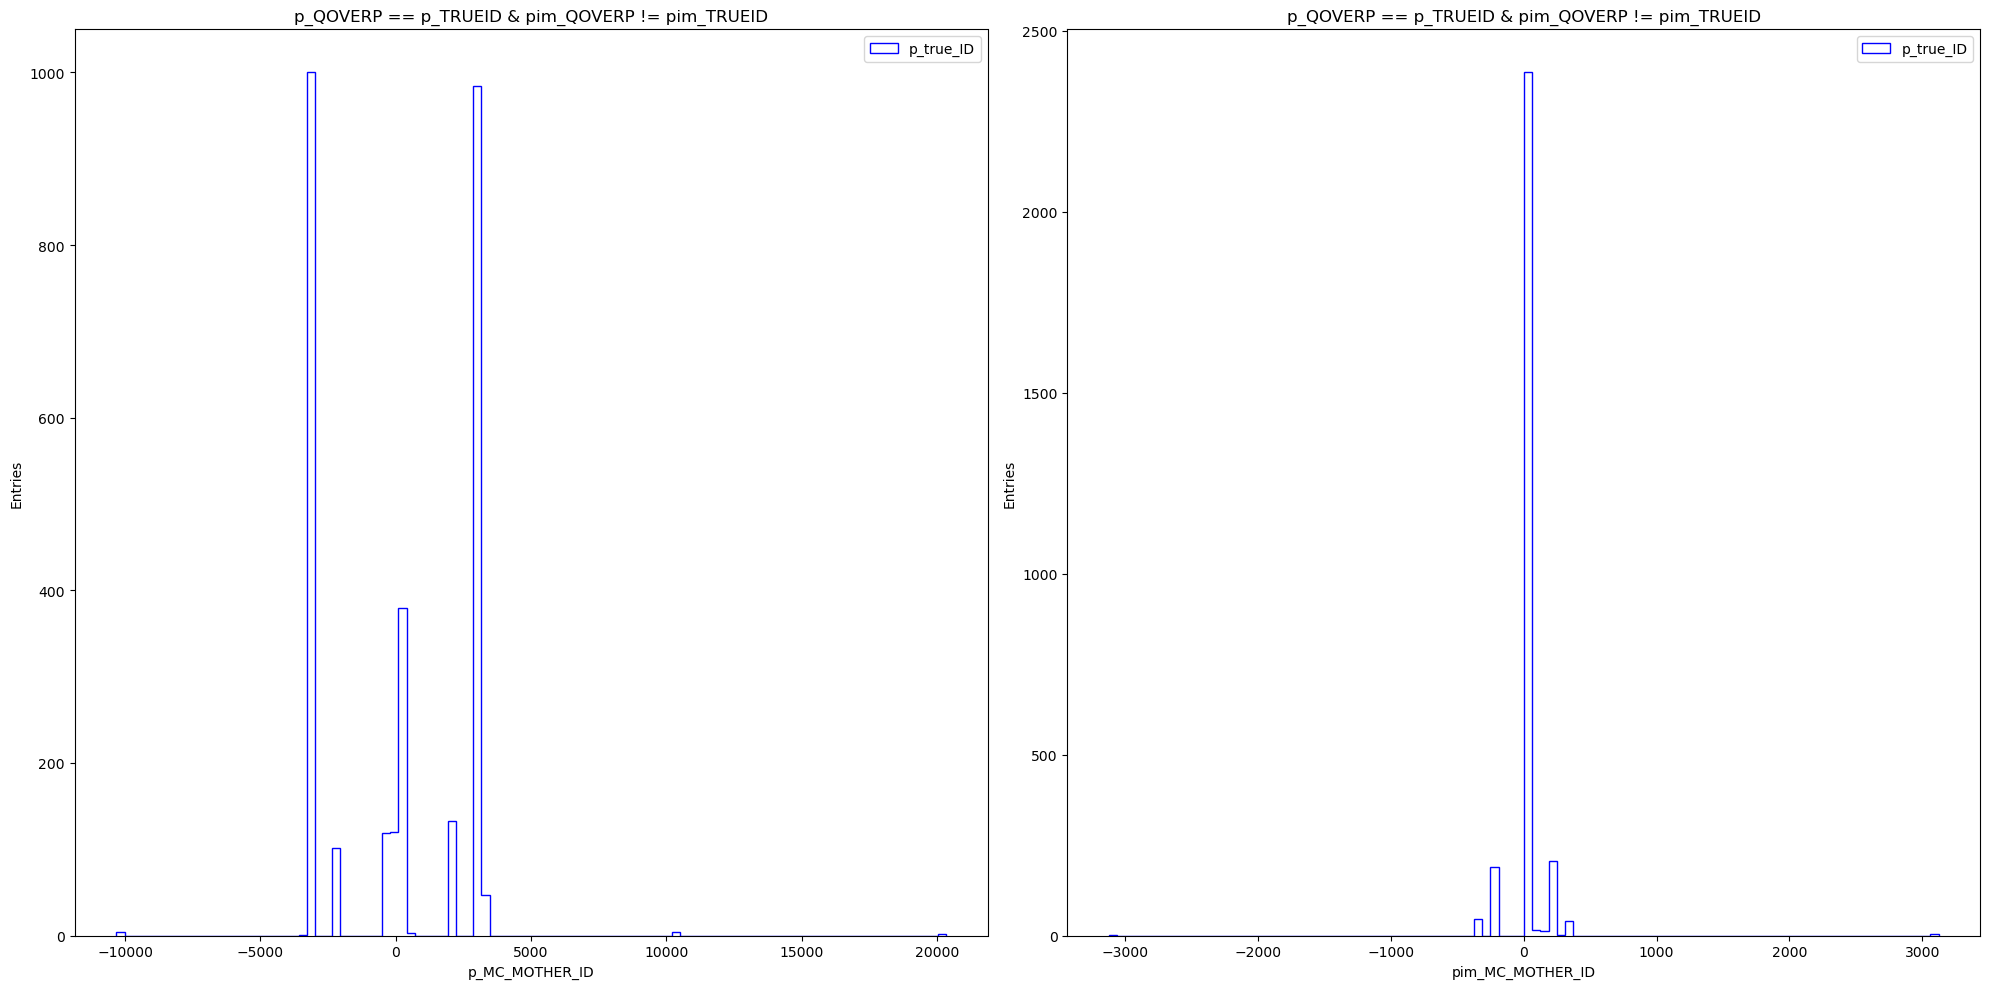

In [138]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # 4 filas, 1 columna

# Primer gráfico
axs[0].hist(mc_signal_filtered3['p_MC_MOTHER_ID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[0].scatter(mc_signal_filtered['alpha_anti_TRUE'],mc_signal_filtered['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlabel('p_MC_MOTHER_ID')
axs[0].set_ylabel('Entries')
axs[0].legend()
axs[0].set_title('p_QOVERP == p_TRUEID & pim_QOVERP != pim_TRUEID')

# Segundo gráfico
axs[1].hist(mc_signal_filtered3['pim_MC_MOTHER_ID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[1].scatter(mc_signal_filtered['alpha_anti_TRUE2'],mc_signal_filtered['pT_anti_TRUE2'], c='orange', s=0.5, label='Anti-Lambda True')

axs[1].set_xlabel('pim_MC_MOTHER_ID')
axs[1].set_ylabel('Entries')
axs[1].legend()
axs[1].set_title('p_QOVERP == p_TRUEID & pim_QOVERP != pim_TRUEID')

plt.tight_layout()
plt.show()


In [139]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered3['p_MC_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)


p_MC_MOTHER_ID
 3122     33.966172
-3122     33.241284
 310       6.316880
 0         3.417328
 2212      2.485330
-211       2.278219
 211       1.933034
-2212      1.829479
 3222      1.622368
 2112      1.277183
 321       1.277183
-3222      1.208146
 113       1.035554
-321       1.001036
-2112      0.724888
 130       0.690369
 223       0.586814
-2224      0.483259
 2224      0.414222
 213       0.379703
 2214      0.345185
 313       0.276148
 4         0.276148
-313       0.276148
-2214      0.276148
-213       0.241629
-323       0.172592
-2114      0.172592
-5         0.172592
-4         0.138074
 5         0.138074
 10223     0.103555
 325       0.103555
 221       0.103555
 335       0.069037
 315       0.069037
-10323     0.069037
-3112      0.069037
 323       0.069037
 2114      0.069037
 115       0.069037
 225       0.069037
 333       0.034518
-10211     0.034518
-10213     0.034518
 521       0.034518
 511       0.034518
-325       0.034518
 20333     0.034518
-3312

In [140]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered3['pim_MC_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)


pim_MC_MOTHER_ID
 22      46.358302
 0       35.968243
 211      7.041767
-211      6.523990
-321      1.587849
 321      1.346220
 111      0.517777
 130      0.414222
 3122     0.103555
 221      0.069037
-3122     0.034518
 310      0.034518
Name: proportion, dtype: float64


In [141]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered3['p_MC_GD_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)

p_MC_GD_MOTHER_ID
 5122     23.299965
-5122     23.058336
 0        21.470487
 311       3.175699
-311       2.830514
 3212      2.485330
-3212      2.140145
 5         1.208146
-3122      0.931999
 113       0.897480
-3214      0.897480
 3322      0.897480
-3114      0.862962
 3214      0.793925
 3122      0.724888
 3224      0.690369
-3224      0.586814
 3114      0.586814
 3312      0.586814
-3312      0.552295
-5         0.552295
 2224      0.517777
-4         0.483259
 2214      0.414222
 313       0.414222
-3322      0.414222
 223       0.414222
 4         0.414222
 2114      0.379703
-213       0.379703
-2214      0.310666
-421       0.276148
-313       0.276148
-2224      0.276148
-2114      0.276148
 211       0.241629
 310       0.241629
 333       0.241629
-4122      0.241629
 213       0.241629
 2212      0.241629
 421       0.241629
 130       0.207111
 323       0.207111
 1114      0.207111
-1114      0.207111
-2212      0.207111
-323       0.172592
 2112      0.172592
 3

In [142]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered3['pim_MC_GD_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)

pim_MC_GD_MOTHER_ID
 111      38.350017
 0        37.383500
-3122      5.281326
 3122      4.867104
 221       4.176735
 11        1.346220
-11        1.035554
 223       0.862962
 310       0.621332
 331       0.586814
 211       0.448740
 313       0.414222
-313       0.379703
-211       0.345185
 113       0.310666
 333       0.276148
-213       0.241629
-323       0.207111
 213       0.207111
 311       0.172592
-311       0.172592
 323       0.172592
 5         0.138074
-321       0.138074
-2212      0.138074
 321       0.138074
-2112      0.103555
 2212      0.103555
-10313     0.103555
-5212      0.069037
 2224      0.069037
 2112      0.069037
-3212      0.069037
 130       0.069037
 4         0.069037
 3322      0.069037
 3212      0.069037
 3224      0.034518
 10211     0.034518
 3112      0.034518
 5212      0.034518
-3112      0.034518
-2214      0.034518
 20223     0.034518
 5114      0.034518
-433       0.034518
-431       0.034518
-20213     0.034518
-5         0.034518


In [143]:
# Definir la función auxiliar para comparar signos
def compare_signs(row):
    return np.sign(row['p_QOVERP']) != np.sign(row['p_TRUEID']) and (np.sign(row['pim_QOVERP']) != np.sign(row['pim_TRUEID']))

# Filtrar los datos según las nuevas condiciones utilizando apply
mc_signal_background_filtered4 = mc_signal_background[mc_signal_background.apply(compare_signs, axis=1)]
mc_signal_filtered4 = mc_signal_background_filtered4.query('(Jpsi_BKGCAT ==0)')


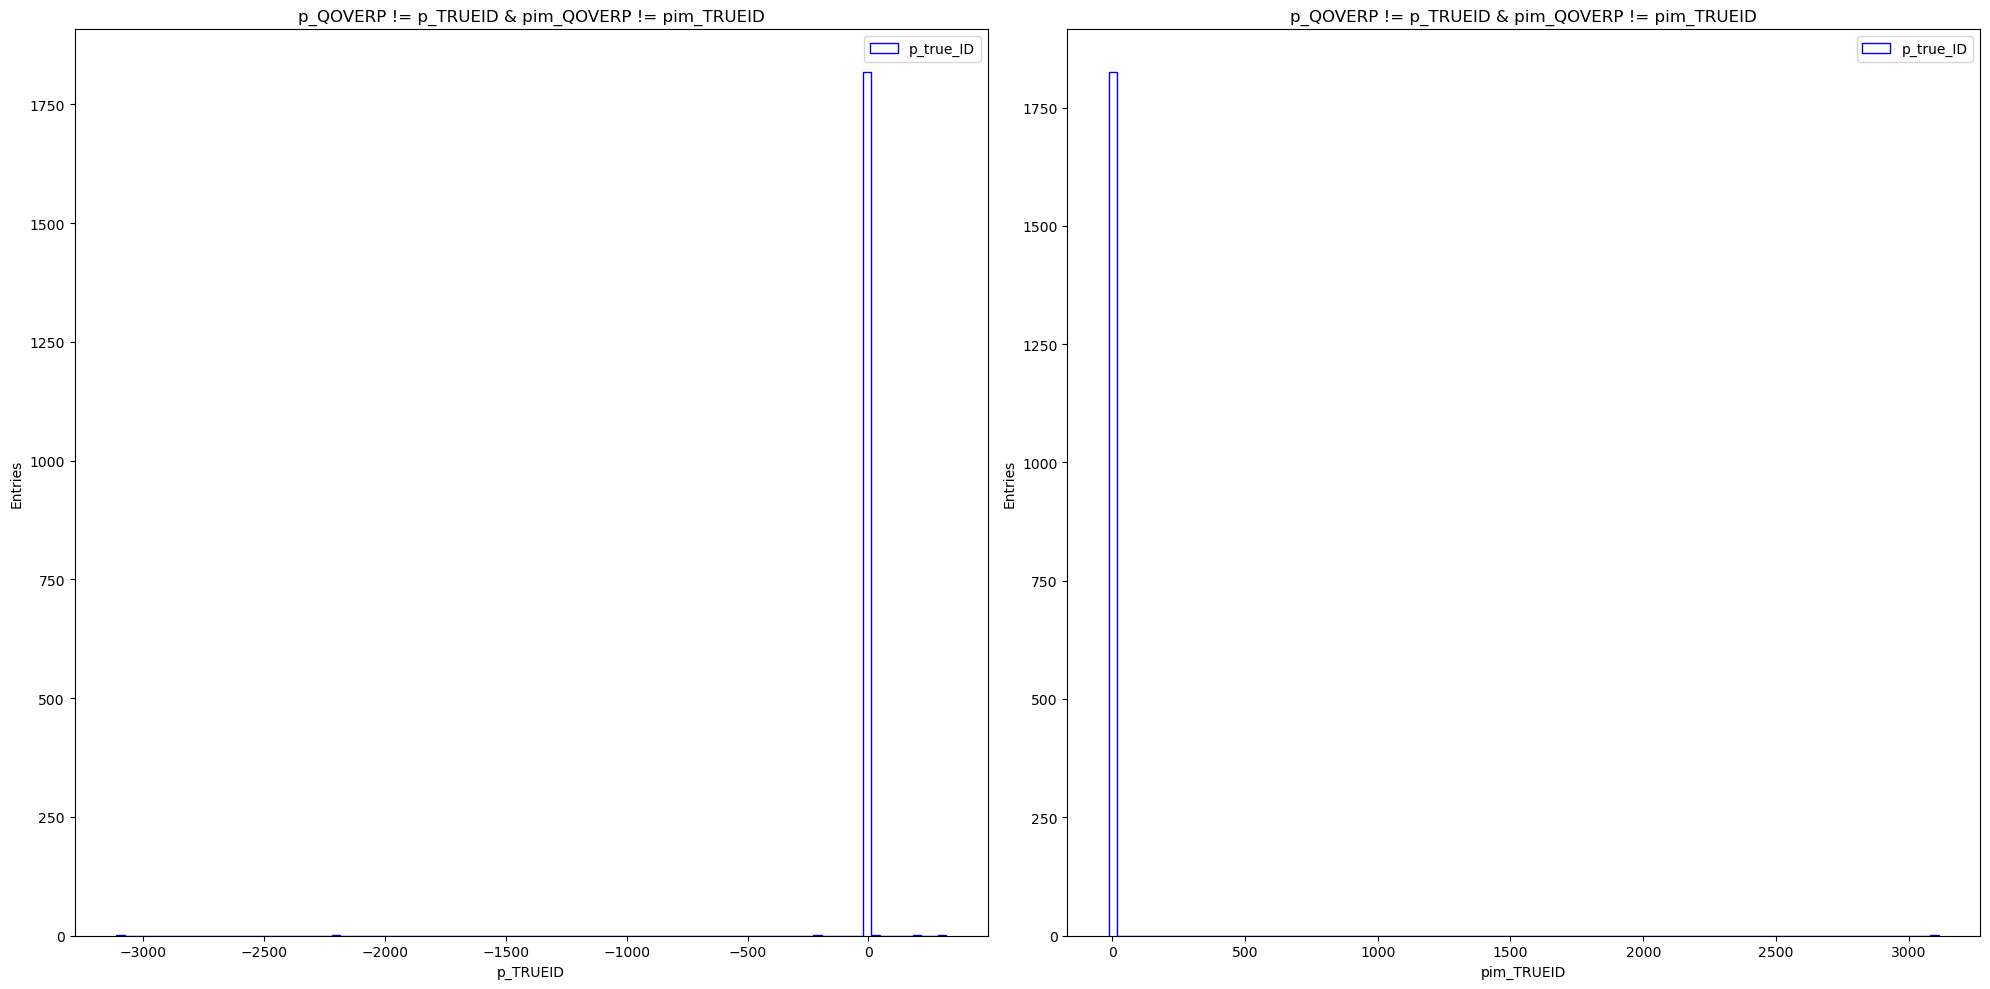

In [144]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # 4 filas, 1 columna

# Primer gráfico
axs[0].hist(mc_signal_filtered4['p_TRUEID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[0].scatter(mc_signal_filtered['alpha_anti_TRUE'],mc_signal_filtered['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlabel('p_TRUEID')
axs[0].set_ylabel('Entries')
axs[0].legend()
axs[0].set_title('p_QOVERP != p_TRUEID & pim_QOVERP != pim_TRUEID')

# Segundo gráfico
axs[1].hist(mc_signal_filtered4['pim_TRUEID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[1].scatter(mc_signal_filtered['alpha_anti_TRUE2'],mc_signal_filtered['pT_anti_TRUE2'], c='orange', s=0.5, label='Anti-Lambda True')

axs[1].set_xlabel('pim_TRUEID')
axs[1].set_ylabel('Entries')
axs[1].legend()
axs[1].set_title('p_QOVERP != p_TRUEID & pim_QOVERP != pim_TRUEID')

plt.tight_layout()
plt.show()


In [145]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered4['p_TRUEID'].value_counts(normalize='True')*100
print(conteo)


p_TRUEID
 0       79.232877
 11      10.410959
-11       9.917808
 13       0.109589
-211      0.109589
-2212     0.054795
-3112     0.054795
 211      0.054795
 321      0.054795
Name: proportion, dtype: float64


In [146]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered4['pim_TRUEID'].value_counts(normalize='True')*100
print(conteo)


pim_TRUEID
 0       60.986301
 11      19.506849
-11      16.602740
-13       1.424658
 13       1.424658
 3112     0.054795
Name: proportion, dtype: float64


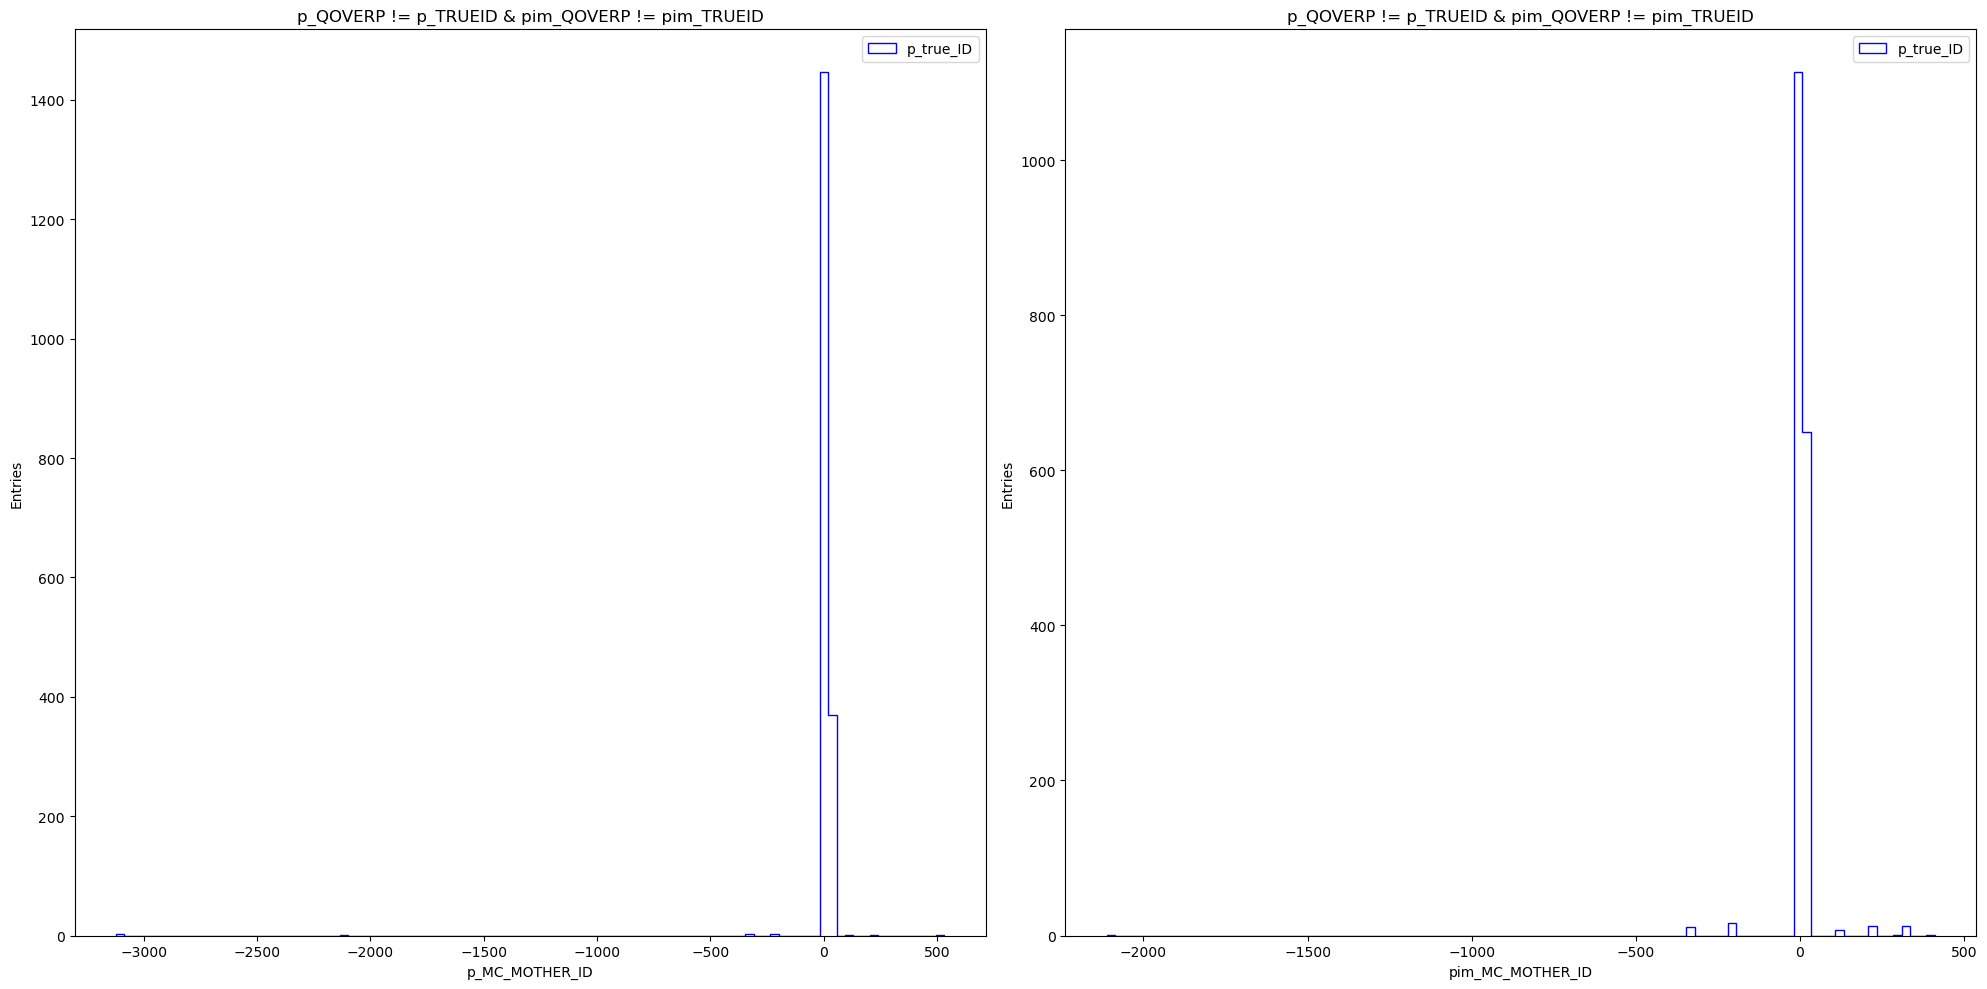

In [147]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # 4 filas, 1 columna

# Primer gráfico
axs[0].hist(mc_signal_filtered4['p_MC_MOTHER_ID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[0].scatter(mc_signal_filtered['alpha_anti_TRUE'],mc_signal_filtered['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlabel('p_MC_MOTHER_ID')
axs[0].set_ylabel('Entries')
axs[0].legend()
axs[0].set_title('p_QOVERP != p_TRUEID & pim_QOVERP != pim_TRUEID')

# Segundo gráfico
axs[1].hist(mc_signal_filtered4['pim_MC_MOTHER_ID'], bins = 100, color = 'blue', label='p_true_ID', histtype = 'step')
# axs[1].scatter(mc_signal_filtered['alpha_anti_TRUE2'],mc_signal_filtered['pT_anti_TRUE2'], c='orange', s=0.5, label='Anti-Lambda True')

axs[1].set_xlabel('pim_MC_MOTHER_ID')
axs[1].set_ylabel('Entries')
axs[1].legend()
axs[1].set_title('p_QOVERP != p_TRUEID & pim_QOVERP != pim_TRUEID')

plt.tight_layout()
plt.show()


In [148]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered4['p_MC_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)


p_MC_MOTHER_ID
 0       79.232877
 22      20.219178
-321      0.109589
-3122     0.109589
-211      0.109589
-2112     0.054795
 531      0.054795
 211      0.054795
 111      0.054795
Name: proportion, dtype: float64


In [149]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered4['pim_MC_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)


pim_MC_MOTHER_ID
 0       60.986301
 22      35.616438
-211      0.876712
 211      0.712329
 321      0.657534
-321      0.602740
 111      0.328767
 411      0.054795
 310      0.054795
 130      0.054795
-2112     0.054795
Name: proportion, dtype: float64


In [150]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered4['p_MC_GD_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)

p_MC_GD_MOTHER_ID
 0       79.506849
 111     17.479452
 221      1.863014
 223      0.328767
 11       0.273973
 331      0.109589
-5122     0.109589
-213      0.054795
-3122     0.054795
 421      0.054795
 533      0.054795
 213      0.054795
 310      0.054795
Name: proportion, dtype: float64


In [151]:
# Suponiendo que mc_signal_filtered es tu DataFrame
pd.set_option('display.max_rows', None)
conteo = mc_signal_filtered4['pim_MC_GD_MOTHER_ID'].value_counts(normalize='True')*100
print(conteo)

pim_MC_GD_MOTHER_ID
 0        61.917808
 111      29.424658
 221       3.397260
 11        1.095890
-11        0.931507
 223       0.547945
 113       0.383562
 310       0.383562
 333       0.164384
 323       0.109589
 115       0.109589
 4         0.109589
 3122      0.109589
-211       0.109589
-3122      0.109589
-1114      0.054795
 5         0.054795
 10313     0.054795
-321       0.054795
-413       0.054795
-423       0.054795
-323       0.054795
-10323     0.054795
 2112      0.054795
 2212      0.054795
 433       0.054795
 331       0.054795
-4         0.054795
 313       0.054795
 311       0.054795
-521       0.054795
 10323     0.054795
-313       0.054795
-213       0.054795
 211       0.054795
Name: proportion, dtype: float64


In [152]:
proton_mis = mc_signal['alpha_combined_TRUE2'].notna().sum()
pion_mis = mc_signal['alpha_combined_TRUE3'].notna().sum()
both_mis =  mc_signal['alpha_combined_TRUE4'].notna().sum()
total = mc_signal['alpha_combined_TRUE'].notna().sum()

mismatch_proton = proton_mis/total *100
mismatch_pion= pion_mis/total*100
mismatch_both = both_mis/total*100

print(proton_mis)
print(pion_mis)
print(both_mis)
print(total)

print(mismatch_proton)
print(mismatch_pion)
print(mismatch_both)

312
1855
302
43960
0.7097361237488626
4.219745222929936
0.6869881710646042


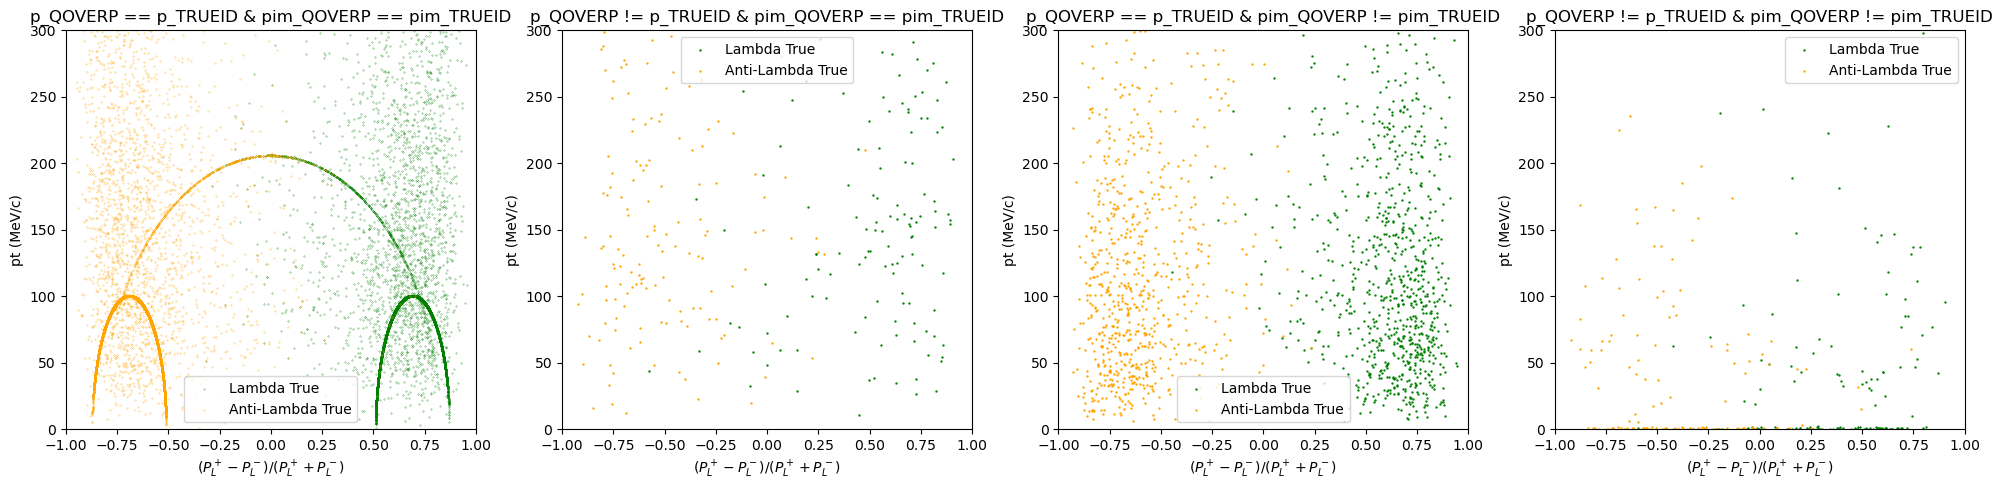

In [153]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))  # 4 filas, 1 columna

# Primer gráfico
axs[0].scatter(mc_signal['alpha_TRUE'],mc_signal['pT_TRUE'], c='green', s=0.05, label='Lambda True')
axs[0].scatter(mc_signal['alpha_anti_TRUE'],mc_signal['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 300)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[0].set_ylabel('pt (MeV/c)')
axs[0].legend()
axs[0].set_title('p_QOVERP == p_TRUEID & pim_QOVERP == pim_TRUEID')

# Segundo gráfico
axs[1].scatter(mc_signal['alpha_TRUE2'],mc_signal['pT_TRUE2'], c='green', s=0.5, label='Lambda True')
axs[1].scatter(mc_signal['alpha_anti_TRUE2'],mc_signal['pT_anti_TRUE2'], c='orange', s=0.5, label='Anti-Lambda True')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 300)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[1].set_ylabel('pt (MeV/c)')
axs[1].legend()
axs[1].set_title('p_QOVERP != p_TRUEID & pim_QOVERP == pim_TRUEID')


# Tercer gráfico
axs[2].scatter(mc_signal['alpha_TRUE3'],mc_signal['pT_TRUE3'], c='green', s=0.5, label='Lambda True')
axs[2].scatter(mc_signal['alpha_anti_TRUE3'],mc_signal['pT_anti_TRUE3'], c='orange', s=0.5, label='Anti-Lambda True')
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 300)
axs[2].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[2].set_ylabel('pt (MeV/c)')
axs[2].legend()
axs[2].set_title('p_QOVERP == p_TRUEID & pim_QOVERP != pim_TRUEID')

# Cuarto gráfico
axs[3].scatter(mc_signal['alpha_TRUE4'],mc_signal['pT_TRUE4'], c='green', s=0.5, label='Lambda True')
axs[3].scatter(mc_signal['alpha_anti_TRUE4'],mc_signal['pT_anti_TRUE4'], c='orange', s=0.5, label='Anti-Lambda True')
axs[3].set_xlim(-1, 1)
axs[3].set_ylim(0, 300)
axs[3].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[3].set_ylabel('pt (MeV/c)')
axs[3].legend()
axs[3].set_title('p_QOVERP != p_TRUEID & pim_QOVERP != pim_TRUEID')

plt.tight_layout()
plt.show()


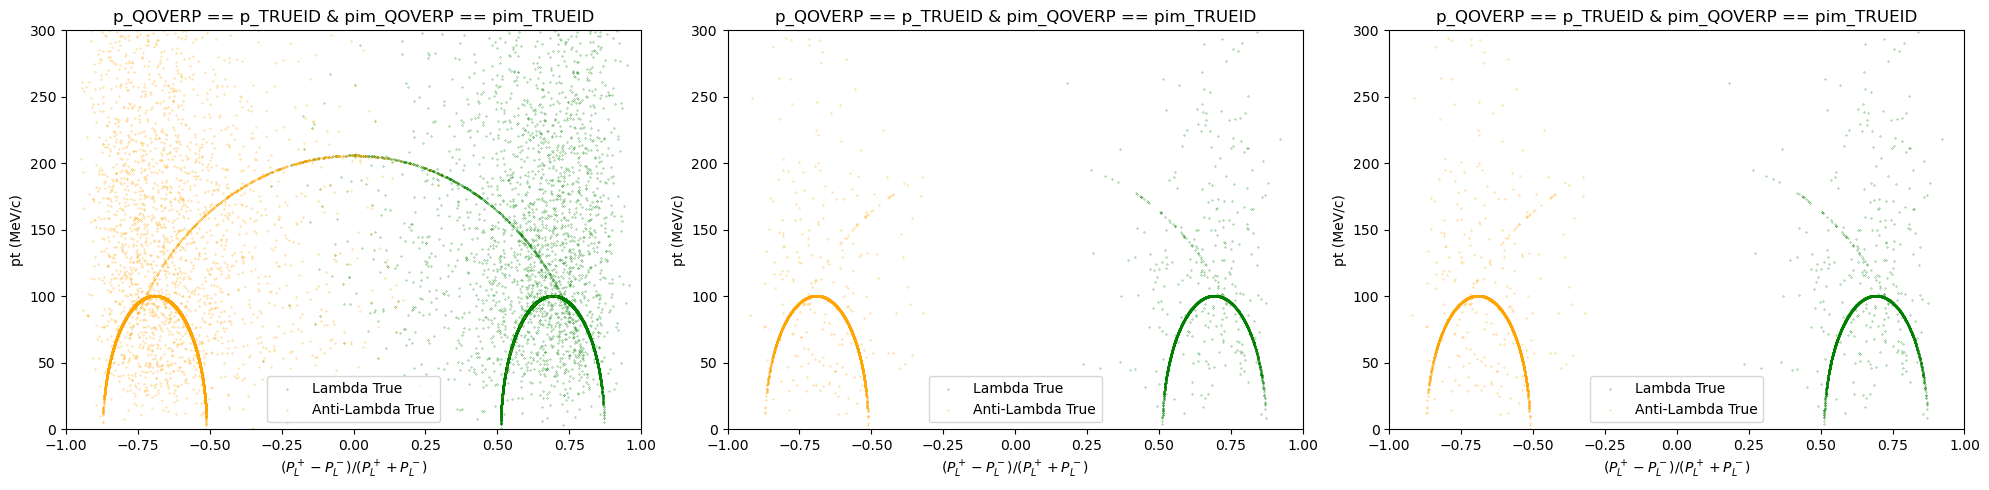

In [154]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))  # 4 filas, 1 columna

# Primer gráfico
axs[0].scatter(mc_signal['alpha_TRUE'],mc_signal['pT_TRUE'], c='green', s=0.05, label='Lambda True')
axs[0].scatter(mc_signal['alpha_anti_TRUE'],mc_signal['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 300)
axs[0].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[0].set_ylabel('pt (MeV/c)')
axs[0].legend()
axs[0].set_title('p_QOVERP == p_TRUEID & pim_QOVERP == pim_TRUEID')

# Primer gráfico
axs[1].scatter(mc_signal.query('(p_TRUEID == 2212) & (p_MC_MOTHER_ID == 3122) & (p_MC_GD_MOTHER_ID == 5122) & (pim_TRUEID == -211)& (pim_MC_MOTHER_ID == 3122) & (p_MC_GD_MOTHER_ID == 5122)')['alpha_TRUE'],mc_signal.query('(p_TRUEID == 2212) & (p_MC_MOTHER_ID == 3122) & (p_MC_GD_MOTHER_ID == 5122)  & (pim_TRUEID == -211)& (pim_MC_MOTHER_ID == 3122) & (p_MC_GD_MOTHER_ID == 5122)')['pT_TRUE'], c='green', s=0.05, label='Lambda True')
axs[1].scatter(mc_signal.query('(p_TRUEID == -2212) & (p_MC_MOTHER_ID == -3122) & (p_MC_GD_MOTHER_ID == -5122) & (pim_TRUEID == 211)& (pim_MC_MOTHER_ID == -3122) & (p_MC_GD_MOTHER_ID == -5122) ')['alpha_anti_TRUE'],mc_signal.query('(p_TRUEID == -2212) & (p_MC_MOTHER_ID == -3122) & (p_MC_GD_MOTHER_ID == -5122)  & (pim_TRUEID == 211)& (pim_MC_MOTHER_ID == -3122) & (p_MC_GD_MOTHER_ID == -5122)')['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 300)
axs[1].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[1].set_ylabel('pt (MeV/c)')
axs[1].legend()
axs[1].set_title('p_QOVERP == p_TRUEID & pim_QOVERP == pim_TRUEID')

# Primer gráfico
axs[2].scatter(mc_signal.query('(p_MC_MOTHER_ID == 3122) & (pim_MC_MOTHER_ID == 3122)')['alpha_TRUE'],mc_signal.query(' (p_MC_MOTHER_ID == 3122) & (pim_MC_MOTHER_ID == 3122)')['pT_TRUE'], c='green', s=0.05, label='Lambda True')
axs[2].scatter(mc_signal.query('(p_TRUEID == -2212) & (p_MC_MOTHER_ID == -3122) & (p_MC_GD_MOTHER_ID == -5122) & (pim_TRUEID == 211)& (pim_MC_MOTHER_ID == -3122) & (p_MC_GD_MOTHER_ID == -5122) ')['alpha_anti_TRUE'],mc_signal.query('(p_TRUEID == -2212) & (p_MC_MOTHER_ID == -3122) & (p_MC_GD_MOTHER_ID == -5122)  & (pim_TRUEID == 211)& (pim_MC_MOTHER_ID == -3122) & (p_MC_GD_MOTHER_ID == -5122)')['pT_anti_TRUE'], c='orange', s=0.05, label='Anti-Lambda True')
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 300)
axs[2].set_xlabel(r'$(P_L^+ - P_L^-)/(P_L^+ + P_L^-)$')
axs[2].set_ylabel('pt (MeV/c)')
axs[2].legend()
axs[2].set_title('p_QOVERP == p_TRUEID & pim_QOVERP == pim_TRUEID')

plt.tight_layout()
plt.show()
#& (p_MC_MOTHER_ID != 3122) & (p_MC_GD_MOTHER_ID != 5122) & (pim_MC_MOTHER_ID != 3122) & (p_MC_GD_MOTHER_ID != 5122)
#& (p_MC_MOTHER_ID != 3122) & (p_MC_GD_MOTHER_ID != 5122)& (pim_MC_MOTHER_ID != 3122) & (p_MC_GD_MOTHER_ID != 5122)


In [155]:
from rk_transport import FarRKTrkTransport, propagate_to_vertex

signal_data_after_BDT = signal_data.query('(prob1 > 0.9)')
particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

signal_data_after_BDT1 = signal_data_after_BDT.query(particulas)
signal_data_after_BDT2 = signal_data_after_BDT.query(antiparticulas)

def propagate_to_vertex(vz, xi, yi, zi, pxi, pyi, pzi, qoverp,rk):
    xf,yf,txf,tyf = rk.propagate(vz/10., 1., xi/10., yi/10., zi/10., pxi/1000., pyi/1000., pzi/1000., qoverp*1000.)
    mom = np.array([txf,tyf,1])*((np.abs(1/(qoverp*1000.)))/np.sqrt(txf**2. + tyf**2. + 1.))
    return mom[0]*1000., mom[1]*1000., mom[2]*1000., xf*10., yf*10.

rk = FarRKTrkTransport()

vertex_values = pd.DataFrame(columns=['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V'])
vertex_values2 = pd.DataFrame(columns=['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V'])

vertex_values[['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V']] = signal_data_after_BDT1.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.p_TRACK_POS_CLOSESTTOBEAM_X,row.p_TRACK_POS_CLOSESTTOBEAM_Y,row.p_TRACK_POS_CLOSESTTOBEAM_Z,row.p_PX,row.p_PY,row.p_PZ,row.p_QOVERP,rk),axis='columns',result_type='expand')
vertex_values2[['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V']] = signal_data_after_BDT1.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.pim_TRACK_POS_CLOSESTTOBEAM_X,row.pim_TRACK_POS_CLOSESTTOBEAM_Y,row.pim_TRACK_POS_CLOSESTTOBEAM_Z,row.pim_PX,row.pim_PY,row.pim_PZ,row.pim_QOVERP,rk),axis='columns',result_type='expand')

signal_data_after_BDT1 = pd.concat([signal_data_after_BDT1,vertex_values],axis='columns')
signal_data_after_BDT1 = pd.concat([signal_data_after_BDT1,vertex_values2],axis='columns')

vertex_values[['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V']] = signal_data_after_BDT2.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.p_TRACK_POS_CLOSESTTOBEAM_X,row.p_TRACK_POS_CLOSESTTOBEAM_Y,row.p_TRACK_POS_CLOSESTTOBEAM_Z,row.p_PX,row.p_PY,row.p_PZ,row.p_QOVERP,rk),axis='columns',result_type='expand')
vertex_values2[['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V']] = signal_data_after_BDT2.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.pim_TRACK_POS_CLOSESTTOBEAM_X,row.pim_TRACK_POS_CLOSESTTOBEAM_Y,row.pim_TRACK_POS_CLOSESTTOBEAM_Z,row.pim_PX,row.pim_PY,row.pim_PZ,row.pim_QOVERP,rk),axis='columns',result_type='expand')

signal_data_after_BDT2= pd.concat([signal_data_after_BDT2,vertex_values],axis='columns')
signal_data_after_BDT2 = pd.concat([signal_data_after_BDT2,vertex_values2],axis='columns')

FarRKTrkTransport: reading B field mapping from file /l/javeser/farvertexing/db/MagneticFieldMapping20x20x100.root
FarRKTrkTransport: reading B field mapping with: x in [-300,300] and 21 points
                                                 y in [-300,300] and 21 points
                                                 z in [0,1000] and 101 points
